In [1]:
import sys
import os

# Add the parent directory (project root) to the python path
sys.path.append(os.path.abspath(os.path.join('..')))


## Qwen VL


### Load model

In [2]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
gpu_node = 1

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct",
                    attn_implementation=None, gpu_node=0):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map=f"cuda:{gpu_node}",                  # split across GPU/CPU automatically
        # device_map="auto",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=attn_implementation,
    )
    return model, processor


In [2]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [3]:
model.config.model_type

'qwen2_5_vl'

In [4]:
torch.cuda.device_count()

4

In [ ]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

In [6]:
from PIL import Image
from accelerate import Accelerator


def get_inputs(image: Image.Image, question: str):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {
                    "type": "text",
                    "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
                },
            ],
        }
    ]
    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

    inputs = inputs.to(model.device)


    # inputs = {k: v.to(device) for k, v in inputs.items()}

    return inputs

def predict_answer(model, image: Image.Image, question: str,
                   dtype=torch.bfloat16) -> dict:
    
    inputs = get_inputs(image, question)

    # accelerator = Accelerator()

    # inputs, model = accelerator.prepare(inputs, model)
    # print(inputs["pixel_values"].device)
    # print(model.device)

    with torch.no_grad():
        generated_ids = model.generate(**inputs,
                                       max_new_tokens=32)

    # strip prompt
    prompt_len = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[:, prompt_len:]
    out = processor.batch_decode(
        answer_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    answer_text = out.strip()

    # first generate token id
    pred_token = int(answer_ids[0, 0].item())

    # answer_token_ids = answer_ids[0].tolist()
    # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
    return {
        "text": answer_text,
        "pred_token": pred_token,
        "answer_ids": answer_ids[0].cpu().tolist(), # all generated token ids 
    }

def get_target_token(golds, processor):
    """
    golds: list of string answers (already lower/strip if you want)
    returns: (token_ids, text_used)
    """
    # pick a canonical gold answer; here: the first one
    gold = golds[0]

    # tokenize WITHOUT adding special tokens
    enc = processor.tokenizer(
        gold,
        add_special_tokens=False,
        return_tensors=None,
    )
    token_ids = enc["input_ids"]  # this is a list[int]

    return token_ids[0]


In [7]:
import gc
verbose = False
records = []  # this will hold all the info you want to reuse

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]
    golds = [a.lower().strip() for a in sample["label"]]

    pred_dict = predict_answer(model, img, q)
    pred_text =  pred_dict["text"]
    pred_lower = pred_text.lower()
    pred_token = pred_dict["pred_token"]
    pred_answer_ids = pred_dict["answer_ids"]
    # pred_tokens = pred_dict["tokens"]

    target_token = get_target_token(golds, processor)



    correct = any(g in pred_lower for g in golds)

    if verbose:

        print(f"[{idx}] Q: {q}")
        print(f"    gold: {golds}")
        print(f"    pred: {pred_text}")
        print(f"    correct: {correct}\n")

    # Store everything you’ll need later
    records.append(
        {
            "id": idx,
            "image": img,              # keep the PIL image in memory
            "question": q,
            "gold_answers": golds,
            "prediction": pred_text,
            "correct": correct,
            "pred_token": pred_token,
            "target_token": target_token,
            "answer_ids": pred_answer_ids
            # "tokens": pred_tokens,
        }
    )
    gc.collect()
    torch.cuda.empty_cache()


In [8]:
records

[{'id': 0,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many food item is shown in the bar graph?',
  'gold_answers': ['14'],
  'prediction': '14',
  'correct': True,
  'pred_token': 16,
  'target_token': 16,
  'answer_ids': [16, 19, 151645]},
 {'id': 1,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'What is the difference in value between Lamb and Corn?',
  'gold_answers': ['0.57'],
  'prediction': '0.4',
  'correct': False,
  'pred_token': 15,
  'target_token': 15,
  'answer_ids': [15, 13, 19, 151645]},
 {'id': 2,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many bars are shown in the chart?',
  'gold_answers': ['3'],
  'prediction': '3',
  'correct': True,
  'pred_token': 18,
  'target_token': 18,
  'answer_ids': [18, 151645]},
 {'id': 3,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'Is the sum value 

In [9]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class QwenVL_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()
    
    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        image_grid_thw = inputs.get("image_grid_thw", None)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        image_grid_thw,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        image_grid_thw,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")


    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                image_grid_thw,
                return_probs=False,):

        # Vision embeddings
        image_embeds = self.hf_model.get_image_features(pixel_values,
                                                image_grid_thw=image_grid_thw)
        
        image_embeds = torch.cat(image_embeds, dim=0).to(text_embeds.device, text_embeds.dtype)
        image_mask, _ = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_embeds
        )
        inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        # if target_token is not None:
        #     target_token = 
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        if return_probs:
            # Compute the log_softmax
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32,
                return_logits=False):
        with torch.no_grad():
            outputs = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           output_hidden_states=return_logits,
                                           max_new_tokens=max_new_tokens)
        generated_ids = outputs.sequences

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # first generate token id
        pred_token = int(answer_ids[0, 0].item())
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        if return_logits:
            logits = [self.hf_model.lm_head(feats[-1]) for feats in outputs.hidden_states]
            return pred_token, answer_text, logits
        return pred_token, answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "QwenVL_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


In [6]:
from src.models.qwen_vl import QwenVL_Wrapper

model_wrapper = QwenVL_Wrapper(model, processor)


In [7]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]

    inputs = model_wrapper.get_inputs(img, q)
    break

In [8]:
logits = model_wrapper.forward(**inputs, return_probs=True)
logits.shape

torch.Size([1, 151936])

In [11]:
res = model_wrapper.predict(inputs, return_logits=True)

In [13]:
# input_ids = inputs.input_ids
# attention_mask = inputs.attention_mask
pixel_values = inputs.pixel_values
# image_grid_thw = inputs.image_grid_thw
# return_probs = True

text_embeds = model_wrapper.embed_text(inputs.input_ids)

In [15]:
# captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
kwargs_dict = {k: v for k, v in inputs.items() if k not in ['pixel_values']}
# captum_add_forward = (attention_mask, input_ids, return_probs, kwargs)
# captum_add_forward = (kwargs_dict)

In [16]:
log_captum = model_wrapper.get_captum_forward(text_embeds, pixel_values,
                                              kwargs_dict)

torch.Size([2520, 1176])
torch.Size([1, 3])


In [17]:
log_captum

tensor([[-17.3750, -11.3125, -12.4375,  ..., -22.8750, -22.8750, -22.8750]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<LogSoftmaxBackward0>)

In [8]:
torch.cuda.empty_cache()

#### COCO dataset

In [7]:
import os
import random

import torch
import numpy as np
from PIL import Image
from pycocotools.coco import COCO
from torch.utils.data import Dataset

class COCOGroundingDataset(Dataset):
    def __init__(self, data_path):
        """
        Args:
            data_path (str): Path to image folder (e.g., 'val2017')
        """
        self.data_path = data_path
        coco_split = "val2017"
        instances_file = os.path.join(self.data_path, "annotations", f"instances_{coco_split}.json")
        captions_file = os.path.join(self.data_path, "annotations", f"captions_{coco_split}.json")

        self.coco_instances = COCO(instances_file)
        self.coco_captions = COCO(captions_file)
        
        # Filter: Only keep images that have annotations AND captions
        # (Usually identical sets, but good for safety)
        self.ids = list(sorted(self.coco_instances.imgs.keys()))
        
        # Cache category mapping for the Instances
        cats = self.coco_instances.loadCats(self.coco_instances.getCatIds())
        self.id2name = {cat['id']: cat['name'] for cat in cats}


    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        
        # --- 1. Load Image ---
        img_info = self.coco_instances.loadImgs(img_id)[0]
        img_path = os.path.join(self.data_path, "val2017", img_info['file_name'])
        image = Image.open(img_path).convert('RGB')
        
        # --- 2. Load Captions ---
        # Get caption annotation IDs for this image
        ann_ids_cap = self.coco_captions.getAnnIds(imgIds=img_id)
        anns_cap = self.coco_captions.loadAnns(ann_ids_cap)

        # COCO has 5 captions per image. Pick one randomly (training) or the first (eval).
        # For a benchmark, it is better to return ALL of them or a specific one.
        # Let's pick the first one for consistency.
        captions_list = [ann['caption'] for ann in anns_cap]
        
        # --- Load Instance Masks (Ground Truth) ---
        ann_ids_inst = self.coco_instances.getAnnIds(imgIds=img_id)
        anns_inst = self.coco_instances.loadAnns(ann_ids_inst)
        
        category_masks = {}
        for ann in anns_inst:
            cat_name = self.id2name[ann['category_id']]
            
            # Create mask for this specific instance
            instance_mask = self.coco_instances.annToMask(ann)
            
            # Union logic: If we already have a mask for "dog", add this new dog to it
            if cat_name in category_masks:
                category_masks[cat_name] = np.maximum(category_masks[cat_name], instance_mask)
            else:
                category_masks[cat_name] = instance_mask
        
        category_masks_tensor = {k: torch.tensor(v, dtype=torch.float32) for k, v in category_masks.items()}


        return {
            "image": image,
            "captions": captions_list,
            "category_masks": category_masks_tensor,   # Dict[str, Tensor]
            "image_id": img_id,
            "image_path": img_path
        }


In [8]:
data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

loading annotations into memory...
Done (t=0.43s)
creating index...
index created!
loading annotations into memory...
Done (t=0.40s)
creating index...
index created!


In [9]:
from torch.utils.data import DataLoader

# Créer l'itérateur
data_iter = iter(dataset)

# Récupérer le premier batch
d = next(data_iter)
d

{'image': <PIL.Image.Image image mode=RGB size=640x426>,
 'captions': ['A woman stands in the dining area at the table.',
  'A room with chairs, a table, and a woman in it.',
  'A woman standing in a kitchen by a window',
  'A person standing at a table in a room.',
  'A living area with a television and a table'],
 'category_masks': {'potted plant': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]),
  'tv': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]),
  'chair': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0

In [17]:
d["category_masks"]['chair'].shape

torch.Size([426, 640])

In [16]:
(d["category_masks"]['potted plant'] == 1.).sum()

tensor(531)

In [85]:
# Récupérer le premier batch
d = next(data_iter)
d

[{'image_id': 285, 'id': 652864, 'caption': 'A big burly grizzly bear is show with grass in the background.'}, {'image_id': 285, 'id': 658909, 'caption': 'The large brown bear has a black nose.'}, {'image_id': 285, 'id': 662422, 'caption': 'Closeup of a brown bear sitting in a grassy area.'}, {'image_id': 285, 'id': 666775, 'caption': 'A large bear that is sitting on grass. '}, {'image_id': 285, 'id': 668473, 'caption': "A close up picture of a brown bear's face."}]


{'image': <PIL.Image.Image image mode=RGB size=586x640>,
 'target_word': 'bear',
 'real_caption': 'A big burly grizzly bear is show with grass in the background.',
 'ground_truth_mask': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 'image_path': '../datasets/coco/val2017/000000000285.jpg'}

#### Torchinfo

In [ ]:
from torchinfo import summary

summary(model.visual, input_data=(
                        #inputs["input_ids"],
                           #inputs["attention_mask"], 
                           inputs["pixel_values"], 
                           inputs["image_grid_thw"]
                           ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                             Output Shape              Param #
Qwen2_5_VisionTransformerPretrainedModel           [3577, 2048]              --
├─Qwen2_5_VisionPatchEmbed: 1-1                    [14308, 1280]             --
│    └─Conv3d: 2-1                                 [14308, 1280, 1, 1, 1]    1,505,280
├─Qwen2_5_VisionRotaryEmbedding: 1-2               [146, 20]                 --
├─ModuleList: 1-3                                  --                        --
│    └─Qwen2_5_VLVisionBlock: 2-2                  [14308, 1280]             --
│    │    └─Qwen2RMSNorm: 3-1                      [14308, 1280]             1,280
│    │    └─Qwen2_5_VLVisionAttention: 3-2         [14308, 1280]             --
│    │    │    └─Linear: 4-1                       [14308, 3840]             4,919,040
│    │    │    └─Linear: 4-2                       [14308, 1280]             1,639,680
│    │    └─Qwen2RMSNorm: 3-3                      [14308, 1280]             1,280
│    │  

In [ ]:
from torchinfo import summary

summary(model.language_model, input_data=(
                                inputs["input_ids"],
                                inputs["attention_mask"], 
                                #inputs["pixel_values"], 
                                #inputs["image_grid_thw"]
                                ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                        Output Shape              Param #
Qwen2_5_VLTextModel                           [[1]]                     --
├─Embedding: 1-1                              [1, 3609, 2048]           311,164,928
├─Qwen2_5_VLRotaryEmbedding: 1-2              [3, 1, 3609, 128]         --
├─ModuleList: 1-3                             --                        --
│    └─Qwen2_5_VLDecoderLayer: 2-1            [1, 1, 2048]              --
│    │    └─Qwen2RMSNorm: 3-1                 [1, 3609, 2048]           2,048
│    │    └─Qwen2_5_VLAttention: 3-2          [1, 1, 2048]              --
│    │    │    └─Linear: 4-1                  [1, 3609, 2048]           4,196,352
│    │    │    └─Linear: 4-2                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-3                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-4                  [1, 3609, 2048]           4,194,304
│    │    └─Qwen2RMSNorm: 3-3                 [1, 3609, 204

In [ ]:
from torchinfo import summary

summary(model, input_data=(
                        inputs["input_ids"],
                        #inputs["attention_mask"], 
                        inputs["pixel_values"], 
                        #inputs["image_grid_thw"]
                        ),
                batch_dim=1,
        #depth=5
        )

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Embedding: 3]

In [ ]:
pred = records[0]["prediction"]

In [ ]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'first_tokens': tensor([16])}

### Attention Rollout

In [3]:
# from transformers.utils.generic import is_flash_attention_requested
from transformers.modeling_utils import ALL_ATTENTION_FUNCTIONS
import transformers.models.qwen2_5_vl.modeling_qwen2_5_vl as modeling_qwen2_5_vl

def patch_vision_forward(
        module_self,
        hidden_states: torch.Tensor,
        cu_seqlens: torch.Tensor,
        rotary_pos_emb: torch.Tensor | None = None,
        position_embeddings: tuple[torch.Tensor, torch.Tensor] | None = None,
        **kwargs,
    ) -> torch.Tensor:
        seq_length = hidden_states.shape[0]
        query_states, key_states, value_states = (
            module_self.qkv(hidden_states).reshape(seq_length, 3, module_self.num_heads, -1).permute(1, 0, 2, 3).unbind(0)
        )
        cos, sin = position_embeddings
        query_states, key_states = modeling_qwen2_5_vl.apply_rotary_pos_emb_vision(query_states, key_states, cos, sin)

        query_states = query_states.transpose(0, 1).unsqueeze(0)
        key_states = key_states.transpose(0, 1).unsqueeze(0)
        value_states = value_states.transpose(0, 1).unsqueeze(0)

        attention_interface: Callable = modeling_qwen2_5_vl.eager_attention_forward
        if module_self.config._attn_implementation != "eager":
            attention_interface = ALL_ATTENTION_FUNCTIONS[module_self.config._attn_implementation]


        #if modeling_qwen2_5_vl.is_flash_attention_requested(module_self.config):
        if module_self.config._attn_implementation == "flash_attention_2":
            # Flash Attention: Use cu_seqlens for variable length attention
            max_seqlen = (cu_seqlens[1:] - cu_seqlens[:-1]).max()
            attn_output, attn_weights = attention_interface(
                module_self,
                query_states,
                key_states,
                value_states,
                attention_mask=None,
                scaling=module_self.scaling,
                dropout=0.0 if not module_self.training else module_self.attention_dropout,
                cu_seq_lens_q=cu_seqlens,
                cu_seq_lens_k=cu_seqlens,
                max_length_q=max_seqlen,
                max_length_k=max_seqlen,
                is_causal=False,
                **kwargs,
            )
        else:
            # Other implementations: Process each chunk separately
            lengths = cu_seqlens[1:] - cu_seqlens[:-1]
            splits = [
                torch.split(tensor, lengths.tolist(), dim=2) for tensor in (query_states, key_states, value_states)
            ]

            attn_outputs, attn_weights = map(list,
                zip(*(                                             
                attention_interface(
                    module_self,
                    q,
                    k,
                    v,
                    attention_mask=None,
                    scaling=module_self.scaling,
                    dropout=0.0 if not module_self.training else module_self.attention_dropout,
                    is_causal=False,
                    **kwargs,
                )
                for q, k, v in zip(*splits)
                ))
            )
            attn_output = torch.cat(attn_outputs, dim=1)

        module_self.saved_attn_weights = attn_weights
        attn_output = attn_output.reshape(seq_length, -1).contiguous()
        attn_output = module_self.proj(attn_output)
        return attn_output



In [4]:
import importlib
from types import ModuleType
from typing import Any, Dict
from functools import partial

import torch
import torch.nn as nn
from torch.nn import Dropout
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLMLP
from transformers.models.qwen2.modeling_qwen2 import Qwen2RMSNorm
from lxt.efficient.patches import patch_method, patch_attention
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, dropout_forward

from src.models.base import BaseVLMWrapper

class QwenVL_Wrapper(BaseVLMWrapper):
    def __init__(self, model: nn.Module, processor: Any):
        super().__init__(model, processor)
        self._get_original_attention_forward()

    def embed_text(self, input_ids: torch.Tensor
                   ) -> torch.Tensor:
        return self.model.get_input_embeddings()(input_ids)
        
    
    def embed_images(self, pixel_values: torch.Tensor,
                    **kwargs,
                    ) -> torch.Tensor:
        image_grid_thw = kwargs.get("image_grid_thw", None)
        if image_grid_thw is None:
            raise ValueError("QwenVl needs image_grid_thw tensor")

        if pixel_values.dim() == 3:
            batch_size = pixel_values.shape[0]
            
            # 1. Flatten pixel_values back to 2D for Qwen
            # (Batch, Patches, Dim) -> (Batch*Patches, Dim)
            pixel_values = pixel_values.reshape(-1, pixel_values.shape[-1])
            
            # 2. Expand image_grid_thw to match the batch size
            # Current grid shape: (1, 3) -> We need (Batch_Size, 3)
            if image_grid_thw.shape[0] == 1 and batch_size > 1:
                image_grid_thw = image_grid_thw.repeat(batch_size, 1)

        image_embeds = self.model.get_image_features(pixel_values,
                                                image_grid_thw=image_grid_thw)
        return image_embeds

    def merge_embeddings(self,
                        text_embeds: torch.Tensor,
                        image_embeds: torch.Tensor,
                        input_ids: torch.Tensor,
                        ) -> torch.Tensor:
        
        image_embeds = torch.cat(image_embeds,
                                dim=0
                                ).to(text_embeds.device, text_embeds.dtype)
        image_mask, _ = self.model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_embeds
        )
        inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)
        return inputs_embeds
    
    def get_root_module(self) -> ModuleType:
        return importlib.import_module("transformers.models.qwen2_5_vl.modeling_qwen2_5_vl")

    def get_patch_map(self) -> Dict[str, Any]:
        attnLRP = {
                Qwen2_5_VLMLP: partial(patch_method, gated_mlp_forward),
                Qwen2RMSNorm: partial(patch_method, rms_norm_forward),
                Dropout: partial(patch_method, dropout_forward),
                modeling_qwen2_5_vl: patch_attention,
            }
        return attnLRP

    def get_inputs(self, image, question) -> Dict[str, Any]:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": question},
                ],
            }
        ]
        # Preparation for inference
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        # image_inputs, video_inputs = process_vision_info(messages)
        inputs = self.processor(
            text=[text],
            images=[image],
            padding=True,
            return_tensors="pt",
        )

        inputs = inputs.to(self.device)

        return inputs

    def get_tam_config(self, inputs: Dict[str, Any]) -> Dict[str, Any]:

        image_grid_thw = inputs.get('image_grid_thw')
        if image_grid_thw is None:
             # Fallback if batching stripped it, or default size
             raise ValueError("TAM requires image_grid_thw for Qwen")
        
        vision_shape = (image_grid_thw[0, 1] // 2, image_grid_thw[0, 2] // 2)
        
        special_ids = {'img_id': [151652, 151653],
                        'prompt_id': [151653, [151645, 198, 151644, 77091]], 
                        'answer_id': [[198, 151644, 77091, 198], -1]}
        
        return {
            "vision_shape": vision_shape,
            "special_ids": special_ids,
            #"vis_inputs": vis_inputs
        }
    
    def _get_original_attention_forward(self):
        self._vision_attention_forward = modeling_qwen2_5_vl.Qwen2_5_VLVisionAttention.forward
        self._text_attention_forward = None
    
    def apply_patch(self):
        modeling_qwen2_5_vl.Qwen2_5_VLVisionAttention.forward = patch_vision_forward

    def remove_patch(self):
        modeling_qwen2_5_vl.Qwen2_5_VLVisionAttention.forward = self._vision_attention_forward

    @property
    def vision_module_name(self) -> str:
        return "Qwen2_5_VLVisionAttention"
    
    @property
    def llm_module_name(self) -> str:
        return "Qwen2_5_VLAttention"
    

In [ ]:
import contextlib
from typing import Tuple, Optional, List
import torch
import torch.nn.functional as F
from src.models import BaseVLMWrapper
from src.explainers import BaseExplainer

def stitch_chunks_to_matrix(chunk_list):
    """Helper to stitch block-diagonal chunks for Qwen-VL."""
    if not isinstance(chunk_list, list) or len(chunk_list) == 1:
        return chunk_list[0] if isinstance(chunk_list, list) else chunk_list
        
    batch_size, num_heads, _, _ = chunk_list[0].shape
    total_seq_len = sum(chunk.shape[2] for chunk in chunk_list)
    full_matrix = torch.zeros((batch_size, num_heads, total_seq_len, total_seq_len), 
                              device=chunk_list[0].device, dtype=chunk_list[0].dtype)
    current_idx = 0
    for chunk in chunk_list:
        chunk_len = chunk.shape[2]
        full_matrix[:, :, current_idx:current_idx+chunk_len, current_idx:current_idx+chunk_len] = chunk
        current_idx += chunk_len
    return full_matrix

class RolloutExplainer(BaseExplainer):
    def __init__(self, model_wrapper: BaseVLMWrapper, requires_grad=False):
        super().__init__(model_wrapper)
        self.model = self.wrapper.model
        self.requires_grad = requires_grad  # Set to True for Grad Rollout
        
        self.vision_attentions = []
        self.llm_attentions = []
        self.vision_grads = []
        self.llm_grads = []
        self.hooks = []

    def _generic_hook(self, module, output, attns_list, grads_list):
        """A single, smart hook to handle both Vision and LLM safely."""
        # 1. Safely extract the weights (Stashed OR from output tuple)
        attn_data = getattr(module, "saved_attn_weights", None)
        if attn_data is None:
            # Fallback to standard Hugging Face tuple output
            attn_data = output[-1] 
            
        # 2. Force it into a list so we can handle standard models and Qwen interchangeably
        chunk_list = attn_data if isinstance(attn_data, list) else [attn_data]

        if self.requires_grad:
            attns_list.append(chunk_list)
            layer_grads = [None] * len(chunk_list)
            
            def create_hook(idx, target_list):
                return lambda grad: target_list.__setitem__(idx, grad)

            for i, chunk in enumerate(chunk_list):
                if chunk.requires_grad:
                    chunk.retain_grad()
                    chunk.register_hook(create_hook(i, layer_grads))
            grads_list.append(layer_grads)
        else:
            # Detach and CPU offload to save VRAM
            cpu_chunks = [chunk.detach().cpu() for chunk in chunk_list]
            attns_list.append(cpu_chunks)

        # Cleanup stash to prevent memory leaks
        module.saved_attn_weights = None

    def _vision_hook(self, module, input, output):
        self._generic_hook(module, output, self.vision_attentions, self.vision_grads)

    def _llm_hook(self, module, input, output):
        self._generic_hook(module, output, self.llm_attentions, self.llm_grads)


    def register_hooks(self):
        self.clear_hooks()
        for _, module in self.model.named_modules():
            if self.wrapper.vision_module_name and self.wrapper.vision_module_name in str(type(module)):
                self.hooks.append(module.register_forward_hook(self._vision_hook))
            elif self.wrapper.llm_module_name and self.wrapper.llm_module_name in str(type(module)):
                self.hooks.append(module.register_forward_hook(self._llm_hook))
                
    def clear_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
        self.vision_attentions.clear()
        self.llm_attentions.clear()
        self.vision_grads.clear()
        self.llm_grads.clear()
        torch.cuda.empty_cache()
    
    @contextlib.contextmanager
    def manage_explainability_state(self):
        """
        Temporarily patches the model and attaches hooks. 
        Guarantees complete restoration upon exit.
        """
        # Save the original blueprint and apply the patch
        self.wrapper.apply_patch()
        
        # Register all PyTorch hooks
        self.register_hooks()
        
        try:
            # Yield control back to the main function
            yield 
        finally:
            # This runs NO MATTER WHAT (even if your math throws an error)
            self.clear_hooks()
            
            # Restore the original Hugging Face blueprint
            self.wrapper.remove_patch()

    
    def _compute_rollout_math(self, attentions, gradients=None) -> torch.Tensor:
        """The core mathematical engine for Rollout."""
        if not attentions:
            raise ValueError("Need attention weights to compute Attention (Grad)Rollout")

        # Stitch chunks if dealing with Qwen Vision
        stitched_attns = [stitch_chunks_to_matrix(layer) for layer in attentions]
        
        seq_len = stitched_attns[0].size(-1)
        rollout = torch.eye(seq_len).to(stitched_attns[0].device)

        if gradients is not None and len(gradients) > 0:
            # GRADIENT ROLLOUT
            stitched_grads = [stitch_chunks_to_matrix(layer) for layer in gradients]
            # Gradients populate backwards, so we reverse them to align with attentions
            stitched_grads.reverse() 

            for attn, grad in zip(stitched_attns, stitched_grads):
                grad = torch.clamp(grad, min=0.0) # ReLU
                grad_attn = (attn * grad).mean(dim=1).squeeze(0)
                grad_attn = grad_attn + torch.eye(seq_len).to(grad_attn.device)
                grad_attn = F.normalize(grad_attn, p=1, dim=-1)
                rollout = torch.matmul(rollout, grad_attn)
        else:
            # STANDARD ROLLOUT
            for attn in stitched_attns:
                attn_fused = attn.mean(dim=1).squeeze(0)
                attn_fused = attn_fused + torch.eye(seq_len).to(attn_fused.device)
                attn_fused = F.normalize(attn_fused, p=1, dim=-1)
                rollout = torch.matmul(rollout, attn_fused)

        return rollout
    
    def get_raw_attributions(self, image,
                            question,
                            target_indices: Optional[int | List[int]],
                            average=False,
                            **kwargs
                            ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Runs the model, extracts attentions, and returns Vision and LLM rollouts."""
        
        inputs = self.wrapper.get_inputs(image, question)

        full_ids = kwargs.get("full_ids", None) # (seq_len,)
        if full_ids is None:
            raise ValueError("You should pass the generated_ids tensor")
        
        # Define the indices of the answers tokens and visual tokens 
        t_start = inputs["input_ids"].shape[1]
        t_end = full_ids.shape[-1]

        inputs["input_ids"] = full_ids.clone().unsqueeze(0)  # (batch, seq_len)
        inputs["attention_mask"] = torch.ones_like(inputs["input_ids"])

        with self.manage_explainability_state():    

            if self.requires_grad: # GradientxRollout
                outputs = self.model(**inputs)
                logits = outputs.logits[:, t_start-1:t_end-1, :] # (1, num_ans_tokens, vocab_size)

                new_ids = full_ids[t_start:t_end] #.unsqueeze(0).unsqueeze(-1) # (1, num_ans_tokens, 1)
                new_ids = new_ids.unsqueeze(0).unsqueeze(-1)

                target_logits = logits.gather(dim=-1, index=new_ids).squeeze(-1) # (1, num_ans_tokens)
                answer_score = target_logits.sum()

                self.model.zero_grad()
                answer_score.backward(retain_graph=True)
                
                v_rollout = self._compute_rollout_math(self.vision_attentions,
                                                       self.vision_grads)
                t_rollout = self._compute_rollout_math(self.llm_attentions,
                                                       self.llm_grads)
                v_rollout = v_rollout.detach().cpu()
                t_rollout = t_rollout.detach().cpu()
            else: # Standard Rollout
                with torch.no_grad():
                    _ = self.model(**inputs)
                v_rollout = self._compute_rollout_math(self.vision_attentions)
                t_rollout = self._compute_rollout_math(self.llm_attentions)


        ## Compute the final attribution

        # Token attribution        
        # Create Modality Masks
        image_token_id = self.model.config.image_token_id
        is_image_mask = (full_ids == image_token_id)
        is_image_mask = is_image_mask.cpu()
        is_text_mask = ~is_image_mask

        prompt_mask = torch.arange(full_ids.size(-1),) < t_start
        final_text_mask = is_text_mask & prompt_mask
        final_image_mask = is_image_mask & prompt_mask


        token_attribution = t_rollout[t_start:t_end, final_text_mask]

        if average:
            # Average across the generated sentence to get one score per prompt word
            # Shape: [Num_Prompt_Tokens]
            token_attribution = token_attribution.mean(dim=0)

        # Image attribution
        # Slice the LLM attention (Shape: [Num_Generated_Tokens, Num_Image_Tokens])
        text_to_image_attn = t_rollout[t_start:t_end, final_image_mask]
    
        pixel_values = inputs["pixel_values"]

        if pixel_values.ndim >= 3 and pixel_values.shape[-3] in [1, 3, 4]:
            # Standard VLM and shape is (C, H, W) or (batch_size, C, H, W)
            text_to_vit_attn = text_to_image_attn
            num_pixels = v_rollout.shape[0]
        
        else:
            # Shape is (grid_h*grid_w, patch_dim)

            _, grid_h, grid_w = inputs['image_grid_thw'][0].cpu().numpy().tolist()
            spatial_merge_size = 2
            llm_grid_h = grid_h // spatial_merge_size
            llm_grid_w = grid_w // spatial_merge_size
            num_vit_tokens = grid_h * grid_w

            # Reshape LLM attention to its 2D grid
            # Shape: [Num_Generated_Tokens, 1, grid_h, grid_w]
            llm_attn_2d = text_to_image_attn.reshape(-1, 1, llm_grid_h, llm_grid_w)

            # Spatially upsample the grid to match the ViT's resolution!
            # We use 'nearest' so the LLM's attention is evenly distributed to the 4 sub-patches
            vit_attn_2d = torch.nn.functional.interpolate(
                llm_attn_2d, 
                scale_factor=spatial_merge_size, 
                mode='nearest'
            )

            # Flatten back to 1D to match the ViT Rollout
            text_to_vit_attn = vit_attn_2d.reshape(-1, num_vit_tokens)

        # 6. Fuse informations from visual matrices and visual_tokens matrices
        # [gen_len, num_pixels] x [num_pixels, num_pixels] -> [gen_len, num_pixels]
        pixel_attribution = torch.matmul(text_to_vit_attn, v_rollout)

        
        if average:
            pixel_attribution = pixel_attribution.mean(dim=0)


        return token_attribution, pixel_attribution



In [6]:
# del model, processor
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id, attn_implementation="eager")
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [7]:
# from src.models.qwen_vl import QwenVL_Wrapper

model_wrapper = QwenVL_Wrapper(model, processor)


In [25]:
model_wrapper.llm_module_name

'Qwen2_5_VLAttention'

In [28]:
import time

from torch.utils.data import DataLoader
from src.datasets import COCOGroundingDataset
from src.metrics.utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game
from src.explainers.rollout import RolloutExplainer

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

category = dataset.id2name
mapper = OntologyMapper(coco_categories=category, threshold=0.5)

explainer = RolloutExplainer(model_wrapper, requires_grad=False)


loading annotations into memory...
Done (t=0.44s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [36]:

for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    pred_results = model_wrapper.predict(inputs)
    full_ids = pred_results["full_ids"]

    tokens = pred_results["new_ids"].cpu().unsqueeze(0).numpy().tolist()
    words, tokens_id = ids_to_word_groups(tokens,
                                          model_wrapper.processor)
    
    _, grid_h, grid_w = inputs['image_grid_thw'][0].cpu().numpy().tolist()
    
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()
    text_attrs, img_attrs = explainer.get_raw_attributions(image=img,
                                       text=q,
                                       target_indices=None,
                                       average=False,
                                       full_ids=full_ids,
                                       )
    torch.cuda.synchronize()
    exec_time = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) # Convert to MB

    print(exec_time, peak_vram)
    
    img_attrs = img_attrs.reshape(-1, grid_h, grid_w)

    pg_scores = []
    energy_pg_scores = []
    for i, word in enumerate(words):
        cat_id = mapper.map_word(word)
        if cat_id is None:
            continue

        cat_name = category[cat_id]

        if cat_name not in masks:
            print(f"Word: '{word:10}' | Mapped: '{cat_name:10}' | Result: Hallucinated (Not in image)")
            continue

        # Resize heatmap to match ground truth mask dimensions
        gt_mask = masks[cat_name].numpy()
        h_gt, w_gt = gt_mask.shape

        # Pool the image attributions for this specific word
        img_attr = pool_heatmaps(img_attrs, tokens_id[i], method='max')
        
        heatmap_raw = img_attr.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
        heatmap_resized = torch.nn.functional.interpolate(
            heatmap_raw, size=(h_gt, w_gt), mode='bilinear', align_corners=False
        ).squeeze().cpu().numpy()
        pg_score = point_game(gt_mask, heatmap_resized)
        energy_score = energy_point_game(gt_mask, heatmap_resized)

        pg_scores.append(pg_score)
        energy_pg_scores.append(energy_score)

        print(f"Word: '{word:10}' | Mapped: '{cat_name:10}'")


    break


1.121772289276123 12307.48583984375
Word: 'woman     ' | Mapped: 'person    '
Word: 'kitchen   ' | Mapped: 'oven      ' | Result: Hallucinated (Not in image)
Word: 'dining    ' | Mapped: 'dining table'
Word: 'table     ' | Mapped: 'dining table'
Word: 'chairs    ' | Mapped: 'chair     '
Word: 'TV        ' | Mapped: 'tv        '


### EAGLE

In [36]:
import numpy as np
from tqdm import tqdm
import torch
import time
import cv2
from concurrent.futures import ThreadPoolExecutor
from typing import Optional, List, Tuple
from sklearn import metrics

class EfficientMLLMSubModularExplanationVision(object):
    """
    Black-box explanation of multimodal large language 
    model (MLLM) based on submodular subset selection.
    """
    def __init__(self, 
                 wrapper,
                 lambda1 = 1.0,
                 lambda2 = 1.0,
                 search_scope = 10,
                 pending_samples = 8,
                 update_step = 5,
                #  batch_size = 4,    # Suggestion: 
                 ):
        """_summary_

        Args:
            detection_model (_type_): Any Multimodal Large Language Models
            preproccessing_function (_type_): _description_
            lambda1 (float, optional): _description_. Defaults to 1.0.
            lambda2 (float, optional): _description_. Defaults to 1.0.
            device (str, optional): _description_. Defaults to "cuda".
        """


        self.wrapper = wrapper
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        # Parameters of the submodular
        self.device = wrapper.device

        self.search_scope = search_scope
        self.update_step = update_step
        
        self.pending_samples = pending_samples

        self.V_set : List[np.ndarray]
        self.refer_baseline : torch.Tensor
    
    def save_file_init(self):
        self.saved_json_file = {
            "insertion_score": [],
            "deletion_score": [],
            "smdl_score": [],
            "insertion_word_score": [],
            "deletion_word_score": [],
            "region_area": [],
            "lambda1": self.lambda1,
            "lambda2": self.lambda2,
            "insertion_score_oppose": [],
            "deletion_score_oppose": [],
            "insertion_word_score_oppose": [],
            "deletion_word_score_oppose": [],
            "region_area_oppose": [],
        }
        
    def save_positive_file(self, insertion_score, deletion_score, smdl_score):
        self.saved_json_file["insertion_score"].append(insertion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["insertion_word_score"].append(insertion_score.cpu().float().numpy().tolist())
        
        self.saved_json_file["deletion_score"].append(deletion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["deletion_word_score"].append(deletion_score.cpu().float().numpy().tolist())
        
        self.saved_json_file["smdl_score"].append(smdl_score.cpu().float().item())
        
    def save_negative_file(self, insertion_score, deletion_score):
        self.saved_json_file["insertion_score_oppose"].append(insertion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["insertion_word_score_oppose"].append(insertion_score.cpu().float().numpy().tolist())
        
        self.saved_json_file["deletion_score_oppose"].append(deletion_score.mean().cpu().float().numpy().item())
        self.saved_json_file["deletion_word_score_oppose"].append(deletion_score.cpu().float().numpy().tolist())
    
    def evaluation_maximun_sample(self, S_set, S_set_opposite):
        V_set_tensor = torch.from_numpy(np.array(self.V_set)).float().to(self.device)
        
        alpha_batch = V_set_tensor + self.refer_baseline.unsqueeze(0)
        alpha_batch = alpha_batch.expand(-1, -1, -1, 3)

        if len(S_set) == 0 or self.update_count % self.update_step == 0:
            # Positive samples search
            source_tensor = self.source_tensor.unsqueeze(0).expand(alpha_batch.shape[0], -1, -1, -1)

        else:
            alpha_batch = alpha_batch[:self.search_scope]
            # Positive samples search with scope
            source_tensor = self.source_tensor.unsqueeze(0).expand(alpha_batch.shape[0], -1, -1, -1)

        batch_input_images = alpha_batch * source_tensor    # torch.Size([51, 1365, 2048, 3])
        batch_input_images_reverse = (1 - alpha_batch) * source_tensor
        
        with torch.no_grad():
            # Insertion
            insertion_scores = self._evaluate_masks(batch_input_images)
            
            # Deletion
            deletion_scores = self._evaluate_masks(batch_input_images_reverse)
            
            #Overall submodular score
            smdl_scores = self.lambda1 * insertion_scores + self.lambda2 * (1-deletion_scores)
            smdl_scores = smdl_scores.mean(-1)
            arg_max_index = smdl_scores.argmax().cpu().item()
            
            if len(S_set) == 0 or self.update_count % self.update_step == 0:
                indices = torch.argsort(smdl_scores, descending=True)
                sorted_V = [self.V_set[i] for i in indices]
                self.V_set = sorted_V
                
                # Update 0 -> Have been sorted
                S_set.append(self.V_set[0])
                self.refer_baseline = self.refer_baseline + torch.from_numpy(self.V_set[0]).float().to(self.device)
                del self.V_set[0]
                
            else:
                # Update 0 -> Have been sorted
                S_set.append(self.V_set[arg_max_index])
                self.refer_baseline = self.refer_baseline + torch.from_numpy(self.V_set[arg_max_index]).float().to(self.device)
                del self.V_set[arg_max_index]
                
            # Save intermediate results
            self.save_positive_file(
                insertion_scores[arg_max_index], 
                deletion_scores[arg_max_index], 
                smdl_scores[arg_max_index])
            
            self.saved_json_file["region_area"].append(
                (self.refer_baseline.sum() / self.region_area).cpu().item()
            )
            
            # Negative samples search
            if len(S_set_opposite) == 0:
                arg_min_index = smdl_scores.argmin().cpu().item()
                
                self.save_negative_file(
                    deletion_scores[arg_min_index], 
                    insertion_scores[arg_min_index])
                
                S_set_opposite.append(self.V_set[-1])
                self.refer_baseline_opposite = self.refer_baseline_opposite - torch.from_numpy(self.V_set[-1]).float().to(self.device)
                del self.V_set[-1]
                
                self.saved_json_file["region_area_oppose"].append(
                    (self.refer_baseline_opposite.sum() / self.region_area).cpu().item()
                )
                
                return S_set, S_set_opposite
            
            elif len(self.V_set) > self.pending_samples:
                oppose_set_condidates = self.V_set[-self.pending_samples:]
                
                oppose_set_tensor = torch.from_numpy(np.array(oppose_set_condidates)).float().to(self.device)
                
                alpha_batch_opposite = self.refer_baseline_opposite.unsqueeze(0) - oppose_set_tensor    # This can be insertion
                alpha_batch_opposite = alpha_batch_opposite.expand(-1, -1, -1, 3)
                
                source_tensor = self.source_tensor.unsqueeze(0).expand(alpha_batch_opposite.shape[0], -1, -1, -1)
                batch_input_images = alpha_batch_opposite * source_tensor    # torch.Size([51, 1365, 2048, 3])
                batch_input_images_reverse = (1 - alpha_batch_opposite) * source_tensor
                
                # Insertion
                insertion_scores = self._evaluate_masks(batch_input_images)
                # Deletion
                deletion_scores = self._evaluate_masks(batch_input_images_reverse)
                
                oppose_smdl_scores = self.lambda1 * insertion_scores + self.lambda2 * (1-deletion_scores)
                
                arg_max_index_oppose = oppose_smdl_scores.mean(-1).argmax().cpu().item()
                
                self.save_negative_file(
                    insertion_scores[arg_max_index_oppose], 
                    deletion_scores[arg_max_index_oppose])
                
                S_set_opposite.append(oppose_set_condidates[arg_max_index_oppose])
                self.refer_baseline_opposite = self.refer_baseline_opposite - torch.from_numpy(oppose_set_condidates[arg_max_index_oppose]).float().to(self.device)
            
                del self.V_set[-self.pending_samples + arg_max_index_oppose]
                
                self.saved_json_file["region_area_oppose"].append(
                    (self.refer_baseline_opposite.sum() / self.region_area).cpu().item()
                )
            
        return S_set, S_set_opposite
    
    def evaluate_masks(self,
                        perturbed_tensors: torch.Tensor,
                        # original_image_np: np.ndarray,
                        # masks: torch.Tensor,
                        # text: str,
                        # full_ids: torch.Tensor,
                        # t_start: int,
                        # t_end: int
                        ) -> torch.Tensor:
        """
        Internal forward function. 
        Applies a batch of masks to the image, runs inference, and returns target probabilities.
        """
        # original_tensor = torch.from_numpy(original_image_np).float().to(device=self.device) # [H, W, 3]
        
        # 1. Apply masks to create perturbed images
        # masks shape: [Batch, H, W, 1]
        # perturbed_tensors = masks * original_tensor.unsqueeze(0)
        
        all_probs = []
        
        # 2. Iterate through the perturbed images and run inference
        # (We process iteratively to avoid complex VLM dynamic grid batching issues)
        for i in range(perturbed_tensors.shape[0]):
            # Convert back to PIL for standard Hugging Face processors
            img_np = perturbed_tensors[i].cpu().numpy()
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np)
            
            # Get pristine inputs from your wrapper
            inputs = self.wrapper.get_inputs(pil_img, self.text)
            
            # Inject the generated IDs
            inputs["input_ids"] = full_ids.clone().unsqueeze(0)
            inputs["attention_mask"] = torch.ones_like(inputs["input_ids"])
            for key in ["position_ids", "token_type_ids"]:
                if key in inputs: del inputs[key]
            
            # Forward Pass (No gradients needed for EAGLE!)
            with torch.no_grad():
                outputs = self.wrapper.model(**inputs)
                
                # EAGLE uses Softmax probabilities, NOT raw logits
                logits = outputs.logits[:, self.t_start-1 : self.t_end-1, :]
                probs = F.softmax(logits, dim=-1)
                
                target_ids = self.full_ids[self.t_start:self.t_end].unsqueeze(0).unsqueeze(-1)
                target_probs = probs.gather(dim=-1, index=target_ids).squeeze(-1) # [1, gen_len]
                
                all_probs.append(target_probs)
                
        # Shape: [Batch, gen_len]
        return torch.cat(all_probs, dim=0)

    def _evaluate_masks(self, 
                        perturbed_tensors: torch.Tensor,
                        # target_indices: List[int]
                        ) -> torch.Tensor:
        """
        Evaluates the specific requested tokens.
        target_indices: Offsets from t_start (e.g., [0, 1, 2] for the first 3 generated words, or [2] for just the 3rd).
        """

        
        all_probs = []
        
        # OPTIMIZATION: Truncate the sequence to save compute!
        # To predict token at offset `idx`, we only need the sequence up to `t_start + idx`
        max_idx = max(self.target_indices)
        eval_ids = full_ids[: self.t_start + max_idx] # Causal truncation
        
        # We need the word IDs to gather their probabilities
        target_word_ids = full_ids[self.t_start : self.t_start + max_idx + 1]

        for i in range(perturbed_tensors.shape[0]):
            img_np = perturbed_tensors[i].cpu().numpy()
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np)
            
            inputs = self.wrapper.get_inputs(pil_img, self.text)
            
            # Inject truncated IDs
            inputs["input_ids"] = eval_ids.clone().unsqueeze(0)
            inputs["attention_mask"] = torch.ones_like(inputs["input_ids"])
            for key in ["position_ids", "token_type_ids"]:
                if key in inputs: del inputs[key]
            
            with torch.no_grad():
                outputs = self.wrapper.model(**inputs)
                
                # outputs.logits shape: [1, seq_len, vocab_size]
                probs = F.softmax(outputs.logits, dim=-1)
                
                # Gather the probabilities for the specific target indices
                batch_probs = []
                for idx in self.target_indices:
                    # Causal shift: logit at (self.t_start - 1 + idx) predicts word at (self.t_start + idx)
                    logit_pos = self.t_start - 1 + idx
                    word_id = target_word_ids[idx].unsqueeze(0).unsqueeze(0) # [1, 1]
                    
                    token_prob = probs[:, logit_pos, :].gather(dim=-1, index=word_id).squeeze(-1)
                    batch_probs.append(token_prob)
                
                # Shape: [1, len(target_indices)]
                all_probs.append(torch.cat(batch_probs, dim=-1).unsqueeze(0))
                
        # Shape: [Batch, len(target_indices)]
        return torch.cat(all_probs, dim=0)

    def get_merge_set(self):
        # define a subset
        S_set = []
        S_set_opposite = []
        
        # self.refer_baseline = np.zeros_like(self.V_set[0]).astype(np.float32)
        self.refer_baseline = torch.zeros_like(torch.from_numpy(self.V_set[0]).float(), device=self.device)
        self.refer_baseline_opposite = 1 - torch.zeros_like(torch.from_numpy(self.V_set[0]).float(), device=self.device)
        
        sub_images = torch.stack([self.source_tensor * self.refer_baseline, self.source_tensor * self.refer_baseline_opposite])
        scores = self._evaluate_masks(sub_images)
        
        self.saved_json_file["org_score"] = scores[1].cpu().float().numpy().tolist()
        self.saved_json_file["baseline_score"] = scores[0].cpu().float().numpy().tolist()
        
        self.update_count = 0
        for i in tqdm(range(self.saved_json_file["sub-region_number"])):
            if len(self.V_set) == 1:
                S_set = S_set + self.V_set
                break
            S_set, S_set_opposite = self.evaluation_maximun_sample(S_set, S_set_opposite)
            self.update_count += 1
        
        self.saved_json_file["insertion_score"] = self.saved_json_file["insertion_score"] + self.saved_json_file["insertion_score_oppose"][::-1] + [scores[1].cpu().float().mean().item()]
        self.saved_json_file["deletion_score"] = self.saved_json_file["deletion_score"] + self.saved_json_file["deletion_score_oppose"][::-1] + [scores[0].cpu().float().mean().item()]
        self.saved_json_file["insertion_word_score"] = self.saved_json_file["insertion_word_score"] + self.saved_json_file["insertion_word_score_oppose"][::-1] + [scores[1].cpu().float().numpy().tolist()]
        self.saved_json_file["deletion_word_score"] = self.saved_json_file["deletion_word_score"] + self.saved_json_file["deletion_word_score_oppose"][::-1] + [scores[0].cpu().float().numpy().tolist()]
        
        self.saved_json_file["region_area"] = self.saved_json_file["region_area"] + self.saved_json_file["region_area_oppose"][::-1] + [1.]
        S_set = np.concatenate((S_set, S_set_opposite[::-1]))
        
        return S_set
    
    def get_word_saliency(self):
        insertion_word_scores  = [self.saved_json_file["baseline_score"]] + self.saved_json_file["insertion_word_score"]
        insertion_word_scores = np.array(insertion_word_scores).T
        
        regions = np.array([0] + self.saved_json_file["region_area"])
        
        word_heatmap_scores = []
        for insertion_word_score in insertion_word_scores:
            auc = metrics.auc(regions, insertion_word_score)
            word_heatmap_score = auc - insertion_word_score.min()
            word_heatmap_scores.append(word_heatmap_score)
        
        return word_heatmap_scores
    
    def gen_cam(self, image, mask):
        """
        Generate heatmap
            :param image: [H,W,C]
            :param mask: [H,W],range 0-1
            :return: tuple(cam,heatmap)
        """
        # Read image
        w = mask.shape[1]
        h = mask.shape[0]
        # mask->heatmap
        mask = cv2.resize(mask, (int(w/20),int(h/20)))
        mask = cv2.resize(mask, (w,h))
        heatmap = cv2.applyColorMap(np.uint8(mask), cv2.COLORMAP_VIRIDIS)  # cv2.COLORMAP_COOL
        heatmap = np.float32(heatmap)

        # merge heatmap to original image
        cam = 0.5*heatmap + 0.5*np.float32(image)
        return cam.astype(np.uint8), (heatmap).astype(np.uint8)
    
    def add_value(self, S_set, json_file):
        single_mask = np.zeros_like(S_set[0])
        single_mask = single_mask.astype(np.float16)
        
        value_list_1 = np.array(json_file["smdl_score"])
        
        # value_list_2 = np.array(
        #     [1 - np.mean(json_file["org_score"]) + np.mean(json_file["baseline_score"])] + json_file["smdl_score"][:-1]
        # )
        value_list_2 = np.array(
            [np.mean(1 - np.array(json_file["org_score"]) + np.array(json_file["baseline_score"]))] + json_file["smdl_score"][:-1]
        )
        
        # value_list = np.exp((value_list_1 - value_list_2)/1)
        value_list = value_list_1 - value_list_2
        
        values = []
        value = 0
        i = 0
        for smdl_single_mask, smdl_value in zip(S_set, value_list):
            value = value - abs(smdl_value)
            single_mask[smdl_single_mask==1] = value
            values.append(value)
            i+=1
        attribution_map = single_mask - single_mask.min()
        attribution_map = attribution_map / attribution_map.max()
        
        return attribution_map, np.array(values)

    def norm_image(self, image):
        """
        Normalization image
        :param image: [H,W,C]
        :return:
        """
        image = image.copy()
        image -= np.max(np.min(image), 0)
        image /= np.max(image)
        image *= 255.
        return np.uint8(image)

    def __call__(self, image, V_set, text, target_indices, **kwargs,): # text, full_ids, t_start, t_end):
        """_summary_

        Args:
            image (cv2 format): (h, w, 3)
            V_set (_type_): (n, h, w, 1)
            class_id (List [int, ...]): which classes?
            given_box (xyxy): which boxes?
        """
        self.save_file_init()
        
        
        # self.source_image = image
        self.source_tensor = torch.from_numpy(image).float().to(self.device)
        self.h, self.w, _ = image.shape
        self.region_area = image.shape[0] * image.shape[1]

        
        self.V_set = V_set.copy()

        # Set arguments required for the forward pass
        self.text = text # Text prompt
        self.full_ids = kwargs.get("full_ids") # Generated IDS (prompt+answer)
        self.t_start = kwargs.get("t_start") # Start of the answer
        self.t_end = kwargs.get("t_end") # End of the answer

        self.target_indices = target_indices # Indices of the generated tokens

        self.saved_json_file["sub-region_number"] = len(V_set)

        Submodular_Subset = self.get_merge_set()

        # Get image heatmap
        if 'smdl_score' in self.saved_json_file:
            attribution_map, _ = self.add_value(Submodular_Subset, self.saved_json_file)
            attribution_map = self.norm_image(attribution_map[:,:,0])
        else:
            attribution_map = Submodular_Subset
            attribution_map = attribution_map - attribution_map.min()
            attribution_map = attribution_map / (attribution_map.max() + 0.00000001)

            attribution_map = cv2.resize(attribution_map, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LINEAR)
            
            attribution_map = self.norm_image(attribution_map)
        
        vis_saliency_map, heatmap = self.gen_cam(image, attribution_map)

        # Add words
        self.saved_json_file["words"] = kwargs.get("ans_text") # Answer text
        token_attribution = self.get_word_saliency()


        
        return Submodular_Subset, heatmap, vis_saliency_map, token_attribution



In [ ]:
import os
import cv2
import numpy as np

def SubRegionDivision(image, mode="slico", region_size=30):
    element_sets_V = []
    
    if mode == "slico":
        # SLIC / SLICO (SLICO est activé par défaut via l'algorithme de base dans ximgproc)
        slic = cv2.ximgproc.createSuperpixelSLIC(image, region_size=region_size, ruler=20.0) 
        slic.iterate(20)
        labels = slic.getLabels()
        number_superpixels = slic.getNumberOfSuperpixels()

    elif mode == "seeds":
        # SEEDS : Correction des dimensions (width, height, channels)
        h, w, c = image.shape
        seeds = cv2.ximgproc.createSuperpixelSEEDS(w, h, c, num_superpixels=50, num_levels=3)
        seeds.iterate(image, 10)
        labels = seeds.getLabels()
        number_superpixels = seeds.getNumberOfSuperpixels()
    else:
        raise ValueError("Mode non supporté. Utilisez 'slico' ou 'seeds'.")

    # Extraction des masques
    for i in range(number_superpixels):
        # Correction : Utilisation de 'labels' (qui contient soit label_slic soit label_seeds)
        # Ajout de .astype(np.uint8) pour économiser de la mémoire par rapport à int
        img_copp = (labels == i)[:, :, np.newaxis].astype(np.uint8)
        element_sets_V.append(img_copp)
        
    return element_sets_V


In [38]:
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from typing import Optional, List, Tuple
from tqdm import tqdm

from src.explainers import BaseExplainer

# (Assuming BaseExplainer is defined in your project)

class EAGLEExplainer(BaseExplainer):
    """
    Efficient MLLM SubModular Explanation Vision (EAGLE).
    A black-box perturbation method based on submodular subset selection.
    """
    def __init__(self, 
                 model_wrapper, 
                 lambda1: float = 1.0, 
                 lambda2: float = 1.0, 
                 search_scope: int = 10, 
                 pending_samples: int = 8, 
                 update_step: int = 5):
        super().__init__(model_wrapper)
        self.model = self.wrapper.model
        self.processor = self.wrapper.processor
        
        # EAGLE Hyperparameters
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.search_scope = search_scope
        self.pending_samples = pending_samples
        self.update_step = update_step


    def _get_raw_attributions(self, 
                             image: Image.Image, 
                             text: str,
                             target_indices=None,
                             **kwargs) -> Tuple[torch.Tensor, torch.Tensor]:
        pass
        

        
        

    

In [6]:
# del model, processor
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id, attn_implementation="eager")
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [7]:
from src.models.qwen_vl import QwenVL_Wrapper

model_wrapper = QwenVL_Wrapper(model, processor)


In [8]:
import time

from torch.utils.data import DataLoader
from src.datasets import COCOGroundingDataset
from src.metrics.utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game
from src.explainers.rollout import RolloutExplainer

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

category = dataset.id2name
mapper = OntologyMapper(coco_categories=category, threshold=0.5)



loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [9]:
for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    break

In [10]:
pred_results = model_wrapper.predict(inputs)
full_ids = pred_results["full_ids"]

In [11]:
division_number = 64
img_np = np.array(img)


region_size = int((img_np.shape[0] * img_np.shape[1] / division_number) ** 0.5)
V_set = SubRegionDivision(img_np, region_size=region_size)


In [43]:
t_start = inputs["input_ids"].shape[1]
t_end = full_ids.shape[-1]
ans_text=pred_results["text"].split()
target_indices = [i for i in range(len(ans_text))]

In [45]:
eagle_explainer = EfficientMLLMSubModularExplanationVision(model_wrapper)

In [49]:

res = eagle_explainer(image=img_np,
                      V_set=V_set,
                      text=q,
                      target_indices=[1], #target_indices,
                      full_ids=full_ids,
                      ans_text=ans_text,
                      t_start=t_start,
                      t_end=t_end
                      )

 55%|█████▌    | 37/67 [03:05<02:30,  5.01s/it]


In [33]:
import cv2
import json
import numpy as np
import textwrap

from PIL import Image
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

def visualize_explanation(vis_saliency_map, words, scores, cmap='bwr', fixed_width=6, bottom_vis=True):
    # ---- Data & aspect ratio ----
    vis_saliency_map = vis_saliency_map[:, :, ::-1]  # BGR->RGB
    h, w, _ = vis_saliency_map.shape
    img_aspect = h / w

    # Top panel height (inches) and fixed bottom panel height
    top_h_in = fixed_width * img_aspect
    bottom_h_in = 1.2
    fig_h_in = top_h_in + bottom_h_in

    # ---- Figure & gridspec (2 columns: main image + colorbar) ----
    fig = plt.figure(figsize=(fixed_width, fig_h_in))
    gs = fig.add_gridspec(
        nrows=2, ncols=2,
        height_ratios=[top_h_in, bottom_h_in],
        width_ratios=[1.0, 0.035]   # narrow colorbar on the right
    )

    # ---- Top panel: main image (keep aspect ratio, fill width) ----
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.set_axis_off()
    ax0.set_aspect('equal', adjustable='box')  # Keep ratio, no stretching
    im = ax0.imshow(vis_saliency_map)

    # Separate colorbar axis: does not compress main image and avoids large side margins
    cax = fig.add_subplot(gs[0, 1])
    cbar = fig.colorbar(im, cax=cax)
    for spine in cbar.ax.spines.values():
        spine.set_visible(False)
    cbar.ax.tick_params(length=0, labelbottom=False, labelleft=False)
    cbar.ax.set_yticklabels([])
    
    if bottom_vis == False:
        return

    # ---- Bottom panel (span both columns, auto line wrapping) ----
    ax1 = fig.add_subplot(gs[1, :])
    ax1.set_axis_off()
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)

    norm = mcolors.Normalize(vmin=min(scores), vmax=max(scores))
    colormap = cm.get_cmap(cmap)

    # Key: measure text width in pixels -> convert to axes coordinates
    fig.canvas.draw()                      # Ensure renderer is available
    renderer = fig.canvas.get_renderer()
    inv = ax1.transAxes.inverted()         # Pixel -> axes coordinate transform

    left_margin   = 0.02
    right_margin  = 0.98
    word_gap_axes = 0.02                   # Fixed gap between words (axes coordinates)
    line_height   = 0.28                   # Line spacing (axes coordinates)

    x, y = left_margin, 0.72               # Starting position (axes coordinates)
    for wd, sc in zip(words, scores):
        color = colormap(norm(sc))

        # Temporarily place the text object to measure its width
        t = ax1.text(x, y, wd, transform=ax1.transAxes,
                     fontsize=12, ha='left', va='center',
                     bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.25'))

        fig.canvas.draw()                  # Update to get bounding box
        bb = t.get_window_extent(renderer=renderer)          # Bounding box in pixels
        (x0, _), (x1, _) = inv.transform([(bb.x0, bb.y0), (bb.x1, bb.y1)])
        w_axes = x1 - x0                   # Text width in axes coordinates

        # If it doesn't fit in current line: move to next line
        if x + w_axes > right_margin:
            t.set_position((left_margin, y - line_height))
            x = left_margin + w_axes + word_gap_axes
            y -= line_height
        else:
            x = x + w_axes + word_gap_axes
            
    # ====== Text colorbar ======
    divider = make_axes_locatable(ax1)
    cax_text = divider.append_axes("right", size="3%", pad=0.02)

    sm = ScalarMappable(cmap=cm.get_cmap('bwr'), norm=norm)  # Same norm as text colors
    sm.set_array([])  # Required for colorbar
    cbar_text = fig.colorbar(sm, cax=cax_text)
    cbar_text.set_ticks([])  # Remove ticks
    for spine in cbar_text.ax.spines.values():
        spine.set_visible(False)
    cbar_text.ax.tick_params(length=0)

    # Adjust margins (avoid mixing with constrained_layout)
    fig.subplots_adjust(left=0.02, right=0.985, top=0.985, bottom=0.06, wspace=0.04, hspace=0.04)

    # plt.show()
    # Save without borders:
    # plt.savefig("panel.pdf", bbox_inches='tight', pad_inches=0)
    # plt.close()



In [35]:
pred_results["text"]

'A woman stands in the kitchen next to a dining table with chairs and a TV on the wall.'

/tmp/ipykernel_3336346/294864803.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)
/tmp/ipykernel_3336346/294864803.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = ScalarMappable(cmap=cm.get_cmap('bwr'), norm=norm)  # Same norm as text colors


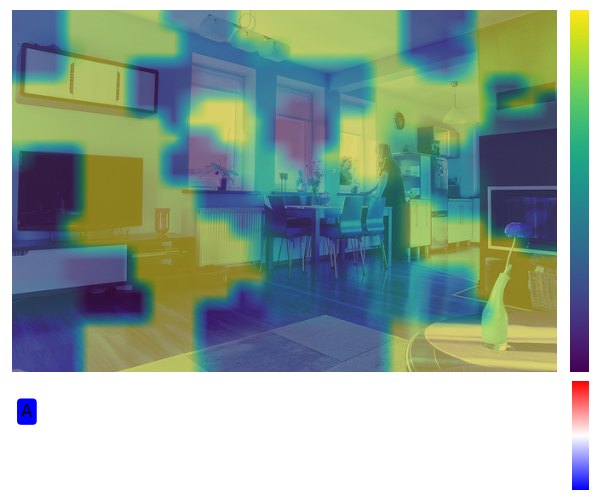

In [52]:
visualize_explanation(res[2], ans_text, res[3])

### LLAVA-CAM

In [3]:
import contextlib

from typing import Optional, List, Tuple
from PIL import Image
import torch
import torch.nn as nn
import numpy as np

from src.models import BaseVLMWrapper
from src.explainers import BaseExplainer

class LLaVACAMExplainer(BaseExplainer):
    def __init__(self, 
                 model_wrapper: BaseVLMWrapper,
                 target_layer_name: str,
                 num_samples: int=10,
                 noise_std: float=.1,
                 token_wise = True,
                 ):
        super().__init__(model_wrapper)
        
        self.target_layer_name = target_layer_name
        self.num_samples = num_samples
        self.noise_std = noise_std
        self.token_wise = token_wise


    def save_feature_maps(self, module, input, output):
        """Hook to save the feature maps during forward pass."""
        self.feature_maps = output
        #output.retain_grad()

    def save_gradients(self, module, grad_input, grad_output):
        """Hook to save the gradients during backward pass."""
        self.gradients = grad_output[0].detach()
    
    def register_hooks(self):
        for name, module in self.wrapper.model.named_modules():
            if self.target_layer_name in name:
                module.register_forward_hook(self.save_feature_maps)
                module.register_backward_hook(self.save_gradients)
    
    def clear_hooks(self):
        self.feature_maps = None
        self.gradients = None

        torch.cuda.empty_cache()

    @contextlib.contextmanager
    def manage_explainability_state(self):
        """
        Temporarily patches the model and attaches hooks. 
        Guarantees complete restoration upon exit.
        """
        
        # Register hooks to capture activations (forward) and gradients (backward)
        self.register_hooks()
        
        try:
            # Yield control back to the main function
            yield 
        finally:
            # This runs NO MATTER WHAT (even if your math throws an error)
            self.clear_hooks()
        
    def compute_cam(self, mask):
        """Applies Grad-CAM channel-weighting to the selected tokens."""
        # Slice the sequence down to just the tokens we care about
        # Shape: [num_selected_tokens, Channels]
        activations = self.feature_maps.detach()
        gradients = self.gradients.detach()
        
        feats = activations[0, mask, :]
        grads = gradients[0, mask, :]

        # Global Average Pooling of the gradients across the tokens
        # Shape: [Channels]
        pooled_grads = grads.mean(dim=0)

        # Weight the feature maps
        # [num_selected_tokens, Channels] * [Channels]
        weighted_feats = feats * pooled_grads

        # Average across the channel dimension to get a single score per token
        # Shape: [num_selected_tokens]
        cam = weighted_feats.mean(dim=-1)

        # Grad-CAM requires a ReLU to keep only positive contributions
        cam = nn.functional.relu(cam)
        
        # # Normalize to [0, 1]
        # if cam.max() > 0:
        #     cam = cam / cam.max()
            
        return cam.detach().cpu()

    def _add_noise(self, image, noise_std):
        if isinstance(image, str):
            pil_img = Image.open(image).convert("RGB")
        elif isinstance(image, Image.Image):
            pil_img = image.copy().convert("RGB")
        else:
            raise TypeError(f"Unsupported input type: {type(image)}")

        img_arr = np.array(pil_img).astype(np.float32)

        noise = np.random.normal(0, noise_std * 255, img_arr.shape)

        noisy_arr = np.clip(img_arr + noise, 0, 255).astype(np.uint8)

        noisy_pil = Image.fromarray(noisy_arr)

        return noisy_pil

    def get_raw_attributions(self,
                            image,
                            text,
                            target_indices=None,
                            average=False,
                            **kwargs):
        
        

        
        if self.num_samples == 0:
            smooth_token_cam, smooth_pixel_cam = self.llava_cam(image=image,
                                                            text=text,
                                                            **kwargs
                                                            )
        else:

            smooth_token_cam = None
            smooth_pixel_cam = None
            for _ in range(self.num_samples):
                # Generate noisy image
                noisy_img = self._add_noise(image, noise_std=self.noise_std)
                noisy_token_cam, noisy_pixel_cam = self.llava_cam(image=noisy_img,
                                                                text=text,
                                                                **kwargs
                                                                )
                if smooth_token_cam is None:
                    smooth_token_cam = noisy_token_cam
                else:
                    smooth_token_cam += noisy_token_cam
                
                if smooth_pixel_cam is None:
                    smooth_pixel_cam = noisy_pixel_cam
                else:
                    smooth_pixel_cam += noisy_pixel_cam
            
            # Average
            smooth_token_cam /= self.num_samples
            smooth_pixel_cam /= self.num_samples
        
        return smooth_token_cam, smooth_pixel_cam
        
        

    def llava_cam(self,
            image,
            text: str,
            **kwargs) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Generates raw attributions. 
        Returns: Tuple of (Attributions, Feature_Maps) of shape (Batch, Seq_Len, Hidden_Dim).
        """

        inputs = self.wrapper.get_inputs(image, text)

        full_ids = kwargs.get("full_ids", None) # (seq_len,)
        if full_ids is None:
            raise ValueError("You should pass the generated_ids tensor")
        
        # Define the indices of the answers tokens and visual tokens 
        t_start = inputs["input_ids"].shape[1]
        t_end = full_ids.shape[-1]
        gen_len = t_end - t_start
                
        inputs["input_ids"] = full_ids.clone().unsqueeze(0)  # (batch, seq_len)
        inputs["attention_mask"] = torch.ones_like(inputs["input_ids"])

        
        image_token_id = self.wrapper.model.config.image_token_id
        # Boolean Masks (flattened to 1D)
        full_ids_1d = full_ids.squeeze()
        prompt_mask = torch.arange(full_ids_1d.size(-1),
                                   device=full_ids_1d.device) < t_start
        is_image_mask = (full_ids_1d == image_token_id)
        is_text_mask = ~is_image_mask

        final_text_mask = is_text_mask & prompt_mask
        final_image_mask = is_image_mask & prompt_mask

        
        with self.manage_explainability_state():
            outputs = self.wrapper.model(**inputs)
            logits = outputs.logits[:, t_start-1:t_end-1, :] # (1, num_ans_tokens, vocab_size)

            new_ids = full_ids[t_start:t_end] #.unsqueeze(0).unsqueeze(-1) # (1, num_ans_tokens, 1)
            new_ids = new_ids.unsqueeze(0).unsqueeze(-1)
            
            target_logits = logits.gather(dim=-1, index=new_ids).squeeze(-1) # (1, num_ans_tokens)

            if self.token_wise:
                token_attributions = []
                pixel_attributions = []

                # Iterate on each generated token's logit
                for i in range(gen_len):
                    # Backward Pass
                    self.wrapper.model.zero_grad()
                    target_logits[:, i].backward(retain_graph=True)

                    # Safety check: Did the hook catch the gradients?
                    if self.gradients is None:
                        raise RuntimeError(f"Gradients were dropped at iteration {i}")

                    # Compute CAM for each word
                    tok_attr = self.compute_cam(final_text_mask)
                    pix_attr = self.compute_cam(final_image_mask)

                    self.gradients = None

                    token_attributions.append(tok_attr)
                    pixel_attributions.append(pix_attr)
                
                # Stack the list of 1D tensors into a 2D tensor
                token_attribution = torch.stack(token_attributions, dim=0) # [gen_len, num_text_tokens]
                pixel_attribution = torch.stack(pixel_attributions, dim=0) # [gen_len, num_image_tokens]
                

            else:
                # Generate 1 attribution for the whole sequence
                answer_score = target_logits.sum()

                # Backward Pass
                self.wrapper.model.zero_grad()
                answer_score.backward(retain_graph=True)

                # Compute text and image attributions
                token_attribution = self.compute_cam(final_text_mask).unsqueeze(0)
                pixel_attribution = self.compute_cam(final_image_mask).unsqueeze(0)               

        return token_attribution, pixel_attribution
    



In [4]:
# del model, processor
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id, attn_implementation="eager")
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [48]:
for name, module in model.named_modules():
    if "35" in name:
        print(name)
        print(type(module))

model.language_model.layers.35
<class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLDecoderLayer'>
model.language_model.layers.35.self_attn
<class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLAttention'>
model.language_model.layers.35.self_attn.q_proj
<class 'bitsandbytes.nn.modules.Linear4bit'>
model.language_model.layers.35.self_attn.k_proj
<class 'bitsandbytes.nn.modules.Linear4bit'>
model.language_model.layers.35.self_attn.v_proj
<class 'bitsandbytes.nn.modules.Linear4bit'>
model.language_model.layers.35.self_attn.o_proj
<class 'bitsandbytes.nn.modules.Linear4bit'>
model.language_model.layers.35.self_attn.rotary_emb
<class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLRotaryEmbedding'>
model.language_model.layers.35.mlp
<class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2MLP'>
model.language_model.layers.35.mlp.gate_proj
<class 'bitsandbytes.nn.modules.Linear4bit'>
model.language_model.layers.35.mlp.up_proj
<class 'bitsan

In [5]:
from src.models.qwen_vl import QwenVL_Wrapper

model_wrapper = QwenVL_Wrapper(model, processor)


In [6]:
import time

from torch.utils.data import DataLoader
from src.datasets import COCOGroundingDataset
from src.metrics.utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game
from src.explainers.rollout import RolloutExplainer

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

category = dataset.id2name
mapper = OntologyMapper(coco_categories=category, threshold=0.5)



loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [7]:
for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    break

In [8]:
pred_results = model_wrapper.predict(inputs)
full_ids = pred_results["full_ids"]

In [9]:
target_layer_name = "layers.34.post_attention_layernorm"
explainer = LLaVACAMExplainer(model_wrapper,
                              target_layer_name=target_layer_name,
                              num_samples=2,
                              token_wise=True
                              )

In [10]:
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
start_time = time.time()
text_attrs, img_attrs = explainer.get_raw_attributions(image=img,
                                    text=q,
                                    target_indices=None,
                                    average=False,
                                    full_ids=full_ids,
                                    )
torch.cuda.synchronize()
exec_time = time.time() - start_time
peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) # Convert to MB

print(exec_time, peak_vram)

/home/jky/xai-vdoc-benchmark/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


12.035994529724121 9441.01513671875


In [15]:
vision_mask = (inputs["input_ids"] == model.config.image_token_id).to(model.device)

In [11]:
text_attrs

tensor([[5.0545e-05, 5.3406e-05, 9.6560e-06, 6.2466e-05, 6.6757e-05, 1.0109e-04,
         1.2779e-04, 9.5367e-05, 7.4387e-05, 7.1824e-06, 6.3777e-06, 1.3173e-05,
         5.6267e-05, 3.7193e-05, 1.7956e-06, 1.8001e-05, 3.3379e-05, 8.6308e-05,
         7.8201e-05, 9.1076e-05, 8.9645e-05, 1.6689e-05, 1.2934e-05, 4.6253e-05,
         5.2691e-05, 5.2154e-06],
        [5.5879e-07, 0.0000e+00, 0.0000e+00, 5.8860e-07, 4.5821e-07, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         1.6997e-08, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00],
        [2.0489e-07, 0.0000e+00, 0.0000e+00, 7.7300e-08, 1.8394e-08, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+

In [12]:
img_attrs

tensor([[0.0000e+00, 9.7207e-09, 1.3271e-08,  ..., 4.8429e-08, 5.7917e-09,
         0.0000e+00],
        [0.0000e+00, 1.0186e-08, 0.0000e+00,  ..., 2.7008e-08, 0.0000e+00,
         8.0327e-09],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [0.0000e+00, 1.9791e-09, 0.0000e+00,  ..., 1.5207e-09, 8.0036e-10,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]], dtype=torch.bfloat16)

In [13]:
import math
import torch
import torch.nn.functional as F

def align_llm_visuals_to_pixels(pixel_attribution: torch.Tensor,
                                inputs: dict) -> torch.Tensor:
    """
    Reshapes and interpolates LLM-level pixel attributions to match 
    the exact spatial footprint of the model's original pixel_values.
    
    Args:
        pixel_attribution: Tensor of shape [gen_len, num_llm_tokens]
        inputs: The original Hugging Face inputs dictionary.
        
    Returns:
        Tensor of shape [gen_len, target_num_pixels]
    """
    pixel_values = inputs.get("pixel_values")
    
    # Safety check: if there is no image, just return the raw tensor
    if pixel_values is None or pixel_attribution.numel() == 0:
        return pixel_attribution
        
    gen_len, num_llm_tokens = pixel_attribution.shape
    
    # ---------------------------------------------------------
    # CASE A: Standard VLM (e.g., LLaVA, BLIP) 
    # Shape is (C, H, W) or (Batch, C, H, W)
    # ---------------------------------------------------------
    if pixel_values.ndim >= 3 and pixel_values.shape[-3] in [1, 3, 4]:
        target_h, target_w = pixel_values.shape[-2], pixel_values.shape[-1]
        
        # Standard models usually have square ViT grids
        llm_grid_h = llm_grid_w = int(math.sqrt(num_llm_tokens))
        
        interp_mode = 'bilinear'
        align_corners = False
        
    # ---------------------------------------------------------
    # CASE B: Packed Patches VLM (e.g., Qwen-VL) 
    # Shape is (grid_h * grid_w, patch_dim)
    # ---------------------------------------------------------
    elif 'image_grid_thw' in inputs:
        _, target_h, target_w = inputs['image_grid_thw'][0].cpu().numpy().tolist()
        
        # Qwen uses a 2x2 spatial merge before the LLM
        spatial_merge_size = 2
        llm_grid_h = target_h // spatial_merge_size
        llm_grid_w = target_w // spatial_merge_size
        
        interp_mode = 'nearest'
        align_corners = None
        
    else:
        raise ValueError("Could not infer spatial grid from inputs. Unknown architecture.")

    # 1. Reshape to native 2D grid
    # Shape: [gen_len, 1, llm_grid_h, llm_grid_w]
    pixel_attr_2d = pixel_attribution.reshape(gen_len, 1, llm_grid_h, llm_grid_w)

    # 2. Spatially upsample to match pixel_values
    # Shape: [gen_len, 1, target_h, target_w]
    pixel_attr_upscaled = F.interpolate(
        pixel_attr_2d, 
        size=(target_h, target_w), 
        mode=interp_mode,
        align_corners=align_corners
    )

    # 3. Flatten back to 1D
    # Shape: [gen_len, target_h * target_w]
    return pixel_attr_upscaled.reshape(gen_len, -1)



In [16]:
img_attr_aligned = align_llm_visuals_to_pixels(img_attrs, inputs)

In [17]:
img_attr_aligned.shape

torch.Size([21, 1380])

In [62]:

for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    pred_results = model_wrapper.predict(inputs)
    full_ids = pred_results["full_ids"]

    tokens = pred_results["new_ids"].cpu().unsqueeze(0).numpy().tolist()
    words, tokens_id = ids_to_word_groups(tokens,
                                          model_wrapper.processor)
    
    _, grid_h, grid_w = inputs['image_grid_thw'][0].cpu().numpy().tolist()
    
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()
    text_attrs, img_attrs = explainer.get_raw_attributions(image=img,
                                       text=q,
                                       target_indices=None,
                                       average=False,
                                       full_ids=full_ids,
                                       )
    torch.cuda.synchronize()
    exec_time = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) # Convert to MB

    print(exec_time, peak_vram)
    
    # img_attrs = img_attrs.reshape(-1, grid_h, grid_w)

    # pg_scores = []
    # energy_pg_scores = []
    # for i, word in enumerate(words):
    #     cat_id = mapper.map_word(word)
    #     if cat_id is None:
    #         continue

    #     cat_name = category[cat_id]

    #     if cat_name not in masks:
    #         print(f"Word: '{word:10}' | Mapped: '{cat_name:10}' | Result: Hallucinated (Not in image)")
    #         continue

    #     # Resize heatmap to match ground truth mask dimensions
    #     gt_mask = masks[cat_name].numpy()
    #     h_gt, w_gt = gt_mask.shape

    #     # Pool the image attributions for this specific word
    #     img_attr = pool_heatmaps(img_attrs, tokens_id[i], method='max')
        
    #     heatmap_raw = img_attr.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
    #     heatmap_resized = torch.nn.functional.interpolate(
    #         heatmap_raw, size=(h_gt, w_gt), mode='bilinear', align_corners=False
    #     ).squeeze().cpu().numpy()
    #     pg_score = point_game(gt_mask, heatmap_resized)
    #     energy_score = energy_point_game(gt_mask, heatmap_resized)

    #     pg_scores.append(pg_score)
    #     energy_pg_scores.append(energy_score)

    #     print(f"Word: '{word:10}' | Mapped: '{cat_name:10}'")


    break


RuntimeError: can't retain_grad on Tensor that has requires_grad=False

### iGOS

In [27]:
"""
Utility functions for interpretation generation.
© copyright 2024 Bytedance Ltd. and/or its affiliates.
Modified from Tyler Lawson, Saeed khorram. https://github.com/saeed-khorram/IGOS
"""

import torch
import os
import cv2
import sys

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from textwrap import fill
from io import BytesIO

# mean and standard deviation for the imagenet dataset
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

special_ids = [12, 13, 29871, 29889, 29892, 1919, 869, 29899,
               29897, 29898, 278, 322, 310, 263, 385, 445, 393, 338, 411]
CHOICES = ['A','B','C','D','E','F']

def eprint(*args, **kwargs):
    """
        Prints to the std.err

    :param args:
    :param kwargs:
    :return:
    """
    print(*args, file=sys.stderr, **kwargs)


def get_data(args, row):
    if args.dataset == 'MMVP':
        photo_id = row['lndex']
        image_path = os.path.join(args.image_folder, f"{photo_id}.jpg")
        image = Image.open(image_path).convert('RGB')

        if args.choices:
            opts = row['Options'].split(' ')
            cur_prompt = f"{row['Question']}\nA. {opts[1]}\nB. {opts[3]}\n"
            qs = cur_prompt + "Answer only with the option's letter A or B from the given choices directly."
        else:
            qs = row['Question']
            cur_prompt = qs
    elif args.dataset == 'cvbench':
        image_path = os.path.join(args.image_folder, row["filename"])
        image = Image.open(image_path).convert('RGB')
        if args.choices:
            choices = row['choices']
            choices_text = ''
            for j,item in enumerate(choices):
                choices_text += f'\n{CHOICES[j]}. {item}'

            cur_prompt = row['question'] + choices_text
            qs = cur_prompt + '\nAnswer with the option\'s letter from the given choices directly.'
        else:
            qs = row['question']
            cur_prompt = qs
    elif args.dataset == 'mmstar':
        image_stream = BytesIO(row["image"]['bytes'])
        image = Image.open(image_stream).convert('RGB')
        if args.choices:
            cur_prompt = row['question']
            qs = cur_prompt + '\n' + "Answer with the option's letter from the given choices directly."
        else:
            qs = row['question'].split('?')[0] + '?'
            cur_prompt = qs
            
    elif args.dataset == 'llava-bench':
        image_path = os.path.join(args.image_folder, row["image"])
        image = Image.open(image_path).convert('RGB')
        cur_prompt = row['text']
        qs = cur_prompt
    return image, qs, cur_prompt
    

def get_kernel_size(image_size):
    if image_size[0] >=2000:
        kernel_size = 501
    elif image_size[0] >= 800:
        kernel_size = 301
    elif image_size[0] >= 500:
        kernel_size = 201
    else:
        kernel_size = 101
    return kernel_size

def save_heatmaps(masks, images, size, index, index_o,
                  outdir, model_name, box,
                  classes, labels, out=224):
    if isinstance(images, list):
        images = images[1]
    elif images.shape[0] != 1:
        images = images[0].unsqueeze(0)
    masks = masks.view(-1, 1, size, size)
    up = torch.nn.UpsamplingBilinear2d(size=images.shape[-2:]).to(masks.device)

    u_mask = up(masks)
    u_mask = u_mask.permute((0,2, 3, 1))

    # Normalize the mask
    u_mask = (u_mask - torch.min(u_mask)) / (torch.max(u_mask) - torch.min(u_mask))
    u_mask = u_mask.cpu().detach().numpy()

    # deprocess images
    images = images.cpu().detach().permute((0, 2, 3, 1)) * std + mean
    images = images.numpy()

    for i, (image, u_mask) in enumerate(zip(images, u_mask)):

        # get the color map and normalize to 0-1
        heatmap = cv2.applyColorMap(np.uint8(255 * u_mask), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap / 255)
        # overlay the mask over the image
        #overlay = (u_mask ** 0.8) *0.5* image + (1 - u_mask ** 0.8) * heatmap
        overlay = 0.5 * heatmap + 0.5 * image
        cv2.normalize(overlay.astype('float'), None, 0.0, 1.0, cv2.NORM_MINMAX)
        overlay[overlay < 0] = 0

        plt.imsave(os.path.join(outdir, f'{index+i}_{index_o}_heatmap.jpg'), heatmap)
        plt.imsave(os.path.join(outdir, f'{index+i}_{index_o}_overlay.jpg'), overlay)


def save_masks(masks, index, categories, mask_name, outdir):
    """
        Saves the generated masks as numpy.ndarrays.

    :param masks:
    :param index:
    :param categories:
    :param mask_name:
    :param outdir:
    :return:
    """
    masks = masks.cpu().detach().numpy()
    for i, (mask, category) in enumerate(zip(masks, categories), start=index):
        np.save(os.path.join(outdir, f'{mask_name}_{i+1}_mask_{category}.npy'), mask)

def save_loss(loss_del, loss_ins, loss_l1, loss_tv,
              loss_l2, index, index_o, outdir,
              loss_comb_del=None, loss_comb_ins=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    iterations = np.arange(len(loss_del))

    if loss_comb_del:
        ax1.plot(iterations, loss_comb_del, label='loss comb del', marker='^')
    if loss_comb_ins:
        ax1.plot(iterations, loss_comb_ins, label='loss comb ins', marker='<')
    ax1.plot(iterations, loss_del, label='loss del', marker='o')
    ax1.plot(iterations, loss_ins, label='loss ins', marker='s')

    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss Value')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(iterations, loss_tv, label='loss TV', marker='o')
    ax2.plot(iterations, loss_l2, label='loss L2', marker='+')
    ax2.plot(iterations, loss_l1, label='loss L1', marker='x')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss Value')
    ax2.grid(True)
    ax2.legend()

    plt.savefig(os.path.join(outdir, f'{index}_{index_o}_losses.jpg'),
                bbox_inches='tight', pad_inches = 0)
    plt.close()

def save_curves(del_curve, ins_curve, index_curve, index, index_o, outdir):
    """
        Save the deletion/insertion curves for the generated masks.

    :param del_curve:
    :param ins_curve:
    :param index_curve:
    :param index:
    :param index_o:
    :param outdir:
    :return:
    """
    for i in range(len(del_curve)):
        fig, (ax, ax1) = plt.subplots(2, 1)
        ax.plot(index_curve, del_curve[i], color='r', label='deletion')
        ax.fill_between(index_curve, del_curve[i], facecolor='maroon', alpha=0.4)
        ax.set_ylim([-0.05, 1.05])
        ax.tick_params(labelsize=14)
        ax.set_yticks(np.arange(0, 1.01, 1))
        ax.legend(['Deletion'], fontsize='x-large')
        ax.text(0.5, 0.5, 'AUC: {:.4f}'.format(auc(del_curve[i])),
                fontsize=14, horizontalalignment='center', verticalalignment='center')

        ax1.plot(index_curve, ins_curve[i], color='b', label='Insertion')
        ax1.fill_between(index_curve, ins_curve[i], facecolor='darkblue', alpha=0.4)
        ax1.set_ylim([-0.05, 1.05])
        ax1.tick_params(labelsize=14)
        ax1.set_yticks(np.arange(0, 1.01, 1))
        ax1.legend(['Insertion'], fontsize='x-large')
        ax1.text(0.5, 0.5, 'AUC: {:.4f}'.format(auc(ins_curve[i])),
                 fontsize=14, horizontalalignment='center', verticalalignment='center')

        # save the plot
        plt.savefig(os.path.join(outdir, f'{index}_{index_o}_curves.jpg'),
                    bbox_inches='tight', pad_inches = 0)
        plt.close()


def save_images(images, index, index_o, outdir, classes,
                labels, pred_data, text=None):
    """
        saves original images into output directory

    :param images:
    :param index:
    :param index_o:
    :param outdir:
    :param classes:
    :param labels:
    :return:
    """
    if isinstance(images, list):
        images = images[1]
    elif images.shape[0] != 1:
        images = images[0].unsqueeze(0)
    images_ = images.cpu().detach().permute((0, 2, 3, 1)) * std + mean
    for i, image in enumerate(images_):
        wrapped_text = fill(text, width=60)
        fig, ax = plt.subplots(figsize=(5, 5))

        plt.subplots_adjust(top=0.8)
        ax.imshow(image.numpy())
        ax.axis('off')
        fig.text(0.5, 0.9, wrapped_text, ha='center', va='top', wrap=True, fontsize=10)
        plt.savefig(os.path.join(outdir, f'{index+i}_{index_o}_image.jpg'), bbox_inches='tight', pad_inches=0.2)


def auc(array):
    """
        calculates area under the curve (AUC)

    :param array:
    :return:
    """
    return (sum(array) - array[0]/2 - array[-1]/2)/len(array)


def get_initial(pred_data, k, init_posi, init_val, input_size, out_size):
    """
        filter the detection results by the threshold (predicted score)

    :param pred_data:
    :param k:
    :param initial_posi:
    :param init_val:
    :param input_size:
    :param out_size:
    :return:
    """
    interval_r = (pred_data['boxes'][:,2] - pred_data['boxes'][:,0]) / k
    interval_c = (pred_data['boxes'][:,3] - pred_data['boxes'][:,1]) / k
    num_row = init_posi // k
    num_col = init_posi - num_row * k
    init_boxes = np.concatenate([
                            [pred_data['boxes'][:,0] + interval_r * num_row], # x1
                            [pred_data['boxes'][:,1] + interval_c * num_col], # y1
                            [pred_data['boxes'][:,0] + interval_r * (num_row + 1)], # x2
                            [pred_data['boxes'][:,1] + interval_c * (num_col + 1)], # y2
                            ], axis=0).T 

    pred_data['init_masks'] = []
    down = torch.nn.UpsamplingBilinear2d(size=(out_size, out_size))

    for ith, box in enumerate(init_boxes):
        init_mask = torch.zeros((input_size[0], input_size[1])).unsqueeze(0)
        init_mask[int(box[0]) : int(box[2]), int(box[1]) : int(box[3])] = 1

        if 'masks' in pred_data.keys():
            init_mask = init_mask * pred_data['masks'][ith]
        
        init_mask = down(init_mask.unsqueeze(0)) * init_val
        pred_data['init_masks'].append(1 - init_mask)
    return pred_data


def generate(args, model, input_ids, image, image_size):
    output_ids = model.generate(
            input_ids,
            images=image,
            #image_sizes=image_size,
            do_sample=True if args.temperature > 0 else False,
            temperature=args.temperature,
            top_p=args.top_p,
            num_beams=args.num_beams,
            max_new_tokens=args.max_new_tokens,
            use_cache=True)
    output_ids = output_ids[:,1:-1]
    return output_ids

def match_keywords(lst, sublist):
    lst_str = ','.join(map(str, lst))
    sublist_str = ','.join(map(str, sublist))
    start_idx = lst_str.find(sublist_str)

    if start_idx == -1:
        return None

    start = lst_str[:start_idx].count(',')
    end = start + len(sublist) - 1
    return [start, end]


In [28]:
"""
Helper function for the IGOS explanation methods.
© copyright 2024 Bytedance Ltd. and/or its affiliates.
Modified from Tyler Lawson, Saeed khorram. https://github.com/saeed-khorram/IGOS
"""

import torch
import torch.nn.functional as F
import math

#from .utils import special_ids

def cosine_decay(init, iter):
    return init * (1 + math.cos(math.pi * iter)) / 2

def exp_decay(init, iter, gamma=0.2):
    return init * math.exp(-gamma * iter)

def tv_norm(image, beta=2):
    """
    Calculates the total variation.
    :param image:
    :param beta:
    :return:
    """
    image = image[:, 0, :, :]
    a = torch.mean(torch.abs((image[:, :-1, :] - image[:, 1:, :]).view(image.shape[0], -1)).pow(beta), dim=1)
    b = torch.mean(torch.abs((image[:, :, :-1] - image[:, :, 1:]).view(image.shape[0], -1)).pow(beta), dim=1)
    return a + b


def bilateral_tv_norm(image, mask, tv_beta=2, sigma=1):
    """
        Calculates the bilateral total variation.

    :param image:
    :param mask:
    :param tv_beta:
    :param sigma:
    :return:
    """
    # tv term
    mask_ = mask[:, 0, :]
    a = torch.mean(torch.abs((mask_[:, :-1, :] - mask_[:, 1:, :]).view(mask.shape[0], -1)).pow(tv_beta), dim=1)
    b = torch.mean(torch.abs((mask_[:, :, :-1] - mask_[:, :, 1:]).view(mask.shape[0], -1)).pow(tv_beta), dim=1)
    # bilateral tv in the image space
    if isinstance(image, list):
        image = image[0]
    elif image.shape[0] > 1:
        image = image[0].unsqueeze(0)

    up_mask_ = upscale(mask, image)
    bil_a = torch.mean(torch.exp(-(image[:, :, :-1, :] - image[:, :, 1:, :]).mean(dim=1) ** 2 / sigma).view(mask.shape[0], -1)
                    * torch.abs((up_mask_[:, :, :-1, :] - up_mask_[:, :, 1:, :]).view(up_mask_.shape[0], -1)).pow(tv_beta), dim=1)
    bil_b = torch.mean(torch.exp(-(image[:, :, :, :-1] - image[:, :, :, 1:]) ** 2 / sigma).mean(dim=1).view(mask.shape[0], -1)
                    * torch.abs((up_mask_[:, :, :, :-1] - up_mask_[:, :, :, 1:]).view(up_mask_.shape[0], -1)).pow(tv_beta), dim=1)
    return 0.5 * (a + b + bil_a + bil_b)



def upscale(masks: torch.Tensor, images,
            mode: str = 'bilinear',
            align_corners: bool = False):
    """
    将 masks 上采样到与 images 的空间尺寸一致。
    支持 images 为:
      - 单图 3D: [C, H, W]
      - 批量 4D: [B, C, H, W]
      - list[Tensor]: 每个为 [C,H,W] 或 [H,W]
    masks 形状可为 [h,w] / [B,h,w] / [B,1,h,w] / [1,1,h,w]
    """
    # 规范 masks -> [B,1,h,w]
    if masks.dim() == 2:
        masks = masks.unsqueeze(0).unsqueeze(0)           # [1,1,h,w]
    elif masks.dim() == 3:
        masks = masks.unsqueeze(1)                         # [B,1,h,w]
    elif masks.dim() == 4 and masks.size(1) != 1:         # [B,C,h,w] 但 C!=1
        masks = masks[:, :1, ...]                          # 取第1通道

    def _interp(msk, size_hw, dev):
        H, W = size_hw
        msk = msk.to(dev).float()
        return F.interpolate(msk, size=(H, W), mode=mode, align_corners=align_corners)

    # --- images 为单图 3D: [C,H,W]
    if isinstance(images, torch.Tensor) and images.dim() == 3:
        _, H, W = images.shape
        # 若 masks 的 batch 是 1，就保持 1；也可按需 expand 到 1
        return _interp(masks, (H, W), images.device)       # -> [B,1,H,W]

    # --- images 为批量 4D: [B,C,H,W]
    if isinstance(images, torch.Tensor) and images.dim() == 4:
        B, _, H, W = images.shape
        if masks.size(0) == 1 and B > 1:
            masks = masks.expand(B, -1, -1, -1).contiguous()
        elif masks.size(0) != B:
            raise ValueError(f"Batch mismatch: masks B={masks.size(0)}, images B={B}")
        return _interp(masks, (H, W), images.device)       # -> [B,1,H,W]

    # --- images 为 list
    if isinstance(images, list):
        outs = []
        for img in images:
            if img.dim() == 2:     # [H,W]
                H, W = img.shape[-2], img.shape[-1]
                dev = img.device
            elif img.dim() == 3:   # [C,H,W]
                _, H, W = img.shape
                dev = img.device
            else:
                raise ValueError("Each image in list must be 2D or 3D tensor.")
            outs.append(_interp(masks, (H, W), dev))       # -> [B,1,H,W]
        return outs

    raise ValueError("images must be a 3D/4D Tensor or a list of images.")

def interval_score(args, model, model_name, images, baseline, label, up_masks, num_iter, noise=True, 
                   prompt=None, image_size=None, positions=None, device=None):
    if device is None:
        device = model.device
    if model_name == 'llava' or model_name == 'llava_next' or model_name == 'mgm':
        # The intervals to approximate the integral over
        intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).to(device).view(-1, 1, 1, 1)
        interval_masks = up_masks.unsqueeze(1) * intervals
        local_images = phi(images.unsqueeze(1), baseline.unsqueeze(1), interval_masks)

        if noise:
            local_images = local_images + torch.randn_like(local_images) * .2

        local_images = local_images.transpose(0, 1)
        input_ids = torch.cat((prompt, label), dim=1)
        positions = torch.tensor(positions).to(device)

        losses = torch.tensor(0.).to(device)
        for single_img in local_images:
            single_img = single_img.half()
            probs = pred_probs(args, model, input_ids, label, single_img, image_size)
            #losses += probs[positions].mean()
            losses += torch.log(probs)[positions].sum()
    
    elif model_name == 'cambrian':
        # The intervals to approximate the integral over
        intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).to(device).view(-1, 1, 1, 1)
        interval_masks = [up_mask.unsqueeze(1) * intervals for up_mask in up_masks]
        local_images = [phi(image.unsqueeze(1), base.unsqueeze(1), interval_mask) for image, base, interval_mask in zip(images, baseline, interval_masks)]

        if noise:
            local_images = [local_image + torch.randn_like(local_image) * .2 for local_image in local_images]

        local_images = [local_image.squeeze(0) for local_image in local_images]
        local_images = [[local_images[i][j] for i in range(len(local_images))] for j in range(num_iter)]
        input_ids = torch.cat((prompt, label), dim=1)
        positions = torch.tensor(positions).to(device)
        losses = torch.tensor(0.).to(device)

        for single_img in local_images:
            single_img = [item.unsqueeze(0).half() for item in single_img]
            probs = pred_probs(args, model, input_ids, label, single_img, image_size)
            #losses += probs[positions].mean()
            losses += torch.log(probs)[positions].sum()

    return losses / num_iter


def integrated_gradient(args, model, model_name, image, baseline, label, up_masks, num_iter,
                        noise=True, prompt=None, image_size=None, positions=None):
    loss = interval_score(
                args,
                model,
                model_name, 
                image,
                baseline,
                label,
                up_masks,
                num_iter,
                noise,
                prompt,
                image_size,
                positions
                )
    #loss.sum().backward(retain_graph=True)
    loss.sum().backward(retain_graph=True)
    return loss.sum().item()

def line_search(masks, total_grads, loss_func, alpha=8, beta=0.0001, decay=0.2,):
    # Speed up computations, reduce memory usage, and ensure no autograd
    # graphs are created
    device = masks.device
    with torch.no_grad():
        i = 0
        mod = len(masks.shape) - 3
        num_inputs = masks.shape[0]
        # The indices of masks that still need their alphas updated
        indices = torch.ones(num_inputs, dtype=torch.bool).to(device)
        # Create initial alpha values for each mask
        alphas = torch.ones(num_inputs).to(device) * alpha

        up_masks = upscale(masks.view(-1,*masks.shape[mod:])).view(-1, *masks.shape[1:mod], 1, upscale.out_size, upscale.out_size)

        # Compute the base loss used in the condition
        base_losses = loss_func(up_masks, masks, indices).view(-1)
        t = -beta * (total_grads ** 2).view(num_inputs, -1).sum(dim=1).view(num_inputs)

        while True:
            # Create a new mask with the updated alpha value to
            # see if it meets condition
            new_masks = torch.clamp(masks[indices] - alphas[indices].view(-1,*(1,) * mod,1,1) * total_grads[indices], 0, 1)
            up_masks = upscale(new_masks.view(-1,*masks.shape[mod:])).view(-1,*masks.shape[1:mod], 1, upscale.out_size, upscale.out_size)
            # Calculate new losses
            losses = loss_func(up_masks, new_masks, indices).view(-1)
            # Get indices for each alpha that meets the condition for
            # their corresponding mask
            indices[indices] = losses > base_losses[indices] + alphas[indices] * t[indices]
            # Same for this, but for if the alpha values are too low (\alpha_l)
            indices[indices] *= (alphas[indices] >= 0.00001)
            # Break out of the loop if all alpha values satisfy the condition
            # or are too low
            if not indices.sum():
                break
            # Otherwise update alphas
            alphas[indices] *= decay
            i += 1
    return alphas.view(-1,1,1,1)


def phi(img, baseline, mask):
    """
        Composes an image from img and baseline according to the mask values.

    :param img:
    :param baseline:
    :param mask:
    :return:
    """
    return img.mul(mask) + baseline.mul(1-mask)


def metric(args, image, baseline, mask, model, model_name, label, label_i, pred_data, size=28, prompt=None, image_size=None, positions=None, resolution=None):
    with torch.no_grad():
        # The dimensions for the image
        #img_size = image.shape[-1]
        # Compute the total number of pixels in a mask
        mask_pixels = torch.prod(torch.tensor(mask.shape[1:])).item()
        num_pixels = torch.prod(torch.tensor(mask.shape[1:])).item()
        # Compute the step size
        step=max(1, num_pixels // 50)
        # Used for indexing with batch sizes
        l = torch.arange(1)
        # The unmasked score
        og_scores = score_output(args, image, image_size, model, model_name, l, label, prompt, positions)
        # The baseline score
        blur_scores = score_output(args, baseline, image_size, model, model_name, l, label, prompt, positions)
        # Initial values for the curves
        del_curve = [og_scores]
        ins_curve = [blur_scores]
        index = [0.]

        # True_mask is used to hold 1 or 0. Either show that pixel or blur it.
        true_mask = torch.ones((mask.shape[0], mask_pixels)).cuda()
        del_scores = torch.zeros(mask.shape[0])
        ins_scores = torch.zeros(mask.shape[0])
        # Sort each mask by values and store the indices.
        elements = torch.argsort(mask.view(mask.shape[0], -1), dim=1)
        for pixels in range(0, num_pixels, step):
            # Get the indices used in this iteration
            indices = elements[l,pixels:pixels+step].squeeze().view(1, -1)
            # Set those indices to 0
            true_mask[l, indices.permute(1,0)] = 0
            up_mask = upscale(true_mask.view(-1, 1, size,size), image, resolution)
            # Mask the image for deletion
            if isinstance(image, list):
                del_image = [phi(x, y, z).half() for x, y, z in zip(image, baseline, up_mask)]
            else:
                del_image = phi(image, baseline, up_mask).half()
            # Calculate new scores
            outputs = score_output(args, del_image, image_size, model, model_name, l, label, prompt, positions)
            del_curve.append(outputs)
            index.append((pixels+step)/num_pixels)
            outputs = (outputs-blur_scores) / (og_scores-blur_scores)
            del_scores += outputs.cpu() * step if pixels + step < num_pixels else num_pixels - pixels

            # Mask the image for insertion
            if isinstance(image, list):
                ins_image = [phi(x, y, z).half() for x, y, z in zip(baseline, image, up_mask)]
            else:
                ins_image = phi(baseline, image, up_mask).half()

            # Calculate the new scores
            outputs = score_output(args, ins_image, image_size, model, model_name, l, label, prompt, positions)

            ins_curve.append(outputs)
            outputs = (outputs-blur_scores) / (og_scores-blur_scores)
            ins_scores += outputs.cpu() * step if pixels + step < num_pixels else num_pixels - pixels

        # Force scores between 0 and 1.
        del_scores /= num_pixels
        ins_scores /= num_pixels

        del_curve = list(map(lambda x: [y.item() for y in x], zip(*del_curve)))
        ins_curve = list(map(lambda x: [y.item() for y in x], zip(*ins_curve)))

    return del_scores, ins_scores, del_curve, ins_curve, index


def score_output(args, image, image_size, model, model_name, l, label, prompt, positions):
    input_ids = torch.cat((prompt, label), dim=1)
    probs_pred = pred_probs(args, model, input_ids, label, image, image_size).unsqueeze(0)
    scores = probs_pred[:, torch.tensor(positions).to(probs_pred.device)].sum(-1) 
    return scores / len(positions)

def pred_probs(model, inputs, generated_ids, image,
               target_token_position, selected_token_word_id,
               need_grad=False, device=None):
    
    if device is None:
        device = model.device

    inputs_new = inputs.copy()
    del inputs
    
    inputs_new['input_ids'] = generated_ids
    inputs_new['attention_mask'] = torch.ones_like(generated_ids)
    
    inputs_new['pixel_values'] = image
    inputs_new = inputs_new.to(device)
    
    # Forward calculation to get all logits (including the logits of the input part)
    if need_grad:
        outputs = model(
            **inputs_new,
            return_dict=True,
            use_cache=False,
        )
        all_logits = outputs.logits  # [batch_size, seq_len, vocab_size]
    else:
        with torch.no_grad():
            outputs = model(
                **inputs_new,
                return_dict=True,
                use_cache=False,
            )
            all_logits = outputs.logits  # [batch_size, seq_len, vocab_size]
    
    # # select only positions you care about -> [1, N, V]
    # pos = torch.as_tensor(target_token_position, device=device) - 1
    # sel_logits = all_logits.index_select(dim=1, index=pos)

    # # gather token logits -> [1, N]
    # if not torch.is_tensor(selected_token_word_id):
    #     selected_token_word_id = torch.as_tensor(selected_token_word_id,
    #                                              device=device)
    # idx = selected_token_word_id.view(1, -1, 1)  # [1, N, 1]
    # token_logits = sel_logits.gather(dim=2, index=idx).squeeze(-1)  # [1, N]

    # # log p(token) = token_logit - logsumexp(all_vocab_logits)
    # logZ = torch.logsumexp(sel_logits, dim=-1)  # [1, N]
    # logp = token_logits - logZ                  # [1, N]

    # return logp[0]  # [N]

    
    returned_logits = all_logits[:, target_token_position - 1] # The reason for the minus 1 is that the generated content is in the previous position

    returned_logits = F.softmax(returned_logits, dim=-1)
    
    selected_token_word_id = torch.tensor(selected_token_word_id).to(device)
    indices = selected_token_word_id.unsqueeze(0).unsqueeze(-1) # [1, N, 1]
    
    returned_logits = returned_logits.gather(dim=2, index=indices) # [1, N, 1]
    returned_logits = returned_logits.squeeze(-1)  # [1, N]
    

    return returned_logits[0]

def find_keywords(model,
                  inputs,
                  generated_ids,
                  output_ids, image,
                  blur_image,
                  target_token_position,
                  selected_token_word_id,
                  tokenizer=None):
    # select keywords according to logits drop
    # full_prompt = torch.cat((input_ids, output_ids), dim=1)
    probs = pred_probs(model, inputs, generated_ids, image,
                       target_token_position,
                       selected_token_word_id)
    probs_blur = pred_probs(model, inputs,
                            generated_ids, blur_image,
                            target_token_position,
                            selected_token_word_id)

    probs = probs.cpu()
    probs_blur = probs_blur.cpu()

    # condition = (probs_blur <= 0.4*probs) & (~torch.isin(output_ids[0], torch.tensor(special_ids).to(probs.device)))
    condition = (torch.log(probs)-torch.log(probs_blur) > 1.0)& (probs>=0.0) & (~torch.isin(output_ids[0], torch.tensor(special_ids).to(probs.device)))
    positions = torch.where(condition)[0].tolist()
    
    if len(positions) == 0:
        idx = torch.argmax(probs-probs_blur).item()
        positions = [idx]
    
    keywords = [tokenizer.decode(output_ids[0][idx]).strip() for idx in positions]
    
    return positions, keywords




In [29]:
import time

import cv2
import numpy as np
import torch
from torch.autograd import Variable
from PIL import Image

# from .methods_helper import find_keywords, phi, pred_probs, bilateral_tv_norm, line_search, upscale, exp_decay
# from .utils import get_kernel_size, get_initial



# OpenAI CLIP 归一化常量
OPENAI_CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
OPENAI_CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

def pil_to_clip_tensor_bcwh(img, requires_grad=True,
                            dtype=torch.float32, device=None):
    """
    将 PIL.Image 转为按 OpenAI CLIP 归一化的 tensor，维度为 [B, C, W, H]（B=1）。
    不进行 resize / crop；仅做 RGB 转换、[0,1] 归一化与标准化。
    
    Args:
        img: PIL.Image 或可被 PIL.Image.open 读取的路径
        requires_grad (bool): 返回的 tensor 是否需要梯度
        dtype: 返回 tensor 的数据类型（默认 float32）
        device: 返回 tensor 的设备（例如 "cuda" 或 torch.device(...)）

    Returns:
        x_bcwh: torch.Tensor, 形状 [1, 3, W, H]
    """
    # 1) 读图并确保 RGB
    if isinstance(img, (str, bytes, np.ndarray)):
        img = Image.open(img)
    img = img.convert("RGB")
    
    w, h = img.size
    new_w = round(w / 28) * 28
    new_h = round(h / 28) * 28
    
    img = img.resize((new_w, new_h), Image.BICUBIC)

    # 2) PIL -> numpy -> torch，归一到 [0,1]
    np_img = np.asarray(img, dtype=np.float32) / 255.0        # [H, W, 3]
    x = torch.from_numpy(np_img)                              # [H, W, 3]
    x = x.to(dtype=dtype)

    # 3) HWC -> CHW
    x = x.permute(2, 0, 1)                                    # [3, H, W]

    # 4) 按 CLIP 均值方差标准化
    mean = torch.tensor(OPENAI_CLIP_MEAN, dtype=dtype).view(3, 1, 1)
    std  = torch.tensor(OPENAI_CLIP_STD,  dtype=dtype).view(3, 1, 1)
    x = (x - mean) / std                                      # [3, H, W]

    # 5) 加 batch 维 -> [1, 3, H, W]
    x = x.unsqueeze(0)                                        # [1, 3, H, W]

    # 6) 设备与梯度设置
    if device is not None:
        x = x.to(device)
    x.requires_grad_(requires_grad)

    return x

def tensor2pack(patches: torch.Tensor) -> torch.Tensor:
    temporal_patch_size=2
    resized_height = patches.shape[2]
    resized_width = patches.shape[3]
    patch_size = 14
    merge_size = 2
    
    # 如果 B 不能整除 temporal_patch_size，就补齐
    if patches.shape[0] % temporal_patch_size != 0:
        repeats = patches[-1].unsqueeze(0).repeat(temporal_patch_size - 1, 1, 1, 1)
        patches = torch.cat([patches, repeats], dim=0)

    channel = patches.shape[1]
    grid_t = patches.shape[0] // temporal_patch_size
    grid_h, grid_w = resized_height // patch_size, resized_width // patch_size

    patches = patches.reshape(
        grid_t,
        temporal_patch_size,
        channel,
        grid_h // merge_size,
        merge_size,
        patch_size,
        grid_w // merge_size,
        merge_size,
        patch_size,
    )

    patches = patches.permute(0, 3, 6, 4, 7, 2, 1, 5, 8).contiguous()

    flatten_patches = patches.reshape(
        grid_t * grid_h * grid_w,
        channel * temporal_patch_size * patch_size * patch_size,
    )

    return flatten_patches

def gen_explanations_qwenvl(model, processor, image,
                            text_prompt, tokenizer,
                            positions=None, select_word_id=None):
    """_summary_

    Args:
        model (_type_): _description_
        processor (_type_): _description_
        image (_type_): PIL格式图片
        text_prompt (_type_): _description_
        device (_type_): _description_
    """
    input_size = (image.size[1], image.size[0])
    size=32
    opt = 'NAG'
    diverse_k = 1
    init_posi = 0
    init_val = 0.
    L1 = 1.0
    L2 = 0.1
    gamma = 1.0
    L3 = 10.0
    momentum = 5
    ig_iter = 10
    iterations=5
    lr=10
    
    method = iGOS_pp
    
    i_obj = 0
    total_del, total_ins, total_time = 0, 0, 0
    all_del_scores = []
    all_ins_scores = []
    save_list = []
    
    # 开始处理数据
    image_size = [image.size]
    kernel_size = get_kernel_size(image.size)
    
    blur = cv2.GaussianBlur(np.asarray(image),
                            (kernel_size, kernel_size), sigmaX=kernel_size-1)
    blur = Image.fromarray(blur.astype(np.uint8))
    
    # tensor
    messages1 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    messages2 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": blur},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    text = processor.apply_chat_template(
            messages1, tokenize=False, add_generation_prompt=True)
    # image_tensor, _ = process_vision_info(messages1)
    # blur_tensor, _ = process_vision_info(messages2)
    
    inputs = processor(
            text=[text],
            images=[image],#image_tensor,    # 这里可以多个
            padding=True,
            return_tensors="pt",
        ).to(model.device)
    inputs_blur = processor(
            text=[text],
            images=[blur],#blur_tensor,    # 这里可以多个
            padding=True,
            return_tensors="pt",
        ).to(model.device)
    
    image_tensor = inputs['pixel_values']
    blur_tensor = inputs_blur['pixel_values']
    del inputs_blur
    
    input_ids = inputs['input_ids']
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            do_sample=False,      # Disable sampling and use greedy search instead
            num_beams=1,          # Set to 1 to ensure greedy search instead of beam search.
            max_new_tokens=128)
        generated_ids_trimmed = [   # 去掉图像和prompt的文本
            out_ids[len(in_ids) :].cpu() for in_ids, out_ids in zip(inputs.input_ids,
                                                                    generated_ids)
        ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )
    selected_token_word_id = generated_ids_trimmed[0].numpy().tolist()
    selected_token_id = [i for i in range(len(selected_token_word_id))]
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    
    if positions == None:
        positions, keywords = find_keywords(model,
                                            inputs,
                                            generated_ids,
                                            generated_ids_trimmed,
                                            image_tensor,
                                            blur_tensor,
                                            target_token_position,
                                            selected_token_word_id,
                                            tokenizer)
    else:
        keywords = processor.batch_decode(
            generated_ids_trimmed[0],
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[positions[0]]
    
    del image_tensor
    del blur_tensor
    torch.cuda.empty_cache()
    
    print(keywords)
    
    if select_word_id != None:
        for position, word_id in zip(positions, select_word_id):
            generated_ids_trimmed[0][position] = word_id
    
    pred_data=dict()
    pred_data['labels'] = generated_ids_trimmed
    pred_data['keywords'] = positions
    pred_data['boxes'] = np.array([[0, 0, input_size[0], input_size[1]]])
    pred_data['no_res'] = False
    pred_data['pred_text'] = output_text
    pred_data['keywords_text'] = keywords
    
    # calculate init area
    pred_data = get_initial(pred_data, k=diverse_k, init_posi=init_posi, 
                           init_val=init_val, input_size=input_size, out_size=size)
    for _, label in enumerate(pred_data['labels']):
        label = label.unsqueeze(0)
        keyword = pred_data['keywords']
        now = time.time()
        # masks, loss_del, loss_ins, loss_l1, loss_tv, loss_l2, loss_comb_del, loss_comb_ins = method(
        masks, _, _, _, _, _, _, _ = method(
                model=model,
                inputs = inputs, 
                generated_ids=generated_ids,
                init_mask=pred_data['init_masks'][0],
                image=pil_to_clip_tensor_bcwh(image).to(model.device),
                target_token_position=target_token_position,
                selected_token_word_id=selected_token_word_id,
                baseline=pil_to_clip_tensor_bcwh(blur).to(model.device),
                label=label,
                size=size,
                iterations=iterations,
                ig_iter=ig_iter,
                L1=L1,
                L2=L2,
                L3=L3,
                lr=lr,
                opt=opt,
                prompt=input_ids,
                image_size=image_size,
                positions=keyword,
                resolution=None,
                processor=tensor2pack
            )
        total_time += time.time() - now
        
        masks = masks[0,0].detach().cpu().numpy()
        masks -= np.min(masks)
        masks /= np.max(masks)
        
        image = np.array(image)
        masks = cv2.resize(masks, (image.shape[1], image.shape[0]))
        
        heatmap = np.uint8(255 * (1-masks)) 
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        original_image = image
        superimposed_img = heatmap * 0.4 + original_image
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
        # cv2.imwrite("igos++.jpg", superimposed_img)
        
    return masks, superimposed_img

def gen_explanations_internvl(model, processor, image, text_prompt,
                              tokenizer, positions=None, select_word_id=None):
    input_size = (image.size[1], image.size[0])
    size=32
    opt = 'NAG'
    diverse_k = 1
    init_posi = 0
    init_val = 0.
    L1 = 1.0
    L2 = 0.1
    gamma = 1.0
    L3 = 10.0
    momentum = 5
    ig_iter = 10
    iterations=5
    lr=10
    
    method = iGOS_pp
    
    i_obj = 0
    total_del, total_ins, total_time = 0, 0, 0
    all_del_scores = []
    all_ins_scores = []
    save_list = []
    
    # 开始处理数据
    image_size = [image.size]
    kernel_size = get_kernel_size(image.size)
    
    # tensor
    messages1 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    
    # Preparation for inference
    inputs = processor.apply_chat_template(messages1,
                                           add_generation_prompt=True,
                                           tokenize=True,
                                           return_dict=True,
                                           return_tensors="pt").to(model.device, dtype=torch.bfloat16)

    image_tensor = inputs['pixel_values']
    # blur_tensor = inputs_blur['pixel_values']
    blur_tensor = image_tensor * 0  # blur image cant choose salient word
    
    input_ids = inputs['input_ids']
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs, 
            do_sample=False,      # Disable sampling and use greedy search instead
            num_beams=1,          # Set to 1 to ensure greedy search instead of beam search.
            max_new_tokens=128)
        generated_ids_trimmed = [   # 去掉图像和prompt的文本
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

    selected_token_word_id = generated_ids_trimmed[0].cpu().numpy().tolist()
    selected_token_id = [i for i in range(len(selected_token_word_id))]
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    
    if positions == None:
        positions, keywords = find_keywords(model, inputs, generated_ids,
                                            generated_ids_trimmed, image_tensor,
                                            blur_tensor, target_token_position,
                                            selected_token_word_id, tokenizer)
    else:
        keywords = processor.batch_decode(
            generated_ids_trimmed[0], skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[positions[0]]
    
    
    print(keywords)
    
    if select_word_id != None:
        for position, word_id in zip(positions, select_word_id):
            generated_ids_trimmed[0][position] = word_id
    
    pred_data=dict()
    pred_data['labels'] = generated_ids_trimmed
    pred_data['keywords'] = positions
    pred_data['boxes'] = np.array([[0, 0, input_size[0], input_size[1]]])
    pred_data['no_res'] = False
    pred_data['pred_text'] = output_text
    pred_data['keywords_text'] = keywords
    
    
    # new image
    messages2 = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image.resize((448, 448))},
                {"type": "text", "text": text_prompt},
            ],
        }
    ]
    inputs = processor.apply_chat_template(messages2,
                                           add_generation_prompt=True,
                                           tokenize=True,
                                           return_dict=True,
                                           return_tensors="pt"
                                           ).to(model.device, dtype=torch.bfloat16)
    input_ids = inputs["input_ids"]
    
    y = torch.stack(generated_ids_trimmed, dim=0)


    generated_ids = torch.cat([inputs["input_ids"], y if y.dim()==2 else y.unsqueeze(0)], dim=1).to(model.device)
    # inputs['attention_mask'] = torch.ones_like(inputs["input_ids"]).to(model.device)
    
    
    target_token_position = np.array(selected_token_id) + len(inputs['input_ids'][0])
    # calculate init area
    pred_data = get_initial(pred_data, k=diverse_k, init_posi=init_posi, 
                           init_val=init_val, input_size=input_size, out_size=size)
    for l_i, label in enumerate(pred_data['labels']):
        label = label.unsqueeze(0)
        keyword = pred_data['keywords']
        now = time.time()
        masks, loss_del, loss_ins, loss_l1, loss_tv, loss_l2, loss_comb_del, loss_comb_ins = method(
                model=model,
                inputs = inputs, 
                generated_ids=generated_ids,
                init_mask=pred_data['init_masks'][0],
                image=inputs['pixel_values'][-1].unsqueeze(0).to(model.device),
                target_token_position=target_token_position, selected_token_word_id=selected_token_word_id,
                baseline=inputs['pixel_values'][-1].unsqueeze(0).to(model.device)*0,
                label=label,
                size=size,
                iterations=iterations,
                ig_iter=ig_iter,
                L1=L1,
                L2=L2,
                L3=L3,
                lr=lr,
                opt=opt,
                prompt=input_ids,
                image_size=image_size,
                positions=keyword,
                resolution=None,
                processor=None
            )
        total_time += time.time() - now
        
        masks = masks[0,0].detach().cpu().numpy()
        masks -= np.min(masks)
        masks /= np.max(masks)
        
        image = np.array(image)
        masks = cv2.resize(masks, (image.shape[1], image.shape[0]))
        
        heatmap = np.uint8(255 * (1-masks))  
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        original_image = image
        superimposed_img = heatmap * 0.4 + original_image
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
        # cv2.imwrite("igos++.jpg", superimposed_img)
        
    return masks, superimposed_img

def _interval_score(model, inputs,
                   generated_ids,
                   images,
                   target_token_position,
                   selected_token_word_id,
                   baseline, up_masks,
                   num_iter, noise=True,
                   positions=None, processor=None, device=None):
    if device is None:
        device = model.device
    # if model_name == 'llava' or model_name == 'llava_next' or model_name == 'mgm':
    # The intervals to approximate the integral over
    intervals = torch.linspace(1/num_iter, 1, num_iter, requires_grad=False).to(device).view(-1, 1, 1, 1)
    interval_masks = up_masks.unsqueeze(1).to(device) * intervals.to(device)
    local_images = phi(images.unsqueeze(1), baseline.unsqueeze(1), interval_masks)

    if noise:
        local_images = local_images + torch.randn_like(local_images) * .2

    local_images = local_images.transpose(0, 1)
    # input_ids = torch.cat((prompt, label), dim=1)
    positions = torch.tensor(positions).to(device)

    losses = torch.tensor(0.).to(device)
    for single_img in local_images:
        # single_img = single_img.half()
        
        if processor == None:
            single_input = single_img
        else:
            single_input = processor(single_img)
        
        probs = pred_probs(model, inputs,
                           generated_ids,
                           single_input,
                           target_token_position,
                           selected_token_word_id,
                           need_grad=True)
        #losses += probs[positions].mean()
        losses += torch.log(probs)[positions].sum()

    return losses / num_iter

def interval_score(model, inputs, generated_ids,
                   images, target_token_position,
                   selected_token_word_id, baseline,
                   up_masks, num_iter, noise=True,
                   positions=None, processor=None,
                   device=None):
    """
    Optimized interval_score for Line Search.
    Uses torch.no_grad() to avoid OOM during scoring steps.
    """

    if device is None:
        device = model.device

    # If we are just scoring (not calculating gradients for IG), we don't need the graph.
    # This prevents OOM during the line_search phase.
    with torch.no_grad():
        intervals = torch.linspace(1/num_iter, 1, num_iter).cuda().view(-1, 1, 1, 1)
        # Process in chunks or individually if memory is very tight
        # Here we loop individually to be safe
        
        losses = 0.0
        if positions is not None:
            positions = torch.tensor(positions).to(device)

        for i in range(num_iter):
            alpha = (i + 1) / num_iter
            interval_mask = up_masks * alpha
            local_image = phi(images, baseline, interval_mask)

            if noise:
                local_image = local_image + torch.randn_like(local_image) * 0.2

            if processor is None:
                single_input = local_image
            else:
                single_input = processor(local_image)

            # need_grad=False is crucial here
            probs = pred_probs(model, inputs, generated_ids, single_input, target_token_position, selected_token_word_id, need_grad=False)
            
            losses += torch.log(probs)[positions].sum().item()
            
            del local_image, single_input, probs
            
        return torch.tensor(losses / num_iter).to(device)

def integrated_gradient(model,
                        inputs,
                        generated_ids, image,
                        target_token_position,
                        selected_token_word_id,
                        baseline, up_masks,
                        num_iter, noise=True,
                        positions=None,processor=None, device=None):
    loss = interval_score(
        model, 
        inputs, 
        generated_ids, 
        image, 
        target_token_position, 
        selected_token_word_id,
        baseline, 
        up_masks, 
        num_iter, 
        noise=noise, 
        positions=positions,
        processor=processor,
        device=device)
    
    # loss.sum().backward(retain_graph=True)
    loss.sum().backward()
    return loss.sum().item()

def integrated_gradient_streaming(
    model,
    inputs,
    generated_ids,
    image,
    target_token_position,
    selected_token_word_id,
    baseline,
    up_masks,
    num_iter,
    noise=True,
    positions=None,
    processor=None,
    device=None,
):
    if device is None:
        device = model.device
    
    # Make sure positions is on device
    positions_t = torch.tensor(positions, device=device)



    total_val = 0.0
    # Backprop many small graphs instead of one huge graph
    for k in range(1, num_iter + 1):
        t = k / num_iter  # scalar float
        # Recompute up_masks each step -> fresh graph each step
        step_mask = up_masks * t

        # build ONLY this step's image (no big [T,...] tensor)
        step_img = phi(image, baseline, step_mask)
        if noise:
            step_img = step_img + torch.randn_like(step_img) * 0.2

        if processor is not None:
            step_img = processor(step_img)

        probs = pred_probs(
            model, inputs, generated_ids,
            step_img,
            target_token_position,
            selected_token_word_id,
            need_grad=True
        )

        term = torch.log(probs)[positions_t].sum() / num_iter
        term.backward(retain_graph=(k!=num_iter))  # frees graph for this step after backward
        total_val += float(term.detach().cpu())

        # Optional but helps fragmentation in long runs
        del step_img, probs, term

    return total_val


def integrated_gradient_optimized(model, inputs, generated_ids,
                                  image, target_token_position,
                                  selected_token_word_id, baseline,
                                  up_masks, num_iter, noise=True,
                                  positions=None, processor=None,
                                  device=None):
    """
    Memory-efficient implementation of IGOS++ integrated gradient.
    Calculates gradients iteratively to avoid OOM.
    """
    if device is None:
        device = model.device

    mask_proxy = up_masks.detach().clone()
    mask_proxy.requires_grad = True

    # 1. Optimization: Pre-move constant tensors to device to avoid doing it in the loop
    if positions is not None:
        positions = torch.tensor(positions).to(device)
    
    total_loss_val = 0.0


    # 2. Iterative Loop
    for i in range(num_iter):
        # Calculate alpha for this step (1/N, 2/N, ..., 1.0)
        alpha = (i + 1) / num_iter
        
        # Create the mask for this specific step only
        # We avoid creating the massive [num_iter, C, H, W] tensor
        step_mask = mask_proxy * alpha 
        
        # Generate the single interpolated image
        # Assumes 'phi' function is available in scope (mixes image/baseline)
        local_image = phi(image, baseline, step_mask)
        
        if noise:
            # Apply noise to the single image
            local_image = local_image + torch.randn_like(local_image) * 0.2

        # Handle Processor
        if processor is None:
            single_input = local_image
        else:
            single_input = processor(local_image)
        
        # Forward Pass
        # need_grad=True allows us to backpropagate to up_masks
        probs = pred_probs(
            model, 
            inputs, 
            generated_ids, 
            single_input, 
            target_token_position, 
            selected_token_word_id, 
            need_grad=True
        )
        
        # Calculate Loss
        # We scale by (1 / num_iter) here to approximate the integral average
        step_log_prob = torch.log(probs)[positions].sum()
        # print(positions)
        # print(f"probs :{probs[positions]}")
        # print(f"step_prob :{step_log_prob}")
        weighted_loss = step_log_prob / num_iter
        
        # 3. CRITICAL: Backward immediately
        # This computes gradients for this step, accumulates them into up_masks.grad,
        # and then FREEES the massive graph for this step.
        weighted_loss.backward()
        
        # Track scalar loss for reporting (detach prevents graph retention)
        total_loss_val += weighted_loss.item()
        
        # 4. Cleanup to help Python's Garbage Collector
        del local_image, single_input, probs, step_log_prob, weighted_loss
        # Optional: torch.cuda.empty_cache() # Uncomment if memory is extremely tight, but it slows down execution

    if mask_proxy.grad is not None:
        up_masks.backward(mask_proxy.grad)

    return total_loss_val

def iGOS_pp(
        model,
        inputs, 
        generated_ids,
        init_mask,
        image,
        target_token_position, 
        selected_token_word_id,
        baseline,
        label,
        size=32,
        iterations=15,
        ig_iter=20,
        L1=1,
        L2=1,
        L3=20,
        lr=1000,
        opt='LS',
        softmax=True,
        processor=None,
        device=None,
        **kwargs):

    L2 = 0.1
    gamma = 1.0
    momentum = 5

    if device is None:
        device = model.device
    
    def regularization_loss(image, masks):
        return L1 * torch.mean(torch.abs(1 - masks).view(masks.shape[0], -1), dim=1), \
               L3 * bilateral_tv_norm(image, masks, tv_beta=2, sigma=0.01), \
               L2 * torch.sum((1 - masks)**2, dim=[1, 2, 3])

    def ins_loss_function(up_masks, indices, noise=True):
        losses = -interval_score(
            model, 
            inputs, 
            generated_ids, 
            baseline[indices], 
            target_token_position, 
            selected_token_word_id, 
            image[indices], 
            up_masks, 
            ig_iter, 
            noise, 
            positions)
        
        return losses.sum(dim=1).view(-1)

    def del_loss_function(up_masks, indices, noise=True):
        losses = interval_score(
            model, 
            inputs, 
            generated_ids, 
            baseline[indices], 
            target_token_position, 
            selected_token_word_id, 
            image[indices], 
            up_masks, 
            ig_iter, 
            noise, 
            positions)
        return losses.sum(dim=1).view(-1)

    def loss_function(up_masks, masks, indices):
        loss = del_loss_function(up_masks[:, 0], indices)
        loss += ins_loss_function(up_masks[:, 1], indices)
        loss += del_loss_function(up_masks[:, 0] * up_masks[:, 1], indices)
        loss += ins_loss_function(up_masks[:, 0] * up_masks[:, 1], indices)
        return loss + regularization_loss(image[indices], masks[:, 0] * masks[:, 1])

    masks_del = torch.ones((1, 1, size, size), dtype=torch.float32, device=device)
    masks_del = masks_del * init_mask.to(device)
    masks_del = Variable(masks_del, requires_grad=True)
    masks_ins = torch.ones((image.shape[0], 1, size, size), dtype=torch.float32, device=device)
    masks_ins = masks_ins * init_mask.to(device)
    masks_ins = Variable(masks_ins, requires_grad=True)
    prompt = kwargs.get('prompt', None)
    image_size = kwargs.get('image_size', None)
    positions = kwargs.get('positions', None)
    resolution = kwargs.get('resolution', None)

    
    if opt == 'NAG':
        cita_d=torch.zeros(1).to(device)
        cita_i=torch.zeros(1).to(device)
    

    positions = kwargs.get('positions', None)
    losses_del, losses_ins, losses_l1, losses_tv, losses_l2, losses_comb_del, losses_comb_ins = [], [], [], [], [], [], []
    for i in range(iterations):
        up_masks1 = upscale(masks_del, image)
        up_masks2 = upscale(masks_ins, image)

        # Compute the integrated gradient for the combined mask, optimized for deletion
        loss_comb_del = integrated_gradient_optimized(
                                            model,
                                            inputs,
                                            generated_ids,
                                            image,
                                            target_token_position,
                                            selected_token_word_id,
                                            baseline,
                                            up_masks1 * up_masks2,
                                            ig_iter,
                                            positions=positions, processor=processor,
                                            device=device)
        
        total_grads1 = masks_del.grad.clone()
        total_grads2 = masks_ins.grad.clone()
        masks_del.grad.zero_()
        masks_ins.grad.zero_()

        # Compute the integrated gradient for the combined mask, optimized for insertion
        loss_comb_ins = integrated_gradient_optimized(
                                            model,
                                            inputs, 
                                            generated_ids,
                                            image,
                                            target_token_position,
                                            selected_token_word_id,
                                            baseline,
                                            up_masks1 * up_masks2,
                                            ig_iter,
                                            positions=positions, processor=processor,
                                            device=device)
        
        total_grads1 -= masks_del.grad.clone()  # Negative because insertion loss is 1 - score.
        total_grads2 -= masks_ins.grad.clone()
        masks_del.grad = None
        masks_ins.grad = None

        # Compute the integrated gradient for the deletion mask
        loss_del = integrated_gradient_optimized(
                                        model,
                                       inputs,
                                       generated_ids,
                                       image,
                                       target_token_position,
                                       selected_token_word_id,
                                       baseline,
                                       up_masks1,
                                       ig_iter,
                                       positions=positions, processor=processor,
                                        device=device)
        
        total_grads1 += masks_del.grad.clone()
        masks_del.grad = None

        # Compute the integrated graident for the insertion mask
        loss_ins = integrated_gradient_optimized(
                                        model,
                                       inputs,
                                       generated_ids,
                                       image,
                                       target_token_position,
                                       selected_token_word_id,
                                       baseline,
                                       up_masks2,
                                       ig_iter,
                                       positions=positions, processor=processor,
                                            device=device)
        
        total_grads2 -= masks_ins.grad.clone()
        masks_ins.grad = None

        # Average them to balance out the terms with the regularization terms
        total_grads1 /= 2
        total_grads2 /= 2

        # Computer regularization for combined masks
        L2 = exp_decay(L2, i, gamma)
        loss_l1, loss_tv, loss_l2 = regularization_loss(image, masks_del * masks_ins)
        losses = loss_l1 + loss_tv + loss_l2
        losses.sum().backward()
        total_grads1 += masks_del.grad.clone()
        total_grads2 += masks_ins.grad.clone()

        if opt == 'LS':
            masks = torch.cat((masks_del.unsqueeze(1), masks_ins.unsqueeze(1)), 1)
            total_grads = torch.cat((total_grads1.unsqueeze(1), total_grads2.unsqueeze(1)), 1)
            lrs = line_search(masks, total_grads, loss_function, lr)
            masks_del.data -= total_grads1 * lrs
            masks_ins.data -= total_grads2 * lrs
        
        if opt == 'NAG':
            e = i / (i + momentum)
            cita_d_p = cita_d
            cita_i_p = cita_i
            cita_d = masks_del.data - lr * total_grads1
            cita_i = masks_ins.data - lr * total_grads2
            masks_del.data = cita_d + e * (cita_d - cita_d_p)
            masks_ins.data = cita_i + e * (cita_i - cita_i_p)

        masks_del.grad = None
        masks_ins.grad = None
        masks_del.data.clamp_(0,1)
        masks_ins.data.clamp_(0,1)

        losses_del.append(loss_del)
        losses_ins.append(loss_ins)
        losses_comb_del.append(loss_comb_del)
        losses_comb_ins.append(loss_comb_ins)
        losses_l1.append(loss_l1.item())
        losses_tv.append(loss_tv.item())
        losses_l2.append(loss_l2.item())
        print(f'iteration: {i} lr: {lr:.4f} loss_comb_del: {loss_comb_del:.4f}, loss_comb_ins: {loss_comb_ins:.4f}, loss_del: {loss_del:.4f}, loss_ins: {loss_ins:.4f}, loss_l1: {loss_l1.item():.4f}, loss_tv: {loss_tv.item():.4f}, loss_l2: {loss_l2.item():.4f}')

    return masks_del * masks_ins, losses_del, losses_ins, losses_l1, losses_tv, losses_l2, losses_comb_del, losses_comb_ins



In [ ]:
# from src.explainers.igos_pp.igos import gen_explanations_qwenvl

# image = records[0]["image"]
# question = records[0]["question"]

from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

for idx, sample in enumerate(dataset):
    image = sample["image"]       # PIL image
    question = sample["query"]
    break


In [37]:
img = image.convert("RGB")

In [ ]:
# torch.cuda.memory._record_memory_history()
heatmap, superimposed_img = gen_explanations_qwenvl(model,
                                                    processor,
                                                    img,
                                                    question,
                                                    tokenizer=processor.tokenizer)

['1', '3', 'different', 'These', 'lamb', 'corn', 'barley', 'r', 'beef', 'wheat', 'coffee', 'tea', 'peanuts', 'palm', 'pork', 'rice', 'sugar', 'cocoa']
iteration: 0 lr: 10.0000 loss_comb_del: -10.8613, loss_comb_ins: -10.0195, loss_del: -10.1836, loss_ins: -10.6602, loss_l1: 0.0000, loss_tv: 0.0000, loss_l2: 0.0000
iteration: 1 lr: 10.0000 loss_comb_del: -59.8750, loss_comb_ins: -60.2188, loss_del: -53.3750, loss_ins: -44.0000, loss_l1: 0.3878, loss_tv: 2.9124, loss_l2: 12.5848
iteration: 2 lr: 10.0000 loss_comb_del: -69.6562, loss_comb_ins: -68.5312, loss_del: -65.7188, loss_ins: -37.4219, loss_l1: 0.6176, loss_tv: 3.9923, loss_l2: 3.0761
iteration: 3 lr: 10.0000 loss_comb_del: -61.9375, loss_comb_ins: -64.1562, loss_del: -40.7812, loss_ins: -44.8750, loss_l1: 0.6714, loss_tv: 3.6006, loss_l2: 0.1642
iteration: 4 lr: 10.0000 loss_comb_del: -73.6250, loss_comb_ins: -72.8750, loss_del: -65.2188, loss_ins: -62.6250, loss_l1: 0.6642, loss_tv: 3.6167, loss_l2: 0.0030


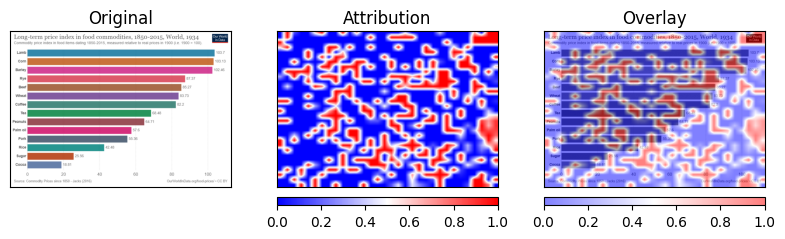

(<Figure size 800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Attribution'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

In [73]:
from captum.attr import visualization
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
                'red_blue',
                [
                    (0.0, '#0000ff'),  # blue   (low values)
                    (0.5, '#ffffff'),  # white  (mid)
                    (1.0, '#ff0000'),  # red    (high values)
                ],
                N=256,
            )


# Plot image attribution
img_resized_np = np.asarray(img).astype(np.float32) / 255.


h, w, _ = img_resized_np.shape
# img_map = cv2.resize(img_attribution, (w, h))

visualization.visualize_image_attr_multiple(
    #heatmap,
    np.expand_dims(heatmap, 2),
    img_resized_np,
    methods=["original_image", "heat_map", "blended_heat_map"],
    signs=["all", "positive", "positive"],
    show_colorbar=True,
    titles=["Original", "Attribution", "Overlay"],
    cmap=cmap,
)

### TAM

In [ ]:
import os
import time
import json
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader

from src.datasets import POPEGroundingDataset
from src.metrics.faithfulness import (eval_multimodal_synergy_batch, eval_image_perturbation_batch, eval_token_perturbation_batch)
from src.metrics.shap_sii import eval_sii_auc_with_class
from src.models.qwen_vl import QwenVL_Wrapper
from src.explainers import TAMExplainer

def compute_and_store_sii_faith(output_file="repope_evaluation_results.jsonl", max_samples=None):
    # ---------------------------------------------------------
    # 1. Initialization & Setup
    # ---------------------------------------------------------
    model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
    gpu_node = 1
    model, processor = load_qwen_model(model_id, attn_implementation=None, gpu_node=gpu_node)
    model.eval()

    model_wrapper = QwenVL_Wrapper(model, processor)
    explainer = TAMExplainer(model_wrapper)

    # Special Tokens
    tok = model_wrapper.processor.tokenizer
    special_token_ids = [
        tok.convert_tokens_to_ids("<|image_pad|>"),
        tok.convert_tokens_to_ids("<|vision_start|>"),
        tok.convert_tokens_to_ids("<|vision_end|>"),
        tok.convert_tokens_to_ids("<|im_start|>"),
        tok.convert_tokens_to_ids("<|im_end|>")
    ]
    pad_token_id = tok.pad_token_id if tok.pad_token_id is not None else 0

    # Dataset Setup
    data_path = "../datasets/repope"
    dataset = POPEGroundingDataset(
        data_path=data_path,
        pope_json_path=os.path.join(data_path, "repope_annotations"),
        pope_type="random",
        coco_split="val2014"
    )

    def collate_fn_custom(batch):
        return batch[0] # Assumes batch_size=1

    dl = DataLoader(dataset, collate_fn=collate_fn_custom)

    # Metric Hyperparameters
    pert_steps = [.05, .1, .2, .3, .4, .5, .6, .7, .8, .9]
    batch_size = 16
    shapiq_budget = 200
    n_background_groups = 10
    filter_keywords = False
    device = model.device
    
    print(f"Starting evaluation. Results will be saved to {output_file}")
    
    # ---------------------------------------------------------
    # 2. The Evaluation Loop
    # ---------------------------------------------------------
    for idx, sample in enumerate(tqdm(dl, desc="Evaluating Samples")):
        if max_samples is not None and idx >= max_samples:
            break
            
        img = sample["image"]
        question = sample["question"]
        text = "Answer strictly this question with yes or no: " + question
        label = sample["label"]
        image_id = sample.get("image_id", f"unknown_{idx}")

        # --- Forward Pass & Explainer ---
        inputs = model_wrapper.get_inputs(img, text)
        pred_results = model_wrapper.predict(inputs, return_logits=True)

        text_attrs, img_attrs = explainer.get_raw_attributions(
            img, text=text, target_indices=[], pred_results=pred_results
        )
        
        pixel_attribution = img_attrs[0:1]
        token_attribution = text_attrs[0:1]
        
        target_ids = pred_results["new_ids"].unsqueeze(0)
        target_positions = [torch.arange(target_ids.shape[1], device=device)]

        # Dictionary to store this sample's results
        sample_results = {
            "image_id": image_id,
            "question": question,
            "label": label,
        }

        # --- METRIC 1: SHAP SII ---
        start_time = time.perf_counter()
        shap_sii_res = eval_sii_auc_with_class(
            model=model_wrapper, inputs=inputs, target_ids=target_ids,
            token_attribution=token_attribution, pixel_attribution=pixel_attribution,
            perturbation_steps=pert_steps, pad_token_id=pad_token_id,
            special_token_ids=special_token_ids, target_positions=target_positions,
            blur_baseline=None, mask_value=0.0,
            n_background_groups=n_background_groups, shapiq_budget=shapiq_budget, batch_size=batch_size
        )
        sample_results["time_sii"] = time.perf_counter() - start_time
        sample_results["sii_auc"] = float(shap_sii_res["sii_auc"])

        # --- METRIC 2: Multimodal Synergy (Fast SRG) ---
        start_time = time.perf_counter()
        syn_res = eval_multimodal_synergy_batch(
            model=model_wrapper, inputs=inputs, target_ids=target_ids,
            token_attribution=token_attribution, pixel_attribution=pixel_attribution,
            perturbation_steps=pert_steps, pad_token_id=pad_token_id,
            special_token_ids=special_token_ids, blur_baseline=None, mask_value=0.0,
            filter_keywords=filter_keywords
        )
        sample_results["time_syn_srg"] = time.perf_counter() - start_time
        # Extract all AUC floats dynamically
        for key, val in syn_res.items():
            if "auc" in key:
                sample_results[f"syn_{key}"] = float(val.item())

        # --- METRIC 3: Image Perturbation ---
        start_time = time.perf_counter()
        img_res = eval_image_perturbation_batch(
            model=model_wrapper, inputs=inputs, target_ids=target_ids,
            pixel_attribution=pixel_attribution, perturbation_steps=pert_steps,
            blur_baseline=None, mask_value=0.0, filter_keywords=filter_keywords
        )
        sample_results["time_img_pert"] = time.perf_counter() - start_time
        for key, val in img_res.items():
            if "auc" in key:
                sample_results[f"img_{key}"] = float(val.item())

        # --- METRIC 4: Token Perturbation ---
        start_time = time.perf_counter()
        tok_res = eval_token_perturbation_batch(
            model=model_wrapper, inputs=inputs, target_ids=target_ids,
            token_attribution=token_attribution, perturbation_steps=pert_steps,
            pad_token_id=pad_token_id, special_token_ids=special_token_ids,
            filter_keywords=filter_keywords
        )
        sample_results["time_tok_pert"] = time.perf_counter() - start_time
        for key, val in tok_res.items():
            if "auc" in key:
                sample_results[f"tok_{key}"] = float(val.item())

        # ---------------------------------------------------------
        # 3. Save to Disk Immediately (JSON Lines format)
        # ---------------------------------------------------------
        with open(output_file, "a") as f:
            f.write(json.dumps(sample_results) + "\n")

    print("Evaluation Complete!")



In [16]:
import json
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_xai_results(results_file="repope_evaluation_results.jsonl"):
    print(f"Loading results from {results_file}...\n")
    
    # --- 1. Load the JSONL Data ---
    data = []
    with open(results_file, 'r') as f:
        for line in f:
            data.append(json.loads(line.strip()))
            
    df = pd.DataFrame(data)
    
    # --- 2. Map the Exact Column Names ---
    syn_ins_col = 'syn_ins_norm_syn_auc'
    syn_del_col = 'syn_del_norm_syn_auc'
    
    img_ins_col = 'img_norm_auc_ins'
    img_del_col = 'img_norm_auc_del'
    
    tok_ins_col = 'tok_norm_auc_ins'
    tok_del_col = 'tok_norm_auc_del'

    # Verify they exist to prevent silent failures
    required_cols = [syn_ins_col, syn_del_col, img_ins_col, img_del_col, tok_ins_col, tok_del_col, 'sii_auc']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}. Check if the script completed successfully.")

    # --- 3. Calculate all SRG Metrics ---
    # SRG = AUC(Insertion) - AUC(Deletion)
    df['multi_srg'] = df[syn_ins_col] - df[syn_del_col]
    df['img_srg']   = df[img_ins_col] - df[img_del_col]
    df['tok_srg']   = df[tok_ins_col] - df[tok_del_col]
    
    # --- 4. Compute Correlations (Multimodal Only) ---
    clean_df = df[['multi_srg', 'img_srg', 'tok_srg', 'sii_auc', 'time_sii', 'time_syn_srg']].dropna()
    
    pearson_r, p_val_p = stats.pearsonr(clean_df['multi_srg'], clean_df['sii_auc'])
    spearman_rho, p_val_s = stats.spearmanr(clean_df['multi_srg'], clean_df['sii_auc'])

    # --- 5. Print the Report ---
    print("==================================================")
    print("          XAI METRIC VALIDATION REPORT            ")
    print("==================================================")
    print(f"Total Samples Analyzed : {len(clean_df)}")
    
    print("\n--- SRG Statistics (Mean ± Std) ---")
    print(f"Multimodal SRG : {clean_df['multi_srg'].mean():.4f} ± {clean_df['multi_srg'].std():.4f}")
    print(f"Image SRG      : {clean_df['img_srg'].mean():.4f} ± {clean_df['img_srg'].std():.4f}")
    print(f"Token SRG      : {clean_df['tok_srg'].mean():.4f} ± {clean_df['tok_srg'].std():.4f}")
    
    print("\n--- Correlation with Exact SII (Multimodal) ---")
    print(f"Pearson r      : {pearson_r:.4f}  (p-value: {p_val_p:.2e})")
    print(f"Spearman rho   : {spearman_rho:.4f}  (p-value: {p_val_s:.2e})")
    print("==================================================")

    # --- 6. Generate Publication-Ready Plots ---
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    # PLOT 1: Scatter Plot (SRG vs SII)
    plt.figure(figsize=(8, 6))
    ax1 = sns.regplot(
        x='multi_srg', y='sii_auc', data=clean_df, 
        scatter_kws={'alpha': 0.6, 'color': '#2C3E50'}, 
        line_kws={'color': '#E74C3C', 'linewidth': 2}
    )
    plt.title('Validation of Fast SRG against Shapley Interaction Index', fontsize=14, weight='bold')
    plt.xlabel('Proposed Metric: Multimodal SRG ($AUC_{ins} - AUC_{del}$)', fontsize=12)
    plt.ylabel('Ground Truth: Exact SII AUC', fontsize=12)
    
    textstr = f"Spearman $\\rho$ = {spearman_rho:.3f}\nPearson $r$ = {pearson_r:.3f}"
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.savefig('srg_vs_sii_correlation.png', dpi=300, bbox_inches='tight')
    plt.close()

    # PLOT 2: Distribution Comparison (Image vs Token vs Multimodal)
    plt.figure(figsize=(9, 6))
    
    melted_df = clean_df[['img_srg', 'tok_srg', 'multi_srg']].melt(
        var_name='Modality', value_name='SRG Value'
    )
    melted_df['Modality'] = melted_df['Modality'].map({
        'img_srg': 'Image SRG\n(Vision Only)', 
        'tok_srg': 'Token SRG\n(Text Only)', 
        'multi_srg': 'Multimodal SRG\n(Synergy)'
    })
    
    sns.violinplot(
        x='Modality', y='SRG Value', data=melted_df, 
        inner='quartile', palette=['#3498DB', '#2ECC71', '#9B59B6'], alpha=0.6,
        hue='Modality', legend=False
    )
    sns.stripplot(
        x='Modality', y='SRG Value', data=melted_df, 
        color='black', alpha=0.4, jitter=True, size=4
    )
    
    plt.title('Comparison of SRG Values Across Modalities', fontsize=14, weight='bold')
    plt.ylabel('SRG Score ($AUC_{ins} - AUC_{del}$)', fontsize=12)
    plt.xlabel('')
    
    plt.tight_layout()
    plt.savefig('srg_modality_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()

    print("\nSaved plots as 'srg_vs_sii_correlation.png' and 'srg_modality_comparison.png'")



In [4]:
output_file="repope_eval_res.json"
max_samples = 2

compute_and_store_sii_faith(output_file=output_file,
                            max_samples=max_samples)

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=2.16s)
creating index...
index created!
Scanning 3 POPE json files...
Starting evaluation. Results will be saved to repope_eval_res.json


Evaluating Samples:   0%|          | 0/2774 [00:00<?, ?it/s]/tmp/ipykernel_2269010/1427387943.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sample_results[f"syn_{key}"] = float(val)
/tmp/ipykernel_2269010/1427387943.py:133: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sample_results[f"img_{key}"] = float(val)
/tmp/ipykernel_2269010/1427387943.py:146: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sample_results[f"tok_{key}"] = float(val)
Evaluating Samples:

Evaluation Complete!


In [17]:
analyze_xai_results(results_file="repope_eval_res.json")

Loading results from repope_eval_res.json...

          XAI METRIC VALIDATION REPORT            
Total Samples Analyzed : 2

--- SRG Statistics (Mean ± Std) ---
Multimodal SRG : -0.3341 ± 0.0451
Image SRG      : 0.0100 ± 0.0230
Token SRG      : -0.1955 ± 0.0047

--- Correlation with Exact SII (Multimodal) ---
Pearson r      : 1.0000  (p-value: 1.00e+00)
Spearman rho   : 1.0000  (p-value: nan)

Saved plots as 'srg_vs_sii_correlation.png' and 'srg_modality_comparison.png'


In [3]:
# del model, processor
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
gpu_node = 1
model, processor = load_qwen_model(model_id, attn_implementation=None, gpu_node=gpu_node)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [32]:
from src.models.qwen_vl import QwenVL_Wrapper

model_wrapper = QwenVL_Wrapper(model, processor)


In [ ]:
import time

from torch.utils.data import DataLoader
from src.datasets import POPEGroundingDataset
from src.metrics.utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game

data_path = "../datasets/repope"
pope_json_path = os.path.join(data_path, "repope_annotations")
pope_type = "random"
coco_split = "val2014"

dataset = POPEGroundingDataset(data_path=data_path,
                               pope_json_path=pope_json_path,
                               pope_type=pope_type,
                               coco_split=coco_split)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

# category = dataset.id2name
# mapper = OntologyMapper(coco_categories=category, threshold=0.5)



loading annotations into memory...
Done (t=4.17s)
creating index...
index created!
Scanning 3 POPE json files...


In [58]:
for sample in dl:
    img = sample["image"]
    text = "Answer strictly this question with yes or no: " + sample["question"] #"Write a one sentence caption"
    label = sample["label"]
    # captions = sample["captions"]
    # masks = sample["category_masks"]

    break


In [59]:
text

'Answer strictly this question with yes or no: Is there a snowboard in the image?'

In [5]:
import time

from torch.utils.data import DataLoader
from src.datasets import COCOGroundingDataset
from src.metrics.utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)

category = dataset.id2name
# mapper = OntologyMapper(coco_categories=category, threshold=0.5)



loading annotations into memory...
Done (t=0.31s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [6]:
del mapper

In [60]:
inputs = model_wrapper.get_inputs(img, text)
_, h, w = inputs["image_grid_thw"][0].cpu().numpy().tolist()

pred_results = model_wrapper.predict(inputs,
                                    return_logits=True)



# tokens = pred_results["new_ids"].cpu().unsqueeze(0).numpy().tolist()
# words, tokens_id = ids_to_word_groups(tokens,
#                                         model_wrapper.processor)

# logits = pred_results["logits"]

In [62]:
pred_results["new_ids"]

tensor([  9693, 151645], device='cuda:1')

In [10]:
from typing import Dict, Any, List, Tuple, Optional

from PIL import Image
import numpy as np
import torch

from src.explainers import BaseExplainer
from src.models import BaseVLMWrapper
from src.explainers.tam_utils.tam import get_attributions, TAM
from src.explainers.utils import align_llm_visuals_to_pixels

class TAMExplainer(BaseExplainer):
    def __init__(self,
                 model_wrapper: BaseVLMWrapper):
        super().__init__(model_wrapper)

    def get_raw_attributions(self,
                            image,
                            text: str,
                            target_indices: Optional[int | List[int]],
                            **kwargs
                            ) -> Tuple[torch.Tensor, torch.Tensor]:
        

        inputs = self.wrapper.get_inputs(image, text)

        pred_results = kwargs.get("pred_results", None)
        if pred_results is None:
            pred_results = self.wrapper.predict(inputs,
                                                return_logits=True,
                                                )
        
        logits = pred_results["logits"]
        generated_ids = pred_results["full_ids"].cpu()
        # new_ids = pred_results["new_ids"]
        # pred_text = pred_results["text"]

        tam_config = self.wrapper.get_tam_config(inputs)
        
        vis_inputs = np.array(image.convert("RGB"))

        #target_token = new_ids[target_indices].cpu().numpy().tolist()        

        # Get attributions
        img_scores_list = []
        text_attributions = []
        img_attributions = []
        for i in range(len(logits)):
            # result = get_attributions(
            #             generated_ids.cpu().tolist(),        
            #             tam_config["vision_shape"],
            #             logits,
            #             tam_config["special_ids"],
            #             vis_inputs,
            #             self.wrapper.processor,
            #             target_token_idx=i,
            #             img_scores_list=img_scores_list,
            #             eval_only=True)

            result = TAM(
                        tokens=generated_ids.cpu().tolist(),        
                        vision_shape=tam_config["vision_shape"],
                        logit_list=logits,
                        special_ids=tam_config["special_ids"],
                        vision_input=vis_inputs,
                        processor=self.wrapper.processor,
                        save_fn="",
                        target_token=i,
                        img_scores_list=img_scores_list,
                        eval_only=True,
                        return_components=True,
                        )
        
            img_attribution = result["img_map_norm"]
            text_attribution = result["txt_scores_raw"]
            #print(text_attribution.shape)
        
            text_attributions.append(text_attribution)
            img_attributions.append(img_attribution)
        #img_attributions = img_attributions[-1]
        
        img_attributions = [torch.from_numpy(_).float() for _ in img_attributions]
        text_attributions = [torch.from_numpy(_).float() for _ in text_attributions]
        img_attributions = torch.stack(img_attributions)
        img_attributions = img_attributions.reshape(img_attributions.shape[0], -1)
        text_attributions = torch.stack(text_attributions)

        img_attributions = align_llm_visuals_to_pixels(img_attributions, inputs)

        return text_attributions, img_attributions


In [63]:
from src.explainers import RandomExplainer, CaptumExplainer, LXTExplainer, RolloutExplainer, LLaVACAMExplainer, TAMExplainer

explainer = TAMExplainer(model_wrapper,)

text_attrs, img_attrs = explainer.get_raw_attributions(img,
                                            text=text,
                                            target_indices=[],
                                            pred_results=pred_results)

In [77]:
img_attrs[0:1].shape

torch.Size([1, 1380])

In [73]:
img_pad_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
img_start_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
img_end_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
# Also maybe the start of text token if you want to preserve it
im_start_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|im_start|>")
im_end_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|im_end|>")

special_token_ids = [img_start_id, img_pad_id, img_end_id, im_start_id, im_end_id]
# special_token_ids = [img_pad_id]

In [74]:
special_token_ids

[151652, 151655, 151653, 151644, 151645]

In [51]:
import torch

def get_top_k_mask(relevance_scores: torch.Tensor,
                   k_percentage: float,
                   num_elements: Optional[int] = None) -> torch.Tensor:
    """
    Converts continuous relevance scores into a boolean mask of the top-k percentage.
    
    Args:
        relevance_scores: Tensor of any shape containing explainer scores.
        k_percentage: Float between 0.0 and 1.0 indicating the fraction to keep.
        
    Returns:
        Boolean tensor of the exact same shape, where True = Top K.
    """
    # 1. Handle mathematical edge cases immediately
    if k_percentage <= 0.0:
        return torch.zeros_like(relevance_scores, dtype=torch.bool)
    if k_percentage >= 1.0:
        return torch.ones_like(relevance_scores, dtype=torch.bool)

    # 2. Flatten the scores to 1D
    flat_scores = relevance_scores.view(-1)
    if num_elements is None:
        num_elements = flat_scores.numel()
    
    # 3. Calculate exactly how many items to keep
    # Using max(1, ...) ensures we keep at least 1 feature if k > 0
    num_keep = max(1, int(num_elements * k_percentage))
    
    # 4. Get the indices of the top values
    # We use torch.topk for speed (it doesn't sort the whole array, just finds the top)
    _, top_indices = torch.topk(flat_scores, num_keep, largest=True, sorted=False)
    
    # 5. Create the mask
    flat_mask = torch.zeros_like(flat_scores, dtype=torch.bool)
    flat_mask[top_indices] = True
    
    # 6. Restore to the original shape (e.g., 14x14 patches or Seq_Len text)
    return flat_mask.view_as(relevance_scores)
    

def group_background_randomly(top_k_img, top_k_txt, n_background_groups):
    """
    Takes the Top-K boolean masks, identifies the background (False values), 
    and randomly partitions that background into `n_background_groups` chunks.
    
    Args:
        top_k_img (torch.Tensor): Boolean tensor for image (True = Top-K).
        top_k_txt (torch.Tensor): Boolean tensor for text (True = Top-K).
        n_background_groups (int): Number of macro-players for the background.
        
    Returns:
        bg_img_groups (List[torch.Tensor]): List of boolean masks for image background chunks.
        bg_txt_groups (List[torch.Tensor]): List of boolean masks for text background chunks.
    """
    # 1. Identify Background (Invert the Top-K masks)
    bg_img_mask = ~top_k_img
    bg_txt_mask = ~top_k_txt
    
    # 2. Flatten to 1D for easy shuffling and indexing
    bg_img_flat = bg_img_mask.view(-1)
    bg_txt_flat = bg_txt_mask.view(-1)
    
    # 3. Get the actual indices of the background elements
    # .nonzero() returns the coordinates of True values, .squeeze() flattens it
    img_indices = torch.nonzero(bg_img_flat).squeeze(-1)
    txt_indices = torch.nonzero(bg_txt_flat).squeeze(-1)
    
    # 4. Shuffle the indices randomly
    img_indices = img_indices[torch.randperm(img_indices.size(0))]
    txt_indices = txt_indices[torch.randperm(txt_indices.size(0))]
    
    # 5. Split the shuffled indices into roughly equal chunks
    img_chunks = torch.tensor_split(img_indices, n_background_groups)
    txt_chunks = torch.tensor_split(txt_indices, n_background_groups)
    
    bg_img_groups = []
    bg_txt_groups = []
    
    # 6. Reconstruct the 2D/3D boolean masks for each group
    for i in range(n_background_groups):
        # Create blank 1D masks of all Falses
        img_group_flat = torch.zeros_like(bg_img_flat, dtype=torch.bool)
        txt_group_flat = torch.zeros_like(bg_txt_flat, dtype=torch.bool)
        
        # Set the randomly selected indices for this chunk to True
        if len(img_chunks[i]) > 0:
            img_group_flat[img_chunks[i]] = True
        if len(txt_chunks[i]) > 0:
            txt_group_flat[txt_chunks[i]] = True
            
        # Reshape back to the original shapes (e.g., 14x14 for ViT patches)
        bg_img_groups.append(img_group_flat.view_as(top_k_img))
        bg_txt_groups.append(txt_group_flat.view_as(top_k_txt))
        
    return bg_img_groups, bg_txt_groups



In [ ]:
# from src.metrics.faithfulness import pred_probs, score_output
from src.models import BaseVLMWrapper
from typing import Dict, Any, List, Optional
import torch.nn.functional as F

def score_output(model: BaseVLMWrapper,
                inputs: Dict[str, Any],
                input_ids: torch.Tensor,
                pixel_values: torch.Tensor,
                output_ids: torch.Tensor,
                positions: List[torch.Tensor],
                ) -> torch.Tensor:
    generated_ids = torch.cat((input_ids, output_ids), dim=1)

    probs_pred = pred_probs(model,
                            inputs,
                            generated_ids,
                            pixel_values,
                            output_ids,
                            )
    
    # FIX: Handle variable length positions manually per batch item
    # batch_scores = []
    # for b in range(probs_pred.shape[0]):
    #     # Select the specific tokens for this batch item
    #     p = positions[b].to(probs_pred.device)
    #     if len(p) == 0:
    #         batch_scores.append(torch.tensor(0.0, device=probs_pred.device))
    #     else:
    #         # probs_pred[b] is (Seq_Len,)
    #         # We gather the specific keyword probabilities
    #         s = probs_pred[b, p].sum() / len(p)
    #         batch_scores.append(s)
            
    # scores = torch.stack(batch_scores).cpu().float()

    # Fix
    batch_size = probs_pred.shape[0]
    device = probs_pred.device
    
    # FIX: Vectorized position scoring
    # Pre-allocate the result tensor on the GPU
    batch_scores = torch.zeros(batch_size, dtype=torch.float32, device=device)
    
    for b in range(batch_size):
        p = positions[b].to(device)
        if len(p) > 0:
            # Gather and mean directly on the GPU, much faster than appending to a list
            batch_scores[b] = probs_pred[b, p].sum()
            
    scores = batch_scores.cpu()

    return scores

def pred_probs(model: BaseVLMWrapper,
               inputs: Dict[str, Any],
               new_input_ids: torch.Tensor,
               pixel_values: Optional[torch.Tensor],
               output_ids: torch.Tensor,
               ) -> torch.Tensor:

    device = model.device
    
    attention_mask = torch.ones_like(new_input_ids).to(device)
    # pad_token_id = model.processor.tokenizer.pad_token_id if model.processor.tokenizer.pad_token_id is not None else 0
    # attention_mask = (new_input_ids != pad_token_id).long().to(device)

    other_kwargs = {k: v \
                    for k, v in inputs.items() \
                    if k not in ['input_ids','pixel_values', 'attention_mask']}

    with torch.no_grad():
        outputs = model.model(
            input_ids=new_input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            #return_probs=False,
            **other_kwargs,
        ) # [batch_size, seq_len, vocab_size]
    all_logits = outputs.logits

    returned_logits = all_logits[:, -output_ids.shape[-1]-1:-1, :] # The reason for the minus 1 is that the generated content is in the previous position
    # returned_logits = F.softmax(returned_logits, dim=-1) # (batch_size, selected_tokens, vocab_size)
    returned_logits = F.log_softmax(returned_logits, dim=-1) # (batch_size, selected_tokens, vocab_size)
    

    returned_logits = returned_logits.gather(dim=2, index=output_ids.unsqueeze(-1)).squeeze(-1) # (batch_size, selected_tokens)
    return returned_logits





In [ ]:
import numpy as np
import torch
from shapiq import Game

from src.metrics.faithfulness import score_output


class MacroSynergyGame(Game):
    """
    A shapiq Game interface that computes model probabilities for 
    specific coalitions of Top-K features and Background chunks.
    """
    def __init__(self, model, inputs, target_ids, target_positions,
                 feat, feat_baseline, input_ids, baseline_input_ids,
                 top_img_idx, top_token_idx, bg_img_groups, bg_txt_groups,
                 num_img_feat, ndim, origin_shape, batch_size=32):
        
        # Player 0: Top-K Image, Player 1: Top-K Text, Players 2..N: Background
        self.n_background = len(bg_img_groups)
        self.n_players = 2 + self.n_background
        
        # Initialize shapiq.Game
        super().__init__(n_players=self.n_players, normalize=False)
        
        self.model = model
        self.inputs = inputs
        self.target_ids = target_ids
        self.target_positions = target_positions
        
        # Storing the pre-flattened baselines and originals
        self.feat = feat
        self.feat_baseline = feat_baseline
        self.input_ids = input_ids
        self.baseline_input_ids = baseline_input_ids
        
        # Storing the player indices
        self.top_img_idx = top_img_idx
        self.top_token_idx = top_token_idx
        self.bg_img_groups = bg_img_groups
        self.bg_txt_groups = bg_txt_groups
        
        # Shape info
        self.num_img_feat = num_img_feat
        self.ndim = ndim
        self.origin_shape = origin_shape
        self.batch_size = batch_size

    def value_function_crossmodal(self, coalitions: np.ndarray) -> np.ndarray:
        n_coalitions = coalitions.shape[0]
        coalitions_outputs = np.zeros(n_coalitions)
        
        for start_idx in range(0, n_coalitions, self.batch_size):
            end_idx = min(start_idx + self.batch_size, n_coalitions)
            current_batch_size = end_idx - start_idx
            batch_coalitions = coalitions[start_idx:end_idx]
            
            batch_feats = self.feat_baseline.expand(current_batch_size, -1, -1).clone()
            batch_input_ids = self.baseline_input_ids.expand(current_batch_size, -1).clone()
            
            for i in range(current_batch_size):
                coalition = batch_coalitions[i]
                
                # --- A. Image Scatter (Player 0 + Image BG Players) ---
                active_img_idx_list = []
                if coalition[0] and self.top_img_idx.numel() > 0: 
                    active_img_idx_list.append(self.top_img_idx.squeeze(0)) # Player 0
                
                # Image BG Players start at index 2
                for j in range(self.n_bg_img):
                    if coalition[2 + j] and len(self.bg_img_groups[j]) > 0:
                        active_img_idx_list.append(self.bg_img_groups[j])
                
                if len(active_img_idx_list) > 0:
                    active_img_idx = torch.cat(active_img_idx_list).unsqueeze(0)
                    active_img_idx_exp = active_img_idx.unsqueeze(1).expand(1, self.num_img_feat, -1)
                    pixels_orig = self.feat.gather(dim=2, index=active_img_idx_exp)
                    batch_feats[i:i+1].scatter_(dim=2, index=active_img_idx_exp, src=pixels_orig)

                # --- B. Text Scatter (Player 1 + Text BG Players) ---
                active_txt_idx_list = []
                if coalition[1] and self.top_token_idx.numel() > 0:
                    active_txt_idx_list.append(self.top_token_idx.squeeze(0)) # Player 1
                
                # Text BG Players start AFTER the Image BG players
                text_bg_start_idx = 2 + self.n_bg_img
                for j in range(self.n_bg_txt):
                    if coalition[text_bg_start_idx + j] and len(self.bg_txt_groups[j]) > 0:
                        active_txt_idx_list.append(self.bg_txt_groups[j])
                        
                if len(active_txt_idx_list) > 0:
                    active_txt_idx = torch.cat(active_txt_idx_list).unsqueeze(0)
                    tokens_orig = self.input_ids.gather(dim=1, index=active_txt_idx)
                    batch_input_ids[i:i+1].scatter_(dim=1, index=active_txt_idx, src=tokens_orig)
            
            # --- C. Reshape and Qwen2-VL Fix ---
            if self.ndim == 4:
                _, C, H, W = self.origin_shape
                batch_pixels = batch_feats.reshape(current_batch_size, C, H, W)
                batch_inputs = self.inputs 
                
            elif self.ndim == 3:
                _, num_pixels, patch_dim = self.origin_shape
                
                # 1. Safely transpose the axes back
                batch_pixels = batch_feats.transpose(1, 2)
                # 2. Flatten for Qwen2-VL
                batch_pixels = batch_pixels.reshape(current_batch_size * num_pixels, patch_dim)
                
                # 3. Duplicate the image_grid_thw
                batch_inputs = {k: v for k, v in self.inputs.items()}
                if "image_grid_thw" in batch_inputs:
                    grid = batch_inputs["image_grid_thw"]
                    if grid.ndim == 1:
                        batch_inputs["image_grid_thw"] = grid.unsqueeze(0).repeat(current_batch_size, 1)
                    else:
                        batch_inputs["image_grid_thw"] = grid.repeat(current_batch_size, 1)
                
            batch_target_positions = [self.target_positions[0] for _ in range(current_batch_size)]
            batch_target_ids = self.target_ids.expand(current_batch_size, -1)
            
            probs = score_output(
                model=self.model,
                inputs=batch_inputs, 
                input_ids=batch_input_ids,
                pixel_values=batch_pixels,
                output_ids=batch_target_ids,
                positions=batch_target_positions
            ).numpy()
            
            coalitions_outputs[start_idx:end_idx] = probs
            
        return coalitions_outputs

    def value_function(self, coalitions: np.ndarray) -> np.ndarray:
        """
        Input: Coalitions as a boolean np.array of shape (n_coalitions, n_players).
        Output: Model outputs for the coalitions of shape (n_coalitions, ).
        """
        n_coalitions = coalitions.shape[0]
        coalitions_outputs = np.zeros(n_coalitions)
        
        # --- Clean Batching Logic (Inspired by the GitHub code) ---
        for start_idx in range(0, n_coalitions, self.batch_size):
            end_idx = min(start_idx + self.batch_size, n_coalitions)
            current_batch_size = end_idx - start_idx
            batch_coalitions = coalitions[start_idx:end_idx]
            
            # 1. Pre-allocate batched baselines
            batch_feats = self.feat_baseline.expand(current_batch_size, -1, -1).clone()
            batch_input_ids = self.baseline_input_ids.expand(current_batch_size, -1).clone()
            
            # 2. Build the inputs using your exact scatter_ logic
            for i in range(current_batch_size):
                coalition = batch_coalitions[i]
                
                # --- A. Image Scatter ---
                active_img_idx_list = []
                if coalition[0] and self.top_img_idx.numel() > 0: 
                    active_img_idx_list.append(self.top_img_idx.squeeze(0)) # Player 0
                for j in range(self.n_background):
                    if coalition[2 + j] and len(self.bg_img_groups[j]) > 0:
                        active_img_idx_list.append(self.bg_img_groups[j])
                
                if len(active_img_idx_list) > 0:
                    active_img_idx = torch.cat(active_img_idx_list).unsqueeze(0)
                    active_img_idx_exp = active_img_idx.unsqueeze(1).expand(1, self.num_img_feat, -1)
                    pixels_orig = self.feat.gather(dim=2, index=active_img_idx_exp)
                    batch_feats[i:i+1].scatter_(dim=2, index=active_img_idx_exp, src=pixels_orig)

                # --- B. Text Scatter ---
                active_txt_idx_list = []
                if coalition[1] and self.top_token_idx.numel() > 0:
                    active_txt_idx_list.append(self.top_token_idx.squeeze(0)) # Player 1
                for j in range(self.n_background):
                    if coalition[2 + j] and len(self.bg_txt_groups[j]) > 0:
                        active_txt_idx_list.append(self.bg_txt_groups[j])
                        
                if len(active_txt_idx_list) > 0:
                    active_txt_idx = torch.cat(active_txt_idx_list).unsqueeze(0)
                    tokens_orig = self.input_ids.gather(dim=1, index=active_txt_idx)
                    batch_input_ids[i:i+1].scatter_(dim=1, index=active_txt_idx, src=tokens_orig)
            
            # 3. Reshape batch_feats back to original image shape
            if self.ndim == 4:
                _, C, H, W = self.origin_shape
                batch_pixels = batch_feats.reshape(current_batch_size, C, H, W)

                batch_inputs = self.inputs # Standard models don't need grid trick

            elif self.ndim == 3:
                _, num_pixels, patch_dim = self.origin_shape
                batch_pixels = batch_feats.reshape(current_batch_size, num_pixels, patch_dim)

                # 2. Create a copy of the inputs dict so we don't permanently alter the original
                batch_inputs = {k: v for k, v in self.inputs.items()}

                # 3. Replicate the image_grid_thw to match the number of coalitions
                if "image_grid_thw" in batch_inputs:
                    grid = batch_inputs["image_grid_thw"]
                    # If grid is (1, 3), repeat it to (5, 3)
                    batch_inputs["image_grid_thw"] = grid.repeat(current_batch_size, 1)
                # --- QWEN2-VL SPECIFIC FIX END ---
                
            batch_target_positions = [self.target_positions[0] for _ in range(current_batch_size)]
            batch_target_ids = self.target_ids.expand(current_batch_size, -1)
            
            # 4. Score Output
            probs = score_output(
                model=self.model,
                inputs=batch_inputs, #self.inputs, 
                input_ids=batch_input_ids,
                pixel_values=batch_pixels,
                output_ids=batch_target_ids,
                positions=batch_target_positions
            ).numpy()
            
            coalitions_outputs[start_idx:end_idx] = probs
            
        return coalitions_outputs



In [81]:
import shapiq

def eval_sii_auc_with_class(
    model, inputs, target_ids, pixel_attribution, token_attribution,
    perturbation_steps, pad_token_id, special_token_ids, target_positions,
    blur_baseline=None, mask_value=0.0, n_background_groups=10, 
    shapiq_budget=300, batch_size=32
):
    device = model.device
    
    # --- 1. One-time Setup (Flattening and Baselines) ---
    pixel_values = inputs["pixel_values"].unsqueeze(0).to(device)
    input_ids = inputs["input_ids"].to(device)
    
    ndim = pixel_values.ndim
    origin_shape = pixel_values.shape
    if ndim == 4:
        _, C, H, W = origin_shape
        num_pixels = H * W
        feat = pixel_values.reshape(1, C, num_pixels) 
    elif ndim == 3:
        _, num_pixels, patch_dim = origin_shape
        feat = pixel_values.reshape(1, patch_dim, num_pixels)
    else:
        raise ValueError("pixel_values shape must be (B, C, H, W) or (B, num_patches, patch_dim).")
    
    num_img_feat = feat.shape[1]
    
    if blur_baseline is None:
        blur_baseline = torch.full_like(pixel_values, mask_value).to(device)
    feat_baseline = blur_baseline.clone().reshape(feat.shape)
    sal_flat_img = pixel_attribution.reshape(1, -1)
    
    valid_mask = torch.ones_like(input_ids, dtype=torch.bool)
    if special_token_ids is not None:
        for skip_id in special_token_ids:
            valid_mask &= (input_ids != skip_id)
            
    num_valid_tokens = valid_mask.sum().item()
    masked_attribution = token_attribution.clone()
    masked_attribution[~valid_mask] = -float('inf')

    baseline_input_ids = input_ids.clone()
    baseline_input_ids[valid_mask] = pad_token_id

    sii_curve = []

    # --- 2. Loop over K Steps ---
    for step in perturbation_steps:
        k_img = max(0, min(int(round(step * num_pixels)), num_pixels))
        k_txt = max(0, min(int(round(step * num_valid_tokens)), num_valid_tokens))
        
        top_img_idx = torch.empty((1, 0), dtype=torch.long, device=device)
        top_token_idx = torch.empty((1, 0), dtype=torch.long, device=device)
        
        if k_img > 0: _, top_img_idx = torch.topk(sal_flat_img, k_img, dim=-1)
        if k_txt > 0: _, top_token_idx = torch.topk(masked_attribution, k_txt, dim=-1)

        top_img_idx = top_img_idx.to(device)
        top_token_idx = top_token_idx.to(device)
           
            
        # Background chunking
        is_bg_img = torch.ones((1, num_pixels), dtype=torch.bool, device=device)
        is_bg_img.scatter_(1, top_img_idx, False)
        bg_img_indices = is_bg_img.nonzero(as_tuple=True)[1][torch.randperm(num_pixels - k_img)]
        
        is_bg_txt = valid_mask.clone()
        is_bg_txt.scatter_(1, top_token_idx, False)
        bg_txt_indices = is_bg_txt.nonzero(as_tuple=True)[1][torch.randperm(num_valid_tokens - k_txt)]
        
        bg_img_groups = torch.tensor_split(bg_img_indices, n_background_groups)
        bg_txt_groups = torch.tensor_split(bg_txt_indices, n_background_groups)

        # --- 3. Instantiate Game and Run Shapiq ---
        game = MacroSynergyGame(
            model=model, inputs=inputs, target_ids=target_ids, 
            target_positions=target_positions, feat=feat, 
            feat_baseline=feat_baseline, input_ids=input_ids, 
            baseline_input_ids=baseline_input_ids, top_img_idx=top_img_idx, 
            top_token_idx=top_token_idx, bg_img_groups=bg_img_groups, 
            bg_txt_groups=bg_txt_groups, num_img_feat=num_img_feat, 
            ndim=ndim, origin_shape=origin_shape, batch_size=batch_size
        )
        
        approximator = shapiq.approximator.SHAPIQ(n=game.n_players, max_order=2, index="SII")
        interaction_values = approximator.approximate(budget=shapiq_budget, game=game)
        
        sii_curve.append(interaction_values[(0, 1)])
        
    return {
        "sii_curve": sii_curve,
        "sii_auc": np.trapezoid(sii_curve, x=perturbation_steps)
    }



In [83]:
device = model.device
blur_baseline = None
mask_value = 0.0
pixel_attribution = img_attrs.mean(dim=0, keepdim=True)
token_attribution = text_attrs.mean(dim=0, keepdim=True)
pad_token_id = model_wrapper.processor.tokenizer.pad_token_id

pert_steps = [.05, .1, .2, .3, .4, .5, .6, .7, .8, .9]

target_ids = pred_results["new_ids"].unsqueeze(0)
seq_len = target_ids.shape[1]
target_positions = [torch.arange(seq_len, device=device)]

batch_size = 16
shapiq_budget = 200
n_background_groups = 10

In [84]:
res = eval_sii_auc_with_class(model=model_wrapper,
                        inputs=inputs,
                        target_ids=target_ids,
                        token_attribution=token_attribution,
                        pixel_attribution=pixel_attribution,
                        perturbation_steps=pert_steps,
                        pad_token_id=pad_token_id,
                        special_token_ids=special_token_ids,
                        target_positions=target_positions,
                        blur_baseline=blur_baseline,
                        mask_value=mask_value,
                        n_background_groups=n_background_groups,
                        shapiq_budget=shapiq_budget,
                        batch_size=batch_size,
                        )

In [85]:
res

{'sii_curve': [-0.8008776969516788,
  1.8440527244958198,
  0.09073169089381694,
  -1.4355573867453826,
  1.52611112177928,
  3.9503656366626507,
  -2.0632184853061895,
  2.9483731518066034,
  3.615692166974882,
  -0.5273174593699772],
 'sii_auc': np.float64(0.9551659285514619)}

In [86]:
from src.metrics.faithfulness import (eval_multimodal_synergy_batch, eval_image_perturbation_batch, eval_token_perturbation_batch)

In [93]:
a = "auc_aie"
if "auc" in a:
    print(a)

auc_aie


In [87]:
res_faith = eval_multimodal_synergy_batch(model=model_wrapper,
                                        inputs=inputs,
                                        target_ids=target_ids,
                                        token_attribution=token_attribution,
                                        pixel_attribution=pixel_attribution,
                                        perturbation_steps=pert_steps,
                                        pad_token_id=pad_token_id,
                                        special_token_ids=special_token_ids,
                                        blur_baseline=blur_baseline,
                                        mask_value=mask_value,
                                        filter_keywords=False,
                                         )

In [88]:
res_faith

{'del_synergy_curve': array([[3.1914062],
        [2.9882812],
        [4.2226562],
        [3.3007812],
        [2.0351562],
        [4.2695312],
        [5.1445312],
        [2.5507812],
        [5.6445312],
        [9.238281 ]], dtype=float32),
 'ins_synergy_curve': array([[-0.9375 ],
        [-0.75   ],
        [-3.6875 ],
        [-0.75   ],
        [-0.0625 ],
        [-2.625  ],
        [-1.6875 ],
        [ 1.     ],
        [ 0.46875],
        [ 3.5    ]], dtype=float32),
 'ins_norm_synergy_curve': array([[-0.06228913],
        [-0.0498313 ],
        [-0.2450039 ],
        [-0.0498313 ],
        [-0.00415261],
        [-0.17440955],
        [-0.11212043],
        [ 0.06644174],
        [ 0.03114456],
        [ 0.23254606]], dtype=float32),
 'del_norm_synergy_curve': array([[0.21204257],
        [0.19854659],
        [0.2805606 ],
        [0.21930963],
        [0.13521934],
        [0.28367507],
        [0.3418116 ],
        [0.16947836],
        [0.37503242],
        [0.613807

In [ ]:
import time
from src.metrics.utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game

category = dataset.id2name
mapper = OntologyMapper(coco_categories=category, threshold=0.5)

for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    _, h, w = inputs["image_grid_thw"][0].cpu().numpy().tolist()

    pred_results = model_wrapper.predict(inputs,
                                     return_logits=True)
    


    tokens = pred_results["new_ids"].cpu().unsqueeze(0).numpy().tolist()
    words, tokens_id = ids_to_word_groups(tokens,
                                          model_wrapper.processor)
    
    logits = pred_results["logits"]

    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()
    text_attrs, img_attrs = explainer.get_raw_attributions(img,
                                            question=q,
                                            target_indices=[],
                                            **pred_results)
    torch.cuda.synchronize()
    exec_time = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) # Convert to MB

    print(exec_time, peak_vram)
        

    pg_scores = []
    energy_pg_scores = []
    for i, word in enumerate(words):
        cat_id = mapper.map_word(word)
        if cat_id is None:
            continue

        cat_name = category[cat_id]

        if cat_name not in masks:
            print(f"Word: '{word:10}' | Mapped: '{cat_name:10}' | Result: Hallucinated (Not in image)")
            continue

        # Resize heatmap to match ground truth mask dimensions
        gt_mask = masks[cat_name].numpy()
        h_gt, w_gt = gt_mask.shape

        # Pool the image attributions for this specific word
        img_attr = pool_heatmaps(img_attrs, tokens_id[i], method='max')
        
        heatmap_raw = img_attr.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
        heatmap_resized = torch.nn.functional.interpolate(
            heatmap_raw, size=(h_gt, w_gt), mode='bilinear', align_corners=False
        ).squeeze().cpu().numpy()
        pg_score = point_game(gt_mask, heatmap_resized)
        energy_score = energy_point_game(gt_mask, heatmap_resized)

        pg_scores.append(pg_score)
        energy_pg_scores.append(energy_score)

        print(f"Word: '{word:10}' | Mapped: '{cat_name:10}'")

        
    break




1.6398346424102783 23336.5380859375
Word: 'woman     ' | Mapped: 'person    '
Word: 'kitchen   ' | Mapped: 'oven      ' | Result: Hallucinated (Not in image)
Word: 'dining    ' | Mapped: 'dining table'
Word: 'table     ' | Mapped: 'dining table'
Word: 'chairs    ' | Mapped: 'chair     '
Word: 'TV        ' | Mapped: 'tv        '


tensor([5562], device='cuda:2')


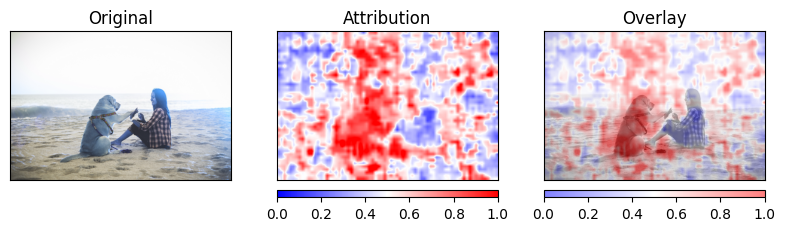

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
dog,dog (5562.00),5562,4.04,What animal is in the picture ?


In [36]:
true_text = "dog"
target_token_idx = 7
target_token = generated_ids_trimmed[0][target_token_idx].item()
pred_token = target_token
attributions = get_attributions_plot(model_wrapper,
                                    inputs,
                                    true_text,
                                    target_token_idx=target_token_idx,
                                    target_token=target_token,
                                    pred_token=pred_token,
                                    plot=True)

tensor([5562], device='cuda:0')


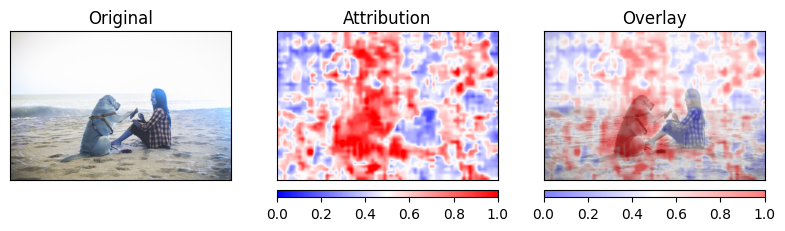

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
yellow,dog (6802.00),6802,4.21,{'What is the color of the dog ?'}


In [ ]:
target_token_idx = 8
target_token = generated_ids_trimmed[0][target_token_idx].item()
pred_token = target_token
attributions = get_attributions_plot(model_wrapper,
                                    inputs,
                                    true_text,
                                    target_token_idx=target_token_idx,
                                    target_token=target_token,
                                    pred_token=pred_token,
                                    plot=True)

In [37]:
torch.cuda.empty_cache()

### Captum

In [44]:
from typing import Literal, Tuple, List, Optional

from PIL import Image
import torch
from captum.attr import (
    IntegratedGradients, InputXGradient,
    TokenReferenceBase,
)

from src.explainers import BaseExplainer
from src.models import BaseVLMWrapper

class CaptumExplainer(BaseExplainer):
    def __init__(self,
                model_wrapper: BaseVLMWrapper,
                xai_name,
                ):
        super().__init__(model_wrapper)
        self.xai_name = xai_name
        self.explainer = self._get_explainer(self.xai_name)

    def _get_explainer(self,
                       xai_name: Literal["inputxgradient", "integrated"]):
        if xai_name == "inputxgradient":
            xai_method = InputXGradient(self.wrapper.get_captum_forward)
        elif xai_name == "integrated":
            xai_method = IntegratedGradients(self.wrapper.get_captum_forward)
        else:
            raise ValueError(f"Unknow method name {xai_name}")
        return xai_method
    
    def get_raw_attributions(self,
                             image,
                             question,
                             target_indices: Optional[int | List[int]],
                             **kwargs,
                            ) -> Tuple[torch.Tensor, torch.Tensor]:
        inputs = self.wrapper.get_inputs(image, question)

        input_ids = inputs["input_ids"]
        pixel_values = inputs["pixel_values"]  #.unsqueeze(0)

        text_embeds = self.wrapper.embed_text(input_ids)

        captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
        kwargs_dict = {k: v for k, v in inputs.items() if k not in ['pixel_values']}
        captum_add_forward = (kwargs_dict)

        
        use_baselines = False
        if self.xai_name in ["integrated"]:
            use_baselines = True
    

        
        pred_results = kwargs.get("pred_results", None)
        if pred_results is None:
            pred_results = self.wrapper.predict(inputs=inputs,
                                            return_logits=False,
                                            **kwargs,
                                            )
        new_ids = pred_results["new_ids"]
        seq_len = len(new_ids)
        # target_token = new_ids[target_indices].cpu().numpy().tolist()

        token_attrs = []
        pixel_attrs = []
        for step_idx in range(seq_len):
            target_token = new_ids[step_idx].item()

            # --- DYNAMIC CONTEXT BUILDING ---
            if step_idx == 0:
                # Predicting the first token: context is just the prompt
                current_input_ids = input_ids 
            else:
                # Predicting token T: context is prompt + previously generated tokens
                step_ids = new_ids[:step_idx].unsqueeze(0) # Shape: (1, step_idx)
                current_input_ids = torch.cat([input_ids, step_ids], dim=1)
            
            # Embed the dynamically growing text sequence
            current_text_embeds = self.wrapper.embed_text(current_input_ids).requires_grad_()
            captum_forward = (current_text_embeds, pixel_values.requires_grad_())

            # Dynamically grow the attention mask if it exists
            step_kwargs = kwargs_dict.copy()
            step_kwargs["input_ids"] = current_input_ids
            if "attention_mask" in step_kwargs:
                # Add 1s for the newly appended tokens
                extra_mask = torch.ones((1, step_idx),
                                        dtype=step_kwargs["attention_mask"].dtype,
                                        device=self.device)
                step_kwargs["attention_mask"] = torch.cat([step_kwargs["attention_mask"],
                                                                extra_mask],
                                                           dim=1)
                
            
            baselines = None
            if use_baselines:
                token_reference = TokenReferenceBase(
                    reference_token_idx=self.wrapper.processor.tokenizer.pad_token_id)
                # generate reference for each sample
                reference_ids = token_reference.generate_reference(
                                        current_input_ids.shape[-1],
                                        device=self.device
                                        ).unsqueeze(0)
                reference_embeds = self.wrapper.embed_text(reference_ids)
                baselines = (reference_embeds, torch.zeros_like(pixel_values))

            # Get attributions
            if use_baselines:
                token_attr, pixel_attr = self.explainer.attribute(inputs=captum_forward,
                                                        baselines=baselines,
                                                        target=target_token,
                                                        additional_forward_args=step_kwargs,
                                                        n_steps=5,
                                                        internal_batch_size=1,
                                                        )
            else:
                token_attr, pixel_attr = self.explainer.attribute(inputs=captum_forward,
                                                    target=target_token,
                                                    additional_forward_args=step_kwargs,
                                                    )
        
            token_attr = token_attr.detach().cpu()
            pixel_attr = pixel_attr.detach().cpu()
            torch.cuda.empty_cache()

            if step_idx > 0 :
                token_attr = token_attr[:, :-step_idx, :] # Remove the attribution for answer tokens
            token_attrs.append(token_attr)
            pixel_attrs.append(pixel_attr)

        token_attrs = torch.cat(token_attrs, dim=0)
        pixel_attrs = torch.stack(pixel_attrs, dim=0)

        return token_attrs, pixel_attrs


In [11]:
import torch
from typing import Optional, List, Tuple
from abc import ABC, abstractmethod

from src.explainers import BaseExplainer
from src.models import BaseVLMWrapper


class RandomExplainer(BaseExplainer):
    """
    A baseline explainer that returns random attributions.
    Used to validate that faithfulness metrics correctly penalize random noise.
    """
    def __init__(self, model_wrapper: BaseVLMWrapper):
        super().__init__(model_wrapper)

    def get_raw_attributions(self,
                             image,
                             question: str,
                             target_indices: Optional[int | List[int]] = None,
                             seed: int = 42,
                             **kwargs
                             ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Generates random attention maps for Image and Text.
        
        Args:
            image: The input image (Tensor or PIL, handled by wrapper).
            question: The text prompt.
            target_indices: Not used for random, but kept for API consistency.
            seed: Set a seed for reproducibility.
            
        Returns:
            pixel_attributions: (B, H, W) or (B, Num_Patches)
            token_attributions: (B, Seq_Len)
        """
        # 1. Prepare Inputs using the wrapper's processor
        # We need to know the shapes the model expects
        inputs = self.wrapper.get_inputs(image, question)

        input_ids = inputs["input_ids"]
        pixel_values = inputs["pixel_values"]  #.unsqueeze(0)

        if pixel_values.ndim == 2: # batch is missing
            pixel_values = pixel_values.unsqueeze(0)
        
        # batch_size = input_ids.shape[0]

        pred_results = kwargs.get("pred_results", None)
        if pred_results is None:
            pred_results = self.wrapper.predict(inputs=inputs,
                                            return_logits=False,
                                            **kwargs,
                                            )
        new_ids = pred_results["new_ids"]
        new_ids_len = len(new_ids)

        # 2. Set Seed for Reproducibility
        # We use a generator to avoid affecting the global RNG state
        generator = torch.Generator(device=self.device)
        generator.manual_seed(seed)

        # 3. Generate Random Token Attributions
        # Shape: (B, Seq_Len) - One score per token
        seq_len = input_ids.shape[1]
        token_attributions = torch.rand(
            (new_ids_len, seq_len), 
            device=self.device, 
            generator=generator
        )

        # 4. Generate Random Pixel Attributions
        # We need to decide if we return (H, W) or (Num_Patches).
        # Standard metrics usually expect spatial maps (H, W).
        
        if pixel_values.ndim == 4: # (B, C, H, W)
            _, _, h, w = pixel_values.shape
            # Generate random heatmap (B, H, W)
            pixel_attributions = torch.rand(
                (new_ids_len, h, w), 
                device=self.device, 
                generator=generator
            )
        elif pixel_values.ndim == 3: # (B, num_patches, patch_dim)
            _, num_patches, _ = pixel_values.shape
            try:
                _, h, w = inputs["image_grid_thw"][0].cpu().numpy().tolist()
                pixel_attributions = torch.rand(
                    (new_ids_len, h, w), 
                    device=self.device, 
                    generator=generator
                )
            except _:  
                pixel_attributions = torch.rand(
                    (new_ids_len, num_patches), 
                    device=self.device, 
                    generator=generator
                )
        else:
            raise ValueError("pixel_values shape must be (B, C, H, W) or (B, num_patches, patch_dim).")

        return token_attributions, pixel_attributions


In [ ]:
from src.explainers import CaptumExplainer, RandomExplainer

# captum_xai = CaptumExplainer(model_wrapper,
#                              xai_name="inputxgradient")

random_xai = RandomExplainer(model_wrapper=model_wrapper)

In [8]:
from src.datasets import COCOGroundingDataset
from torch.utils.data import DataLoader

data_path = "../datasets/coco"
dataset = COCOGroundingDataset(data_path=data_path)

def collate_fn_custom(batch):
    # Standard collate fails on Dictionaries (category_masks) and Lists (all_captions)
    # So we write a simple one that just returns the list of items
    return batch[0] # Assumes batch_size=1

dl = DataLoader(dataset, collate_fn=collate_fn_custom)


loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [ ]:
import time
from src.metrics.utils import OntologyMapper, ids_to_word_groups, pool_heatmaps
from src.metrics.plausibility import point_game, energy_point_game

category = dataset.id2name
mapper = OntologyMapper(coco_categories=category, threshold=0.5)

for sample in dl:
    img = sample["image"]
    q = "Write a one sentence caption"
    captions = sample["captions"]
    masks = sample["category_masks"]

    inputs = model_wrapper.get_inputs(img, q)
    _, h, w = inputs["image_grid_thw"][0].cpu().numpy().tolist()

    pred_results = model_wrapper.predict(inputs,
                                     return_logits=False)
    


    tokens = pred_results["new_ids"].cpu().unsqueeze(0).numpy().tolist()
    words, tokens_id = ids_to_word_groups(tokens,
                                          model_wrapper.processor)
    

    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    start_time = time.time()
    text_attrs, img_attrs = explainer.get_raw_attributions(img,
                                            text=q,
                                            target_indices=[],
                                            pred_results=pred_results)
    torch.cuda.synchronize()
    exec_time = time.time() - start_time
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) # Convert to MB

    print(f" Time: {exec_time:.2f} s, GPU usage: {peak_vram:.2f}MB")
        

    pg_scores = []
    energy_pg_scores = []
    for i, word in enumerate(words):
        cat_id = mapper.map_word(word)
        if cat_id is None:
            continue

        cat_name = category[cat_id]

        if cat_name not in masks:
            print(f"Word: '{word:10}' | Mapped: '{cat_name:10}' | Result: Hallucinated (Not in image)")
            continue

        # Resize heatmap to match ground truth mask dimensions
        gt_mask = masks[cat_name].numpy()
        h_gt, w_gt = gt_mask.shape

        # Pool the image attributions for this specific word
        img_attr = pool_heatmaps(img_attrs, tokens_id[i], method='max')
        
        heatmap_raw = img_attr.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
        heatmap_resized = torch.nn.functional.interpolate(
            heatmap_raw, size=(h_gt, w_gt), mode='bilinear', align_corners=False
        ).squeeze().cpu().numpy()
        pg_score = point_game(gt_mask, heatmap_resized)
        energy_score = energy_point_game(gt_mask, heatmap_resized)

        pg_scores.append(pg_score)
        energy_pg_scores.append(energy_score)

        print(f"Word: '{word:10}' | Mapped: '{cat_name:10}'")

        
    break


 Time: 0.01 s, GPU usage: 2668.03MB
Word: 'woman     ' | Mapped: 'person    '
Word: 'kitchen   ' | Mapped: 'oven      ' | Result: Hallucinated (Not in image)
Word: 'dining    ' | Mapped: 'dining table'
Word: 'table     ' | Mapped: 'dining table'
Word: 'chairs    ' | Mapped: 'chair     '
Word: 'TV        ' | Mapped: 'tv        '


In [16]:
img_pad_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
img_start_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
img_end_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
# Also maybe the start of text token if you want to preserve it
im_start_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|im_start|>")
im_end_id = model_wrapper.processor.tokenizer.convert_tokens_to_ids("<|im_end|>")

special_token_ids = [img_start_id, img_pad_id, img_end_id, im_start_id, im_end_id]

In [ ]:
import numpy as np
from src.metrics.faithfulness import (eval_image_perturbation_batch,
                                      eval_token_perturbation_batch,
                                      eval_multimodal_synergy_batch)

pert_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
output_ids = pred_results["new_ids"].cpu()
pad_token_id = model_wrapper.processor.tokenizer.pad_token_id

num_xai = text_attrs.shape[0]

for i in range(num_xai):
    token_attr = text_attrs[i:i+1]
    pixel_attr = img_attrs[i:i+1]

    print(token_attr.shape, pixel_attr.shape)

    faith_token = eval_token_perturbation_batch(model_wrapper,
                                            inputs=inputs,
                                            target_ids=output_ids.unsqueeze(0),
                                            token_attribution=token_attr,
                                            perturbation_steps=pert_steps,
                                            pad_token_id=pad_token_id,
                                            special_token_ids=special_token_ids,
                                            descending=True,
                                            filter_keywords=True,
                                            )

    faith_pixel = eval_image_perturbation_batch(model_wrapper,
                                            inputs=inputs,
                                            target_ids=output_ids.unsqueeze(0),
                                            pixel_attribution=pixel_attr, #.unsqueeze(0),
                                            perturbation_steps=pert_steps,
                                            mask_value=0.0,
                                            descending=True,
                                            filter_keywords=True,
                                            blur_baseline=None,
                                            )

    faith_multi = eval_multimodal_synergy_batch(model_wrapper,
                                                inputs=inputs,
                                                target_ids=output_ids.unsqueeze(0),
                                                pixel_attribution=pixel_attr, #.unsqueeze(0),
                                                token_attribution=token_attr,
                                                perturbation_steps=pert_steps,
                                                pad_token_id=pad_token_id,
                                                special_token_ids=special_token_ids,
                                                mask_value=0.0,
                                                descending=True,
                                                filter_keywords=True,
                                                blur_baseline=None,
                                                )
    
    # Compute AUC
    norm_auc_del = faith_token["norm_auc_del"]
    norm_auc_ins = faith_token["norm_auc_ins"]
    print(norm_auc_ins - norm_auc_del, norm_auc_del, norm_auc_ins)


    norm_auc_del = faith_pixel["norm_auc_del"]
    norm_auc_ins = faith_pixel["norm_auc_ins"]
    print(norm_auc_ins - norm_auc_del, norm_auc_del, norm_auc_ins)


    del_norm_syn_auc = faith_pixel["del_norm_syn_auc"]
    ins_norm_syn_auc = faith_pixel["ins_norm_syn_auc"]
    print(ins_norm_syn_auc - del_norm_syn_auc, del_norm_syn_auc, ins_norm_syn_auc)
    break

torch.Size([1, 371]) torch.Size([1, 30, 46])
[0.17108941] [0.37571827] [0.54680768]
[0.02758622] [0.79338716] [0.82097339]
[0.1024682] [0.05728884] [0.15975704]
torch.Size([1, 371]) torch.Size([1, 30, 46])
[0.35646449] [0.22841181] [0.5848763]
[-0.02584022] [0.81730684] [0.79146661]
[0.11083687] [0.07780563] [0.1886425]
torch.Size([1, 371]) torch.Size([1, 30, 46])


KeyboardInterrupt: 

In [14]:
import numpy as np
import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Sequence, Dict, Optional, Any, List

from src.models import BaseVLMWrapper

@torch.no_grad()
def eval_image_perturbation_batch(
    model: BaseVLMWrapper,
    inputs: Dict[str, Any],
    target_ids: Tensor,             # (B, L_label) - The expected answer tokens
    pixel_attribution: Tensor,      # (B, H, W)
    perturbation_steps: Sequence[float],
    mask_value: float = 0.0,
    descending: bool = True,        # True = Deletion (remove important first), False = (remove important last)
    filter_keywords: bool = True,   # If True, only tracks tokens that are "visually dependent"
    blur_baseline: Optional[Tensor] = None # Optional blurred image for keyword filtering
) -> Dict[str, np.ndarray]:
    """
    Batch-level image perturbation evaluation specifically for VLMs.
    
    Adapts the logic of 'metric()' and 'score_output()' into a batched efficient format.
    """
    device = model.device
    pixel_values = inputs["pixel_values"].unsqueeze(0).to(device)
    pixel_attribution = pixel_attribution.to(device)
    input_ids = inputs["input_ids"].to(device)
    target_ids = target_ids.to(device)


    # ---------- normalize shapes & define feature/position dims ----------
    ndim = pixel_values.ndim
    origin_shape = pixel_values.shape

    # Setup Baselines & Flattening
    if ndim == 4: # (B, C, H, W)
        B, C, H, W = origin_shape
        num_pixels = H * W
        feat = pixel_values.reshape(B, C, num_pixels) # (B, C, H*W)
    elif ndim == 3: # (B, num_patches, patch_dim)
        B, num_pixels, patch_dim = origin_shape
        # feat = pixel_values.transpose(1, 2) # (B, patch_dim, num_patches)
        feat = pixel_values.reshape(B, patch_dim, num_pixels) # (B, patch_dim, num_patches)
    else:
        raise ValueError("pixel_values shape must be (B, C, H, W) or (B, num_patches, patch_dim).")

    
    # Baseline image (blur)
    if blur_baseline is None:
        blur_baseline = torch.full_like(pixel_values, mask_value).to(device)
    feat_baseline = blur_baseline.clone().reshape(feat.shape)


    if pixel_attribution.ndim == 3: # (B, H, W)
        sal_flat = pixel_attribution.reshape(B, -1) # (B, num_pixels)
    elif pixel_attribution.ndim == 2: # (B, num_patches)
        sal_flat = pixel_attribution
    else:
        raise ValueError("pixel_attribution must be (B, H, W) or (B,num_patches).")

    
    # 1. Prepare Target Positions (The "visual keywords" logic)
    # We need to decide WHICH tokens in the target_ids we care about.
    # Default: Track all tokens in the target.
    # Smart: Track only tokens that drop in probability when image is blurred (find_keywords logic).
    
    # target_positions = [] # List of tensors, one per batch item
    
    if filter_keywords and blur_baseline is not None:
        target_positions = get_most_important_tokens_pixel(model,
                                                            inputs=inputs,
                                                            input_ids=input_ids,
                                                            target_ids=target_ids,
                                                            pixel_values=pixel_values,
                                                            blur_baseline=blur_baseline,
                                                            )
    else:
        # Default: Use all target tokens
        seq_len = target_ids.shape[1]
        default_indices = torch.arange(seq_len, device=device)
        target_positions = [default_indices for _ in range(B)]

    # Calculate Baseline Scores
    baseline_scores = score_output(model,
                                   inputs=inputs,
                                   input_ids=input_ids,
                                   pixel_values=pixel_values,
                                   output_ids=target_ids,
                                   positions=target_positions,
                                   ).numpy() # (B,)
    
    # If we have a blur baseline, we use its score for normalization (0.0 point)
    # If not, we use the score of a fully masked image (calculated later or assumed)
    if blur_baseline is not None:
        blur_scores = score_output(model,
                                   inputs=inputs,
                                   input_ids=input_ids,
                                   pixel_values=blur_baseline,
                                   output_ids=target_ids,
                                   positions=target_positions,
                                   ).numpy() # (B,)
    else:
        # Temporary fallback if no blur image provided: assume 0.0 or calculate on fully masked
        blur_scores = np.zeros_like(baseline_scores) # Placeholder

    # 4. Perturbation Loop
    S = len(perturbation_steps)
    del_scores = np.zeros((S, B), dtype=np.float32)
    ins_scores = np.zeros((S, B), dtype=np.float32)
    normalized_del_scores = np.zeros((S, B), dtype=np.float32)
    normalized_ins_scores = np.zeros((S, B), dtype=np.float32)

    num_feats = feat.shape[1] # C or patch_dim

    for i, step in enumerate(perturbation_steps):
        k = int(round(step * num_pixels))

        if k == 0:
            del_scores[i] = baseline_scores
            ins_scores[i] = blur_scores
            normalized_del_scores[i] = 1.0
            normalized_ins_scores[i] = 0.0
            continue
            
        if k > 0:
            k = max(1, min(k, num_pixels))
            
        # Descending = True -> Remove highest saliency first (Deletion)
        _, flat_idx = torch.topk(sal_flat,
                                 k,
                                 dim=-1,
                                 largest=descending
                                ) # (B, k)

        flat_idx_expanded = flat_idx.unsqueeze(1).expand(B,
                                                         num_feats,
                                                         k
                                                        ) # (B, num_feats, k)

        # ----------------------------
        # Deletion
        # ---------------------------- 
        
        # Create Perturbed Batch
        feat_pert = feat.clone()
        # mask_src = torch.full_like(feat_pert[:, :, :k], mask_value)
        mask_src = feat_baseline.gather(dim=2, index=flat_idx_expanded) # (B, num_feats, k)
        
        # Apply mask
        feat_pert.scatter_(dim=2,
                           index=flat_idx_expanded,
                           src=mask_src
                        ) # (B, num_feats, k)
        
        # Reshape back to original pixel_values
        if ndim == 4:
            B, C, H, W = origin_shape
            del_pixels = feat_pert.reshape(B, C, H, W)       # (B, C, H, W)
        elif ndim == 3:
            # del_pixels = feat_pert.transpose(1, 2)        # (B, P, D)
            B, num_pixels, patch_dim = origin_shape
            del_pixels = feat_pert.reshape(B, num_pixels, patch_dim)        # (B, P, D)
        else:
            raise ValueError("Wrong dim for the pixel values !")


        # ----------------------------
        # Insertion
        # ----------------------------
        # Create Perturbed Batch
        feat_pert = feat_baseline.clone()
        # flat_idx_expanded = flat_idx.unsqueeze(1).expand(B,
        #                                                  num_feats,
        #                                                  k
        #                                                 ) # (B, num_feats, k)
        # mask_src = torch.full_like(feat_pert[:, :, :k], mask_value)
        mask_src = feat.gather(dim=2, index=flat_idx_expanded) # (B, C, k)
        
        # Apply mask
        feat_pert.scatter_(dim=2,
                           index=flat_idx_expanded,
                           src=mask_src
                        ) # (B, num_feats, k)
        
        # Reshape back to original pixel_values
        if ndim == 4:
            B, C, H, W = origin_shape
            ins_pixels = feat_pert.view(B, C, H, W)       # (B, C, H, W)
        elif ndim == 3:
            B, num_pixels, patch_dim = origin_shape
            #ins_pixels = feat_pert.transpose(1, 2)        # (B, P, D)
            ins_pixels = feat_pert.reshape(B, num_pixels, patch_dim)        # (B, P, D)
        else:
            raise ValueError("Wrong dim for the pixel values !")
        

        # ------------- Scoring --------------
        # Compute Deletion Scores
        current_del_scores = score_output(model,
                                   inputs=inputs,
                                   input_ids=input_ids,
                                   pixel_values=del_pixels,
                                   output_ids=target_ids,
                                   positions=target_positions,
                                   ).numpy() # (B,)
        del_scores[i] = current_del_scores

        # Normalize: (Current - Blur) / (Original - Blur)
        # This matches: outputs = (outputs-blur_scores) / (og_scores-blur_scores)
        norm_score = (current_del_scores - blur_scores) / (baseline_scores - blur_scores + 1e-9)
        normalized_del_scores[i] = norm_score

        # Compute Insertion Scores
        current_ins_scores = score_output(model,
                                   inputs=inputs,
                                   input_ids=input_ids,
                                   pixel_values=ins_pixels,
                                   output_ids=target_ids,
                                   positions=target_positions,
                                   ).numpy() # (B,)
        ins_scores[i] = current_ins_scores

        # Normalize: (Current - Blur) / (Original - Blur)
        norm_score = (current_ins_scores - blur_scores) / (baseline_scores - blur_scores + 1e-9)
        normalized_ins_scores[i] = norm_score

    return {
        "baseline_scores": baseline_scores,               # Raw scores of original image
        "blur_scores": blur_scores,                       # Raw scores of baseline (blur) image
        "raw_del_scores": del_scores,     # (S, B) Raw del_scores at each step
        "normalized_del_scores": normalized_del_scores,   # (S, B) Normalized 0-1 scores (AUC ready)
        "raw_ins_scores": ins_scores,     # (S, B) Raw ins_scores at each step
        "normalized_ins_scores": normalized_ins_scores,   # (S, B) Normalized 0-1 scores (AUC ready)
    }

@torch.no_grad()
def eval_token_perturbation_batch(
    model: BaseVLMWrapper,
    inputs: Dict[str, Any],
    target_ids: Tensor,              # (B, L_label) - The answer
    token_attribution: Tensor,       # (B, L_prompt) - Importance of the prompt tokens
    perturbation_steps: Sequence[float],
    pad_token_id: int,               # The token ID used to mask text (e.g. tokenizer.pad_token_id)
    special_token_ids: List[int],
    descending: bool = True,         # True = Deletion (remove important first), False = (remove important last)
    filter_keywords: bool = True,
    # pixel_values are passed inside inputs or separately depending on your wrapper
) -> Dict[str, np.ndarray]:
    
    device = model.device
    input_ids = inputs["input_ids"].to(device)
    target_ids = target_ids.to(device)
    token_attribution = token_attribution.to(device)
    pixel_values = inputs["pixel_values"].to(device)
    
    # Ensure attribution matches prompt length
    if token_attribution.shape[-1] != input_ids.shape[-1]:
        raise ValueError(f"Attribution length {token_attribution.shape} != Input length {input_ids.shape}")

    B, seq_len = input_ids.shape
    
    # --- Identify "Valid" Text Tokens ---
    # Create a boolean mask: True = Text Token, False = Visual/Special Token
    valid_mask = torch.ones_like(input_ids, dtype=torch.bool)
    
    if special_token_ids is not None:
        for skip_id in special_token_ids:
            # Mark positions containing visual tokens as False
            valid_mask &= (input_ids != skip_id)

    # Count how many actual text tokens we have per batch
    # We take the min across batch to ensure consistent step sizes, or average. 
    # For safety, let's assume batch has roughly same text length or take the first.
    # A better way is to calculate K per sample, but let's stick to a batch approximation.
    num_valid_tokens = valid_mask.sum(dim=1).min().item()
    
    # --- Mask Attribution Scores ---
    # We want to ensure visual tokens are NEVER picked as "most important".
    # We set their attribution to -infinity.
    
    masked_attribution = token_attribution.clone()
    # Apply huge negative value where mask is False (Visual tokens)
    masked_attribution[~valid_mask] = -float('inf')

    # --- Baselines ---
    # Baseline Input: Text is masked (PAD), but Visual tokens remain ORIGINAL.
    # This is crucial: We want to see if the TEXT matters, assuming the image is visible.
    baseline_input_ids = input_ids.clone()
    
    # Only mask the valid text tokens with PAD
    # We use valid_mask to select where to put the pads
    baseline_input_ids[valid_mask] = pad_token_id


    target_positions = []
    if filter_keywords:
        # We need a wrapper to call get_most_important_tokens with the text baseline
        # Temporarily swap input_ids in the inputs dict? 
        # Easier to call the logic directly:
        
        # Calculate keywords based on: "Does masking the prompt destroy the answer?"
        target_positions = get_most_important_tokens_token(model,
                                                           inputs,
                                                           input_ids,
                                                           baseline_input_ids,
                                                           target_ids
                                                        )
    else:
         # Default: Use all target tokens
        seq_len = target_ids.shape[1]
        default_indices = torch.arange(seq_len, device=device)
        target_positions = [default_indices for _ in range(B)]

    # 3. Compute Baseline Scores
    # Score with Full Prompt
    baseline_scores = score_output(model,
                                   inputs=inputs,
                                   input_ids=input_ids,
                                   pixel_values=pixel_values,
                                   output_ids=target_ids,
                                   positions=target_positions,
                                   ).numpy()
    
    # Score with Empty Prompt (Baseline)
    blur_scores = score_output(model,
                               inputs=inputs,
                               input_ids=baseline_input_ids,
                               pixel_values=pixel_values,
                               output_ids=target_ids,
                               positions=target_positions
                               ).numpy()

    # 4. Perturbation Loop
    S = len(perturbation_steps)
    del_curve = np.zeros((S, B), dtype=np.float32)
    ins_curve = np.zeros((S, B), dtype=np.float32)
    norm_del_curve = np.zeros((S, B), dtype=np.float32)
    norm_ins_curve = np.zeros((S, B), dtype=np.float32)

    for i, step in enumerate(perturbation_steps):
        # Calculate how many tokens to mask
        # k = int(round(step * seq_len))
        k = int(round(step * num_valid_tokens))
        
        if k == 0:
            del_curve[i] = baseline_scores
            ins_curve[i] = blur_scores
            norm_del_curve[i] = 1.0
            norm_ins_curve[i] = 0.0
            continue
            
        # k = min(k, seq_len)
        k = int(min(k, num_valid_tokens))

        # Identify Top-K Tokens
        # We always want the "Most Important" tokens
        _, top_indices = torch.topk(masked_attribution,
                                    k,
                                    dim=-1,
                                    largest=descending) # (B, k)

        # ------------------------------ 
        # Deletion: Original -> Pad 
        # ------------------------------
        # Start with Original
        curr_input_del = input_ids.clone()
        # Create a source of PAD tokens
        pad_src = torch.full_like(top_indices, pad_token_id)
        # Scatter PADs into the Top-K positions
        curr_input_del.scatter_(dim=1,
                                index=top_indices,
                                src=pad_src)
        
        # ------------------------------
        # Insertion: Pad -> Original 
        # ------------------------------
        # Start with Baseline (All Pad)
        curr_input_ins = baseline_input_ids.clone()
        # Gather Original tokens
        orig_tokens = input_ids.gather(dim=1, index=top_indices)
        # Scatter Original tokens into the Pad sequence
        curr_input_ins.scatter_(dim=1,
                                index=top_indices,
                                src=orig_tokens)

        # ------------ Scoring ------------
        # Deletion
        s_del = score_output(model,
                            inputs=inputs,
                            input_ids=curr_input_del,
                            pixel_values=pixel_values,
                            output_ids=target_ids,
                            positions=target_positions
                            ).numpy()
        del_curve[i] = s_del
        norm_del_curve[i] = (s_del - blur_scores) / (baseline_scores - blur_scores + 1e-9)

        # Insertion
        s_ins = score_output(model,
                            inputs=inputs,
                            input_ids=curr_input_ins,
                            pixel_values=pixel_values,
                            output_ids=target_ids,
                            positions=target_positions
                            ).numpy()
        ins_curve[i] = s_ins
        norm_ins_curve[i] = (s_ins - blur_scores) / (baseline_scores - blur_scores + 1e-9)

    return {
        "baseline_scores": baseline_scores,
        "blur_scores": blur_scores,
        "raw_del_scores": del_curve,
        "raw_ins_scores": ins_curve,
        "normalized_del_scores": norm_del_curve,
        "normalized_ins_scores": norm_ins_curve,
    }


def score_output(model: BaseVLMWrapper,
                inputs: Dict[str, Any],
                input_ids: torch.Tensor,
                pixel_values: torch.Tensor,
                output_ids: torch.Tensor,
                positions: List[torch.Tensor],
                ) -> torch.Tensor:
    generated_ids = torch.cat((input_ids, output_ids), dim=1)

    probs_pred = pred_probs(model,
                            inputs,
                            generated_ids,
                            pixel_values,
                            output_ids,
                            )
    
    # FIX: Handle variable length positions manually per batch item
    batch_scores = []
    for b in range(probs_pred.shape[0]):
        # Select the specific tokens for this batch item
        p = positions[b].to(probs_pred.device)
        if len(p) == 0:
            batch_scores.append(torch.tensor(0.0, device=probs_pred.device))
        else:
            # probs_pred[b] is (Seq_Len,)
            # We gather the specific keyword probabilities
            s = probs_pred[b, p].sum() / len(p)
            batch_scores.append(s)
            
    scores = torch.stack(batch_scores).cpu().float()
    return scores


def pred_probs(model: BaseVLMWrapper,
               inputs: Dict[str, Any],
               new_input_ids: torch.Tensor,
               pixel_values: Optional[torch.Tensor],
               output_ids: torch.Tensor,
               ) -> torch.Tensor:

    device = model.device
    
    attention_mask = torch.ones_like(new_input_ids).to(device)
    other_kwargs = {k: v \
                    for k, v in inputs.items() \
                    if k not in ['input_ids','pixel_values', 'attention_mask']}

    with torch.no_grad():
        outputs = model.model(
            input_ids=new_input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            #return_probs=False,
            **other_kwargs,
        ) # [batch_size, seq_len, vocab_size]
    all_logits = outputs.logits
    # print(all_logits.shape)

    returned_logits = all_logits[:, -output_ids.shape[-1]-1:-1, :] # The reason for the minus 1 is that the generated content is in the previous position
    returned_logits = F.softmax(returned_logits, dim=-1) # (batch_size, selected_tokens, vocab_size)
    # print(returned_logits.shape)
    
    # selected_token_word_id = torch.tensor(selected_token_word_id).to(model.device)
    # indices = selected_token_word_id.unsqueeze(0).unsqueeze(-1) # [1, N, 1]
    
    # returned_logits = returned_logits.gather(dim=2, index=indices) # [1, N, 1]
    # returned_logits = returned_logits.squeeze(-1)  # [1, N]
    returned_logits = returned_logits.gather(dim=2, index=output_ids.unsqueeze(-1)).squeeze(-1) # (batch_size, selected_tokens)
    # print(returned_logits.shape)
    return returned_logits

def get_most_important_tokens_pixel(model: BaseVLMWrapper,
                                    inputs: Dict[str, Any],
                                    input_ids: torch.Tensor,
                                    target_ids: torch.Tensor,
                                    pixel_values: torch.Tensor,
                                    blur_baseline: torch.Tensor,
                                    # device: torch.device,
                                    ) -> List[torch.Tensor]:
    # Run keyword filtering logic (Batched simplified version of find_keywords)
    # We need probabilities for Original vs Blur
    target_positions = []
    B = input_ids.shape[0]
    with torch.no_grad():
        # Combine prompt + answer
        full_input_ids = torch.cat((input_ids, target_ids), dim=1)
        
        # Forward Original
        # out_orig = model(pixel_values=pixel_values, input_ids=full_input_ids)
        # logits_orig = out_orig.logits[:, input_ids.shape[1]-1 : -1, :] # Shift for next-token prediction
        # probs_orig = torch.gather(logits_orig.softmax(-1), 2, target_ids.unsqueeze(-1)).squeeze(-1)
        probs_orig = pred_probs(model=model,
                                inputs=inputs,
                                new_input_ids=full_input_ids,
                                pixel_values=pixel_values,
                                output_ids=target_ids,
                                )

        # Forward Blur
        # out_blur = model(pixel_values=blur_baseline.to(device), input_ids=full_input_ids)
        # logits_blur = out_blur.logits[:, input_ids.shape[1]-1 : -1, :]
        # probs_blur = torch.gather(logits_blur.softmax(-1), 2, target_ids.unsqueeze(-1)).squeeze(-1)
        probs_blur = pred_probs(model=model,
                                inputs=inputs,
                                new_input_ids=full_input_ids,
                                pixel_values=blur_baseline,
                                output_ids=target_ids,
                                )

        # Ratio Check: Log(P_orig / P_blur) > 1.0
        # Corresponds to: condition = (torch.log(probs)-torch.log(probs_blur) > 1.0)
        ratio_mask = (torch.log(probs_orig + 1e-9) - torch.log(probs_blur + 1e-9)) > 1.0
        
        for b in range(B):
            # Get indices where condition is true
            valid_indices = torch.where(ratio_mask[b])[0]
            if len(valid_indices) == 0:
                # Fallback: Pick max drop if no strong keywords found
                valid_indices = torch.argmax(probs_orig[b] - probs_blur[b]).unsqueeze(0)
            target_positions.append(valid_indices)
    return target_positions


def get_most_important_tokens_token(model: BaseVLMWrapper,
                                   inputs: Dict[str, Any],
                                   input_ids: torch.Tensor,
                                   baseline_input_ids: torch.Tensor,
                                   target_ids: torch.Tensor,
                                   ) -> List[torch.Tensor]:
    # Adapted logic for text
    pixel_values = inputs.get('pixel_values', None)
    
    with torch.no_grad():
        # Score Original
        full_orig = torch.cat((input_ids, target_ids), dim=1)
        probs_orig = pred_probs(model=model,
                                inputs=inputs,
                                new_input_ids=full_orig,
                                pixel_values=pixel_values,
                                output_ids=target_ids)
        
        # Score Baseline (Empty Prompt)
        full_base = torch.cat((baseline_input_ids, target_ids), dim=1)
        probs_base = pred_probs(model=model,
                                inputs=inputs,
                                new_input_ids=full_base,
                                pixel_values=pixel_values,
                                output_ids=target_ids)
        
        # Calculate Ratio
        target_positions = []
        B = input_ids.shape[0]
        ratio_mask = (torch.log(probs_orig + 1e-9) - torch.log(probs_base + 1e-9)) > 1.0
        
        for b in range(B):
            valid_indices = torch.where(ratio_mask[b])[0]
            if len(valid_indices) == 0:
                valid_indices = torch.argmax(probs_orig[b] - probs_base[b]).unsqueeze(0)
            target_positions.append(valid_indices)
            
    return target_positions

@torch.no_grad()
def eval_multimodal_synergy_batch(
    model: BaseVLMWrapper,
    inputs: Dict[str, Any],
    target_ids: Tensor,
    pixel_attribution: Tensor,      # (B, H, W)
    token_attribution: Tensor,      # (B, L_prompt)
    perturbation_steps: Sequence[float],
    pad_token_id: int,              # Text Baseline
    special_token_ids: List[int],   # For filtering text tokens
    blur_baseline: Optional[Tensor] = None,          # Image Baseline (same shape as pixel_values)
    mask_value: float = 0.0,
    descending: bool = True,        # True = "Insertion" style (Start from 0, add Important)
    filter_keywords: bool = True,
) -> Dict[str, np.ndarray]:
    """
    Computes the Synergy between Image and Text attributions.
    Formula: P(Img, Txt) - (P(Img, 0) + P(0, Txt))
    
    This is effectively a 'Double Insertion' metric.
    """
    device = model.device
    pixel_values = inputs["pixel_values"].unsqueeze(0).to(device)
    input_ids = inputs["input_ids"].to(device)
    pixel_attribution = pixel_attribution.to(device)
    token_attribution = token_attribution.to(device)
    target_ids = target_ids.to(device)

    # ---------- normalize shapes & define feature/position dims for Image Inputs ----------
    ndim = pixel_values.ndim
    origin_shape = pixel_values.shape

    # Setup Baselines & Flattening
    if ndim == 4: # (B, C, H, W)
        B, C, H, W = origin_shape
        num_pixels = H * W
        feat = pixel_values.reshape(B, C, num_pixels) # (B, C, H*W)
    elif ndim == 3: # (B, num_patches, patch_dim)
        B, num_pixels, patch_dim = origin_shape
        # feat = pixel_values.transpose(1, 2) # (B, patch_dim, num_patches)
        feat = pixel_values.reshape(B, patch_dim, num_pixels) # (B, patch_dim, num_patches)
    else:
        raise ValueError("pixel_values shape must be (B, C, H, W) or (B, num_patches, patch_dim).")
    
    num_img_feat = feat.shape[1] # C or patch_dim
    
    # Baseline image (blur)
    if blur_baseline is None:
        blur_baseline = torch.full_like(pixel_values, mask_value).to(device)
    feat_baseline = blur_baseline.clone().reshape(feat.shape)
    
    if pixel_attribution.ndim == 3: # (B, H, W)
        sal_flat_img = pixel_attribution.reshape(B, -1) # (B, num_pixels)
    elif pixel_attribution.ndim == 2: # (B, num_patches)
        sal_flat_img = pixel_attribution
    else:
        raise ValueError("pixel_attribution must be (B, H, W) or (B,num_patches).")

    # --- 2. Setup Text Inputs ---
    # --- Identify "Valid" Text Tokens ---
    # Create a boolean mask: True = Text Token, False = Visual/Special Token
    valid_mask = torch.ones_like(input_ids, dtype=torch.bool)
    
    if special_token_ids is not None:
        for skip_id in special_token_ids:
            # Mark positions containing visual tokens as False
            valid_mask &= (input_ids != skip_id)

    # Count how many actual text tokens we have per batch
    num_valid_tokens = valid_mask.sum(dim=1).min().item()
    
    # --- Mask Attribution Scores ---
    masked_attribution = token_attribution.clone()
    # Apply huge negative value where mask is False (Visual tokens)
    masked_attribution[~valid_mask] = -float('inf')

    # --- Baselines ---
    baseline_input_ids = input_ids.clone()
    baseline_input_ids[valid_mask] = pad_token_id

    

    # --- 3. Baselines & Targets ---
    # We need a "Global Baseline" (0, 0) where BOTH are masked
    
    
    # Keyword filtering (Optional - calculate on Joint Original)
    if filter_keywords:
        # Use existing helper to find keywords on the FULL original input
        target_positions = get_most_important_tokens_multimodal(
            model, inputs, input_ids, baseline_input_ids, 
            pixel_values, blur_baseline, target_ids
        )
    else:
         # Default: Use all target tokens
        seq_len = target_ids.shape[1]
        default_indices = torch.arange(seq_len, device=device)
        target_positions = [default_indices for _ in range(B)]

    # Compute Global Baseline Score P(0, 0) and P(Img, Txt)
    # Needed for normalization if desired, 

    # Image=Blur, Text=Pad
    zeros_scores = score_output(model,
                                inputs=inputs,
                                input_ids=baseline_input_ids,
                                pixel_values=blur_baseline,
                                output_ids=target_ids,
                                positions=target_positions,
                                ).numpy() # (B,)
    
    # Image=Full, Text=Full
    full_scores = score_output(model,
                                inputs=inputs,
                                input_ids=input_ids,
                                pixel_values=pixel_values,
                                output_ids=target_ids,
                                positions=target_positions,
                                ).numpy() # (B,)
    
    # # Image=Blur, Text=Full
    # token_only_scores = score_output(model,
    #                             inputs=inputs,
    #                             input_ids=input_ids,
    #                             pixel_values=blur_baseline,
    #                             output_ids=target_ids,
    #                             positions=target_positions,
    #                             ).numpy() # (B,)
    
    # # Image=Full, Text=Pad
    # pixel_only_scores = score_output(model,
    #                             inputs=inputs,
    #                             input_ids=baseline_input_ids,
    #                             pixel_values=pixel_values,
    #                             output_ids=target_ids,
    #                             positions=target_positions,
    #                             ).numpy() # (B,)
    
    # normalizer_ins = full_scores - token_only_scores - pixel_only_scores + zeros_scores
    # normalizer_del = - normalizer_ins

    normalizer_ins = full_scores - zeros_scores
    normalizer_del = full_scores - zeros_scores
    
    # --- 4. Loop ---
    S = len(perturbation_steps)
    del_synergy_curve = np.zeros((S, B), dtype=np.float32)
    ins_synergy_curve = np.zeros((S, B), dtype=np.float32)
    del_norm_synergy_curve = np.zeros((S, B), dtype=np.float32)
    ins_norm_synergy_curve = np.zeros((S, B), dtype=np.float32)

    for i, step in enumerate(perturbation_steps):
        # --- A. Determine K for both modalities ---
        k_img = int(round(step * num_pixels))
        k_img = max(0, min(k_img, num_pixels)) # Allow 0
        
        k_txt = int(round(step * num_valid_tokens))
        k_txt = max(0, min(k_txt, num_valid_tokens)) # Allow 0
        
        # Identify Top Pixels
        # descending=True means "most important first"
        # So we want Top K Largest values.
        _, top_img_idx = torch.topk(sal_flat_img,
                                    k_img,
                                    dim=-1,
                                    largest=descending)
        top_img_idx_exp = top_img_idx.unsqueeze(1).expand(B,
                                                          num_img_feat,
                                                          k_img)
        
        # Identify Top-K Tokens
        # We always want the "Most Important" tokens
        _, top_token_idx = torch.topk(masked_attribution,
                                        k_txt,
                                        dim=-1,
                                        largest=descending) # (B, k)
            
        # ----------------------------
        # Deletion
        # ---------------------------- 
        
        # Construct "del_pixel" (Original Image - Top K Pixels)
        feat_pixels = feat.clone()
        pixels_orig = feat_baseline.gather(dim=2, index=top_img_idx_exp)
        
        # Apply mask on img
        feat_pixels.scatter_(dim=2, index=top_img_idx_exp, src=pixels_orig)

        # Reshape back to original pixel_values
        if ndim == 4:
            B, C, H, W = origin_shape
            del_pixels = feat_pixels.reshape(B, C, H, W)       # (B, C, H, W)
        elif ndim == 3:
            # del_pixels = feat_pixels.transpose(1, 2)        # (B, P, D)
            B, num_pixels, patch_dim = origin_shape
            del_pixels = feat_pixels.reshape(B, num_pixels, patch_dim)        # (B, P, D)
        else:
            raise ValueError("Wrong dim for the pixel values !")
        

        # Construct "del_tokens" (Original Tokens - Top K Tokens)
        del_tokens = input_ids.clone()
        pad_src = torch.full_like(top_token_idx, pad_token_id)
        # Scatter PADs into the Top-K positions
        del_tokens.scatter_(dim=1,
                            index=top_token_idx,
                            src=pad_src)
        

        # ----------------------------
        # Insertion
        # ----------------------------

        # Construct "ins_pixel" (Blur Image + Top K Pixels)
        feat_pert = feat_baseline.clone()
        mask_src = feat.gather(dim=2, index=top_img_idx_exp) # (B, C, k)
        
        # Apply mask
        feat_pert.scatter_(dim=2,
                           index=top_img_idx_exp,
                           src=mask_src
                        ) # (B, num_feats, k)
        
        # Reshape back to original pixel_values
        if ndim == 4:
            B, C, H, W = origin_shape
            ins_pixels = feat_pert.view(B, C, H, W)       # (B, C, H, W)
        elif ndim == 3:
            B, num_pixels, patch_dim = origin_shape
            ins_pixels = feat_pert.reshape(B, num_pixels, patch_dim)        # (B, P, D)
        else:
            raise ValueError("Wrong dim for the pixel values !")


        # Construct "ins_tokens" (Pad Tokens + Top K Tokens)
        ins_tokens = baseline_input_ids.clone()
        # Gather Original tokens
        orig_tokens = input_ids.gather(dim=1, index=top_token_idx)
        # Scatter Original tokens into the Pad sequence
        ins_tokens.scatter_(dim=1,
                            index=top_token_idx,
                            src=orig_tokens)

        

        # --- Deletion Scoring ---

        # Joint: P(Img\Img_k, Txt\Txt_k)
        del_p_joint = score_output(model, inputs,
                               input_ids=del_tokens,
                               pixel_values=del_pixels,
                               output_ids=target_ids,
                               positions=target_positions
                               ).numpy()
        
        # 2. Image Only: P(Img\Img_k, Txt)
        # Input: img_s_img, txt_baseline
        del_p_img_only = score_output(model, inputs,
                               input_ids=input_ids,
                               pixel_values=del_pixels,
                               output_ids=target_ids,
                               positions=target_positions
                               ).numpy()
        
        # 3. Text Only: P(Img, Txt\Txt_k)
        # Input: img_baseline, txt_s_txt
        del_p_txt_only = score_output(model, inputs,
                               input_ids=del_tokens,
                               pixel_values=pixel_values,
                               output_ids=target_ids,
                               positions=target_positions
                               ).numpy()
        
        # --- E. Calculate Synergy ---
        # Formula: - P(Img\Img_k, Txt\Txt_k) + P(Img\Img_k, Txt)
        #           + P(Img, Txt\Txt_k) - P(Img, Txt)        
        del_synergy = del_p_joint - (del_p_img_only + del_p_txt_only - full_scores)
        del_synergy_curve[i] = del_synergy
        del_norm_synergy_curve[i] = del_p_joint - (del_p_img_only + del_p_txt_only - zeros_scores)
        del_norm_synergy_curve[i] /= normalizer_del
        del_norm_synergy_curve[i] += 1

        # --- Insertion Scoring ---

        # Joint: P(Img_k, Txt_k)
        ins_p_joint = score_output(model, inputs,
                               input_ids=ins_tokens,
                               pixel_values=ins_pixels,
                               output_ids=target_ids,
                               positions=target_positions
                               ).numpy()
        
        # 2. Image Only: P(Img_k, 0)
        # Input: img_s_img, txt_baseline
        ins_p_img_only = score_output(model, inputs,
                               input_ids=baseline_input_ids,
                               pixel_values=ins_pixels,
                               output_ids=target_ids,
                               positions=target_positions
                               ).numpy()
        
        # 3. Text Only: P(0, Txt_k)
        # Input: img_baseline, txt_s_txt
        ins_p_txt_only = score_output(model, inputs,
                               input_ids=ins_tokens,
                               pixel_values=blur_baseline,
                               output_ids=target_ids,
                               positions=target_positions
                               ).numpy()
        
        # --- E. Calculate Synergy ---
        # Formula: P(Img_k, Txt_k) - P(Img_k, 0)
        #           - P(0, Txt_k) + P(0, 0)        
        ins_synergy = ins_p_joint - (ins_p_img_only + ins_p_txt_only - zeros_scores)
        # ins_synergy = ins_p_joint - (ins_p_img_only + ins_p_txt_only)
        ins_synergy_curve[i] = ins_synergy
        ins_norm_synergy_curve[i] = ins_synergy / normalizer_ins


    return {
        "del_synergy_curve": del_synergy_curve,
        "ins_synergy_curve": ins_synergy_curve,
        "ins_norm_synergy_curve": ins_norm_synergy_curve,
        "del_norm_synergy_curve": del_norm_synergy_curve,
        "zeros_baseline": zeros_scores,
        "full_baseline": full_scores,
        # "token_only_scores": token_only_scores,
        # "pixel_only_scores": pixel_only_scores,

    }

def get_most_important_tokens_multimodal(
        model: BaseVLMWrapper,
        inputs: Dict[str, Any],
        input_ids: torch.Tensor,
        base_ids: torch.Tensor,
        pixel_val: torch.Tensor,
        base_pix: torch.Tensor,
        target_ids: torch.Tensor
        ) -> List[torch.Tensor]:
    # Determine keywords based on Joint Original vs Joint Baseline
    with torch.no_grad():
        full_orig = torch.cat((input_ids, target_ids), dim=1)
        full_base = torch.cat((base_ids, target_ids), dim=1)
        
        # Joint Original
        probs_orig = pred_probs(model=model,
                                inputs=inputs,
                                new_input_ids=full_orig,
                                pixel_values=pixel_val,
                                output_ids=target_ids)
        # Joint Baseline (Blur + Pad)
        probs_base = pred_probs(model=model,
                                inputs=inputs,
                                new_input_ids=full_base,
                                pixel_values=base_pix,
                                output_ids=target_ids)
        
        # Calculate Ratio
        target_positions = []
        B = input_ids.shape[0]
        ratio_mask = (torch.log(probs_orig + 1e-9) - torch.log(probs_base + 1e-9)) > 1.0
        
        for b in range(B):
            valid_indices = torch.where(ratio_mask[b])[0]
            if len(valid_indices) == 0:
                valid_indices = torch.argmax(probs_orig[b] - probs_base[b]).unsqueeze(0)
            target_positions.append(valid_indices)
            
    return target_positions


In [48]:
total_words_evaluated = 0
total_hits = 0


# 4. Evaluate Pointing Game
for word in words:
    cat_id = mapper.map_word(word)
    
    if cat_id is None:
        continue # Abstract word

    cat_name = category[cat_id]
        
    if cat_name not in masks:
        print(f"Word: '{word:10}' | Mapped: '{cat_name:10}' | Result: Hallucinated (Not in image)")
        continue 
        
    # Resize heatmap to match ground truth mask dimensions
    gt_mask = masks[cat_name].numpy()
    h_gt, w_gt = gt_mask.shape
    
    heatmap_raw = heatmap.unsqueeze(0).unsqueeze(0) # (1, 1, H, W)
    heatmap_resized = torch.nn.functional.interpolate(
        heatmap_raw, size=(h_gt, w_gt), mode='bilinear', align_corners=False
    ).squeeze().cpu().numpy()
    pg_score = point_game(gt_mask, heatmap_resized)
    energy_score = energy_point_game(gt_mask, heatmap_resized)
    print(pg_score, energy_score)

    print(f"Word: '{word:10}' | Mapped: '{cat_name:10}'")



0 0.013243123
Word: 'woman     ' | Mapped: 'person    '
Word: 'kitchen   ' | Mapped: 'oven      ' | Result: Hallucinated (Not in image)
0 0.008488996
Word: 'dining    ' | Mapped: 'dining table'
0 0.008488996
Word: 'table     ' | Mapped: 'dining table'
0 0.020363629
Word: 'chairs    ' | Mapped: 'chair     '
0 0.06782545
Word: 'TV        ' | Mapped: 'tv        '


#### Faithfulness

In [13]:
# pixel_attr = attr[1].detach().mean(dim=-1)
# token_attr = attr[0].detach().mean(dim=-1)

pixel_attr = attr[1].detach()
token_attr = attr[0].detach()

In [15]:
output_ids = res["new_ids"].cpu()
pert_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# inputs.pixel_values.unsqueeze(0)

In [17]:
special_token_ids

[151652, 151655, 151653, 151644, 151645]

In [18]:
pad_token_id = model_wrapper.processor.tokenizer.pad_token_id
image_token_id = model_wrapper.model.config.image_token_id

In [19]:
res = eval_token_perturbation_batch(model_wrapper,
                                    inputs=inputs,
                                    target_ids=output_ids.unsqueeze(0),
                                    token_attribution=token_attr,
                                    perturbation_steps=pert_steps,
                                    pad_token_id=pad_token_id,
                                    special_token_ids=special_token_ids,
                                    descending=True,
                                    filter_keywords=True,
                                    )

In [20]:
res

{'baseline_scores': array([0.62890625], dtype=float32),
 'blur_scores': array([0.0625], dtype=float32),
 'raw_del_scores': array([[0.62890625],
        [0.38867188],
        [0.29296875],
        [0.15625   ],
        [0.13867188],
        [0.10498047],
        [0.08544922],
        [0.08544922],
        [0.07861328],
        [0.04711914],
        [0.0625    ]], dtype=float32),
 'raw_ins_scores': array([[0.0625    ],
        [0.05224609],
        [0.03808594],
        [0.06689453],
        [0.06689453],
        [0.06396484],
        [0.20898438],
        [0.41796875],
        [0.45507812],
        [0.62890625],
        [0.62890625]], dtype=float32),
 'normalized_del_scores': array([[ 1.        ],
        [ 0.57586205],
        [ 0.40689656],
        [ 0.16551724],
        [ 0.13448276],
        [ 0.075     ],
        [ 0.04051724],
        [ 0.04051724],
        [ 0.02844828],
        [-0.02715517],
        [ 0.        ]], dtype=float32),
 'normalized_ins_scores': array([[ 0.        ],

In [ ]:
# Compute AUC (Batch-wise)
# perturbation_steps e.g. [0.0, 0.05, 0.10, ..., 1.0]
auc_del = np.trapezoid(res['raw_del_scores'], x=pert_steps, axis=0)
auc_ins = np.trapezoid(res['raw_ins_scores'], x=pert_steps, axis=0)

norm_auc_del = np.trapezoid(res['normalized_del_scores'], x=pert_steps, axis=0)
norm_auc_ins = np.trapezoid(res['normalized_ins_scores'], x=pert_steps, axis=0)

print(norm_auc_del, norm_auc_ins)
print(auc_del, auc_ins)

print(norm_auc_ins - norm_auc_del)
print(auc_ins - auc_del)

[0.19400862] [0.30362069]
[0.1723877] [0.23447266]
[0.10961207]
[0.06208496]


In [23]:
# Compute AUC (Batch-wise)
# perturbation_steps e.g. [0.0, 0.05, 0.10, ..., 1.0]
srg = np.trapezoid(res['raw_ins_scores'] - res['raw_del_scores'], x=pert_steps, axis=0)

norm_srg = np.trapezoid(res['normalized_ins_scores'] - res['normalized_del_scores'],
                            x=pert_steps, axis=0)

print(srg)
print(norm_srg)


[0.06208496]
[0.10961206]


In [24]:
res = eval_image_perturbation_batch(model_wrapper,
                                    inputs=inputs,
                                    target_ids=output_ids.unsqueeze(0),
                                    pixel_attribution=pixel_attr, #.unsqueeze(0),
                                    perturbation_steps=pert_steps,
                                    mask_value=0.0,
                                    descending=True,
                                    filter_keywords=False,
                                    blur_baseline=None,
                                    )

In [25]:
res

{'baseline_scores': array([0.85546875], dtype=float32),
 'blur_scores': array([0.48828125], dtype=float32),
 'raw_del_scores': array([[0.85546875],
        [0.87109375],
        [0.84765625],
        [0.84765625],
        [0.84375   ],
        [0.83984375],
        [0.8125    ],
        [0.609375  ],
        [0.515625  ],
        [0.5078125 ],
        [0.48828125]], dtype=float32),
 'normalized_del_scores': array([[1.        ],
        [1.0425532 ],
        [0.9787234 ],
        [0.9787234 ],
        [0.9680851 ],
        [0.9574468 ],
        [0.88297874],
        [0.32978722],
        [0.07446808],
        [0.05319149],
        [0.        ]], dtype=float32),
 'raw_ins_scores': array([[0.48828125],
        [0.5078125 ],
        [0.51171875],
        [0.6015625 ],
        [0.765625  ],
        [0.83984375],
        [0.84375   ],
        [0.86328125],
        [0.859375  ],
        [0.86328125],
        [0.85546875]], dtype=float32),
 'normalized_ins_scores': array([[0.        ],
       

In [26]:
# Compute AUC (Batch-wise)
# perturbation_steps e.g. [0.0, 0.05, 0.10, ..., 1.0]
auc_del = np.trapezoid(res['raw_del_scores'], x=pert_steps, axis=0)
auc_ins = np.trapezoid(res['raw_ins_scores'], x=pert_steps, axis=0)

norm_auc_del = np.trapezoid(res['normalized_del_scores'], x=pert_steps, axis=0)
norm_auc_ins = np.trapezoid(res['normalized_ins_scores'], x=pert_steps, axis=0)

print(norm_auc_del, norm_auc_ins)
print(auc_del, auc_ins)

print(norm_auc_ins - norm_auc_del)
print(auc_ins - auc_del)

[0.67659574] [0.66595744]
[0.73671875] [0.7328125]
[-0.01063829]
[-0.00390625]


In [27]:
res = eval_multimodal_synergy_batch(model_wrapper,
                                    inputs=inputs,
                                    target_ids=output_ids.unsqueeze(0),
                                    pixel_attribution=pixel_attr, #.unsqueeze(0),
                                    token_attribution=token_attr,
                                    perturbation_steps=pert_steps,
                                    pad_token_id=pad_token_id,
                                    special_token_ids=special_token_ids,
                                    mask_value=0.0,
                                    descending=True,
                                    filter_keywords=True,
                                    blur_baseline=None,
                                    )

In [28]:
res

{'del_synergy_curve': array([[ 0.        ],
        [-0.0078125 ],
        [ 0.01953125],
        [ 0.015625  ],
        [ 0.0078125 ],
        [ 0.015625  ],
        [ 0.01171875],
        [ 0.05175781],
        [ 0.04833984],
        [ 0.07617188],
        [ 0.07788086]], dtype=float32),
 'ins_synergy_curve': array([[0.        ],
        [0.01123047],
        [0.01428223],
        [0.00073242],
        [0.02197266],
        [0.03833008],
        [0.03881836],
        [0.08666992],
        [0.10717773],
        [0.07397461],
        [0.07788086]], dtype=float32),
 'ins_norm_synergy_curve': array([[0.        ],
        [0.01508691],
        [0.01918662],
        [0.00098393],
        [0.02951787],
        [0.05149229],
        [0.05214825],
        [0.11643162],
        [0.14398164],
        [0.09937684],
        [0.10462447]], dtype=float32),
 'del_norm_synergy_curve': array([[ 0.        ],
        [-0.01049519],
        [ 0.02623808],
        [ 0.02099049],
        [ 0.01049525],
   

In [30]:
# Compute AUC (Batch-wise)
# perturbation_steps e.g. [0.0, 0.05, 0.10, ..., 1.0]
auc_del = np.trapezoid(res['del_synergy_curve'], x=pert_steps, axis=0)
auc_ins = np.trapezoid(res['ins_synergy_curve'], x=pert_steps, axis=0)

norm_auc_del = np.trapezoid(res['del_norm_synergy_curve'], x=pert_steps, axis=0)
norm_auc_ins = np.trapezoid(res['ins_norm_synergy_curve'], x=pert_steps, axis=0)

print(norm_auc_del, norm_auc_ins)
print(auc_del, auc_ins)

print(norm_auc_ins - norm_auc_del)
print(auc_ins - auc_del)

[0.03730732] [0.05805182]
[0.027771] [0.04321289]
[0.0207445]
[0.01544189]


In [38]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    TokenReferenceBase,
    visualization
)

import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import torch

In [39]:
import torch.nn.functional as F
import numpy as np
import cv2
import torch
from PIL import Image
from captum.attr import visualization


def prepare_for_visualization(original_image, pixel_attr, image_grid_thw, cmap=None):
        
        grid_t, grid_h, grid_w = image_grid_thw.tolist()  # e.g. [1, H_patches, W_patches]

        pixel_attr = pixel_attr.view(grid_t, grid_h, grid_w, -1)[0]
        pixel_attr = pixel_attr.mean(axis=-1)

        # --- normalize to [-1, 1] ---
        pixel_attr = pixel_attr / pixel_attr.abs().max()

        heat_2d_np = pixel_attr.to(torch.float32).cpu().numpy()
        # --- 3. to uint8 and PIL image (grayscale) ---
        # heat_2d_np = (heat_2d_np * 255).astype("uint8")

        img_resized_np = np.asarray(original_image).astype(np.float32) / 255.0  # [H, W, 3]
        h, w, c = img_resized_np.shape
        heat_up = cv2.resize(heat_2d_np, (w, h))

        # -- Use Captum's visualize_image_attr_multiple ---
        if cmap is None:
            cmap = LinearSegmentedColormap.from_list(
                'red_blue',
                [
                    (0.0, '#0000ff'),  # blue   (low values)
                    (0.5, '#ffffff'),  # white  (mid)
                    (1.0, '#ff0000'),  # red    (high values)
                ],
                N=256,
            )


        visualization.visualize_image_attr_multiple(
            np.expand_dims(heat_up, 2),
            img_resized_np,
            methods=["original_image", "heat_map", "blended_heat_map"],
            signs=["all", "all", "all"],
            show_colorbar=True,
            titles=["Original", "Attribution", "Overlay"],
            cmap=cmap
        )


In [ ]:
from einops import rearrange

from src.explainers.tam import id2idx

# Define special token IDs to separate image/prompt/answer tokens
# See TAM in tam.py about its usage. See ids from the specific model.
special_ids = {'img_id': [151652, 151653],
                'prompt_id': [151653, [151645, 198, 151644, 77091]], 
                'answer_id': [[198, 151644, 77091, 198], -1]}

def get_attributions_plot(model_wrapper,
                          attr_hf,
                          inputs,
                          image,
                          true_text,
                          target_token=None,
                          pred_token=None,
                          pred_text=None,
                          use_baselines=False,
                          plot=False,
                          cmap=None):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw
    return_probs = True

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids, image_grid_thw, return_probs)

    baselines = None
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=model_wrapper.processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=model_wrapper.device).unsqueeze(0)
        reference_embeds = model_wrapper.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)

    # Make a forward and predictions
    if pred_token is None:
        pred_token, pred_text = model_wrapper.predict(input_embeds,
                                                    attention_mask,
                                                    input_ids)
        
    if target_token is None:
        target_token = pred_token


    # Get attributions
    if use_baselines:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=target_token,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    target=target_token,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    if plot:
        # Image visualization
        pixel_attr = attributions[1].cpu().detach()
        image_grid_thw = inputs.image_grid_thw
        prepare_for_visualization(image, pixel_attr,
                                    image_grid_thw[0],
                                    cmap=cmap)
        

        # Token visualization
        img_mask = (input_ids == model_wrapper.processor.image_token_id)
        token_mask = (input_ids != model_wrapper.processor.image_token_id)
        img_mask = img_mask.cpu()
        token_mask = token_mask.cpu()

        prompt_id = special_ids["prompt_id"]
        prompt_idx = [id2idx(input_ids[token_mask].tolist(), prompt_id[0], True),
                    id2idx(input_ids[token_mask].tolist(), prompt_id[1])]
        
        raw_text_attr = attributions[0][token_mask][prompt_idx[0]+1 :prompt_idx[1], :].detach().cpu()
        text_attributions_norm = raw_text_attr.sum(dim=1).norm()
        text_attr = raw_text_attr.sum(dim=1) / text_attributions_norm

        prompt_text = model_wrapper.processor.batch_decode(
                                    input_ids[token_mask][prompt_idx[0]+1 :prompt_idx[1]].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]

        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token,
                            pred_text,
                            true_text,
                            target_token,
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)

    
    
    return attributions


In [30]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'pred_token': 16,
 'target_token': 16,
 'answer_ids': [16, 19, 151645]}

In [ ]:
model_wrapper = QwenVL_Wrapper(model, processor)
# img = records[0]['image']
# question = records[0]['question']
# inputs = get_inputs(img, question)
# target_token = records[0]["target_token"]
# pred_token = records[0]["pred_token"]
# true_text = records[0]['gold_answers']
# pred_text = records[0]['prediction']

In [41]:
model_wrapper = QwenVL_Wrapper(model, processor)
img = image
# target_token = records[0]["target_token"]
# pred_token = records[0]["pred_token"]
#true_text = records[0]['gold_answers']
pred_text = "dog"

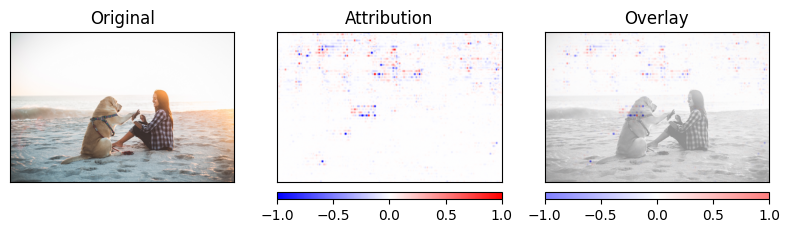

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
dog,dog (5562.00),5562,-0.33,What animal is in the picture ?


In [42]:
attr_hf = InputXGradient(model_wrapper)

attributions = get_attributions_plot(model_wrapper,
                                    attr_hf,
                                    inputs,
                                    image=img,
                                    true_text=true_text,
                                    target_token=target_token,
                                    pred_token=pred_token,
                                    pred_text=pred_text,
                                    use_baselines=False,
                                    plot=True,
                                    cmap=None
                                     )

#### Faithfulness metrics

In [160]:
import numpy as np
import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Sequence, Dict, Optional, Callable


@torch.no_grad()
def eval_image_perturbation_batch(
    model_wrapper,
    # inpts,
    pixel_values: Tensor,
    target_idx: Tensor,           # (B,) tensor of class indices
    pixel_attribution: Tensor,    # (B, H, W) or (B, 1, H, W) or (B, C, H, W)
    perturbation_steps: Sequence[float],
    forward_fn: Callable[[Tensor], Tensor],
    mask_value: float = 0.0,
    descending: bool = True,      # True: most important first; False: least important
    use_sigmoid: bool = False, # Use sigmoid to compute the probs - False use log_softmax
) -> Dict[str, np.ndarray]:
    """
    Batch-level image perturbation evaluation.

    Args
    ----
    model_wrapper: nn.Module
        Wrapper with:
            - .text_embeddings_layer(input_ids)
            - __call__(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids) -> logits
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, C, H, W),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices.
    pixel_attribution: Tensor
        (B, H, W) or (B, 1, H, W) or (B, C, H, W): saliency over image.
    perturbation_steps: list/tuple of float
        Fractions of pixels to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_value: float
        Value to put in perturbed pixels.
    descending: bool
        If True, remove most-attributed pixels first (deletion curve).
        If False, remove least-attributed pixels first (negative curve).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device
    pixel_values = pixel_values.to(device)
    pixel_attribution = pixel_attribution.to(device)
    target_idx = target_idx.to(device).long()

    # ---------- normalize shapes & define feature/position dims ----------
    ndim = pixel_values.ndim
    origin_shape = pixel_values.shape

    if ndim == 4: # (B, C, H, W)
        B, C, H, W = origin_shape
        num_pixels = H * W
        feat = pixel_values.view(B, C, num_pixels) # (B, C, H*W)
    elif ndim == 3: # (B, num_patches, patch_dim)
        B, num_pixels, patch_dim = origin_shape
        feat = pixel_values.transpose(1, 2) # (B, patch_dim, num_patches)
    else:
        raise ValueError("The pixel values do not have the good dim")

    if pixel_attribution.ndim == 3: # (B, H, W)
        sal_flat = pixel_attribution.view(B, -1) # (B, num_pixels)
    elif pixel_attribution.ndim == 2: # (B, num_patches)
        sal_flat = pixel_attribution
    else:
        raise ValueError("pixel_attribution must be (B, H, W) or (B,num_patches).")
    
    # print(f"feat size {feat.shape} - {pixel_values.shape}")
    # print(f"sal size{sal_flat.shape} - {pixel_attribution.shape}")

    # ---- baseline forward ----
    baseline_logits = forward_fn(pixel_values)        # (B, C)
    if use_sigmoid:
        baseline_probs = baseline_logits.sigmoid()           # (B, C)
    else:
        baseline_probs = baseline_logits.log_softmax(dim=-1)           # (B, C)

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)   # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B,2),(B,2)

    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )                                                   # (B,)
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx)  # (B,)

    baseline_dissimilarity = baseline_dissimilarity_t.float().cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)
    target_logit_pert = np.zeros((S, B), dtype=np.float32)
    target_prob_pert = np.zeros((S, B), dtype=np.float32)

    num_feats = feat.shape[1] # C or patch_dim

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        k = int(round(step * num_pixels))
        k = max(1, min(k, num_pixels))

        # top-k spatial indices per image
        _, flat_idx = torch.topk(
            sal_flat,
            k,
            dim=-1,
            largest=descending,
        )  # (B, k)


        # clone pixel values and mask selected pixels across channels
        feat_pert = feat.clone()
        # expand indices to channels
        flat_idx_expanded = flat_idx.unsqueeze(1).expand(B, num_feats, k) # (B, num_feats, k)
        # build src tensor filled with mask_value
        mask_src = torch.full_like(feat_pert[:, :, :k], mask_value)
        # scatter over flattened spatial dimension
        feat_pert.scatter_(
            dim=2,
            index=flat_idx_expanded,
            src=mask_src,
        ) # (B, num_feats, k)

        # Reshape back to original pixel_values
        if ndim == 4:
            B, C, H, W = origin_shape
            perturbed_pixels = feat_pert.view(B, C, H, W)       # (B, C, H, W)
        elif ndim == 3:
            perturbed_pixels = feat_pert.transpose(1, 2)        # (B, P, D)
        else:
            raise ValueError("Wrong dim for the pixel values !")

        # forward with perturbed pixels
        logits_pert = forward_fn(perturbed_pixels)  # (B, C)
        if use_sigmoid:
            probs_pert = logits_pert.sigmoid()                                             # (B, C)
        else:
            probs_pert = logits_pert.log_softmax(dim=-1)                                             # (B, C)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)      # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)             # (B, 2)

        # probability delta (top-1 prob)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]  # (B,)
        prob_diff[i] = prob_delta.float().cpu().numpy()

        # logit delta (top-1 logit)
        logit_delta = pert_max_logit - baseline_max_logit              # (B,)
        logit_diff[i] = logit_delta.float().cpu().numpy()

        # dissimilarity after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.float().cpu().numpy()
        target_prob_pert[i] = pert_target_prob.float().cpu().numpy()
        target_logit_pert[i] = pert_max_logit.float().cpu().numpy()

        # accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx)                     # (B,)
        correct_perturb[i] = pert_correct_t.float().cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "target_prob_pert": target_prob_pert,               # (S, B)
        "target_logit_pert": target_logit_pert,             # (S, B)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }

@torch.no_grad()
def eval_token_perturbation_batch(
    model_wrapper,
    # inpts,
    input_ids: Tensor,
    attention_mask: Tensor,
    target_idx: Tensor,          # (B,) tensor of class indices
    token_attribution: Tensor,   # (B, L) token-wise attribution scores
    perturbation_steps: Sequence[float],
    forward_fn: Callable[[Tensor, Tensor], Tensor],
    mask_token_id: int,
    pad_token_id: int,
    descending: bool = True,
    use_sigmoid: bool = False, # Use sigmoid to compute the probs - False use log_softmax,
    text_token_mask: Optional[Tensor] = None, # Bool of size (B, L) or None
) -> Dict[str, np.ndarray]:
    """
    Batch-level token perturbation evaluation for a VLM wrapper.

    Args
    ----
    model_wrapper: nn.Module
        Your wrapper with a forward like:
            model_wrapper(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids)
        and a `.text_embeddings_layer(input_ids)` method.
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, ...),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices for each sample.
    token_attribution: Tensor
        (B, L) attribution scores per token.
    perturbation_steps: list/tuple of float
        Fractions of tokens to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_token_id: int
        Token id that will replace perturbed tokens.
    pad_token_id: int
        Padding token id. If mask_token_id == pad_token_id,
        the attention mask is updated accordingly.
    descending: bool
        If True, mask most important tokens first (positive perturbation).
        If False, mask least important tokens first (negative perturbation).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device
    target_idx = target_idx.to(device)                  # (B,)
    token_attribution = token_attribution.to(device)

    B, L = input_ids.shape

    # ---- baseline forward ----
    baseline_logits = forward_fn(input_ids, attention_mask)       # (B, C)
    if use_sigmoid:
        baseline_probs = baseline_logits.sigmoid()          # (B, C)  # multi-label-ish
    else:
        baseline_probs = baseline_logits.log_softmax(dim=-1)

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)  # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B, 2), (B, 2)

    # per-sample dissimilarity: log(p_top1 / p_top2)
    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )  # (B,)

    # correctness: is top-1 predicted equal to target?
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx).float()  # (B,)

    # store as numpy
    baseline_dissimilarity = baseline_dissimilarity_t.float().cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.float().cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)
    target_logit_pert = np.zeros((S, B), dtype=np.float32)
    target_prob_pert = np.zeros((S, B), dtype=np.float32)

    # ---- text mask ----
    if text_token_mask is not None:
        text_token_mask = text_token_mask.to(device).bool()  # (B, L)
    else:
        # by default: all positions are perturbable
        text_token_mask = torch.ones(B, L, dtype=torch.bool, device=device)

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        # make a *per-sample* selection mask (B, L)
        select_mask = torch.zeros(B, L, dtype=torch.bool, device=device)

        for b in range(B):
            # attribution and mask for that sample
            attr_b = token_attribution[b].clone()         # (L,)
            mask_b = text_token_mask[b]                   # (L,)

            # only consider text tokens
            valid_idx = mask_b.nonzero(as_tuple=False).view(-1)   # (M,)
            if valid_idx.numel() == 0:
                continue  # nothing to perturb in this sample

            # how many text tokens to perturb for this step?
            M = valid_idx.numel()
            k_b = int(round(step * M))
            k_b = max(1, min(k_b, M))

            # restrict attribution to valid positions
            attr_valid = attr_b[valid_idx]               # (M,)
            topk_rel = torch.topk(attr_valid, k_b, largest=descending)
            topk_idx_valid = topk_rel.indices           # (k_b,)
            topk_idx = valid_idx[topk_idx_valid]        # (k_b,) indices in [0, L)

            select_mask[b, topk_idx] = True
    

        # create perturbed input ids: (B, L)
        perturbed_ids = input_ids.clone()
        perturbed_ids[select_mask] = mask_token_id

        # adjust attention_mask only if we truly pad
        perturbed_mask = attention_mask.clone()
        if mask_token_id == pad_token_id:
            # perturbed_mask[batch_idx, indices] = 0
            perturbed_mask[select_mask] = 0


        # ---- perturbed forward ----
        logits_pert = forward_fn(perturbed_ids, perturbed_mask)    # (B, C)
        if use_sigmoid:
            probs_pert = logits_pert.sigmoid()                # (B, C)
        else:
            probs_pert = logits_pert.log_softmax(dim=-1)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)     # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)            # (B, 2)

        # Probability delta (top-1 prob change)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]   # (B,)
        prob_diff[i] = prob_delta.float().cpu().numpy()

        # Logit delta (top-1 logit change)
        logit_delta = pert_max_logit - baseline_max_logit                # (B,)
        logit_diff[i] = logit_delta.float().cpu().numpy()

        # Confidence margin after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.float().cpu().numpy()
        target_logit_pert[i] = pert_max_logit.float().cpu().numpy()
        target_prob_pert[i] = pert_target_prob.float().cpu().numpy()
        

        # Accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx).float()                      # (B,)
        correct_perturb[i] = pert_correct_t.float().cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "target_prob_pert": target_prob_pert,               # (S, B)
        "target_logit_pert": target_logit_pert,             # (S, B)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }


In [21]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [22]:
pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = attributions[1].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [23]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

In [25]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.48192138671874996,
 'negative_auc': -0.41773681640625,
 'gap_auc': 0.0641845703125}

In [27]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = attributions[0].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [28]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

In [30]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -4.938403320312499,
 'negative_auc': -9.849566650390624,
 'gap_auc': -4.911163330078124}

#### Image visualization

In [ ]:
import torch.nn.functional as F
import numpy as np
import cv2
import torch
from PIL import Image
from captum.attr import visualization

def normalize_similarity_map(similarity_map: torch.Tensor,
                             value_range=None,
                             eps: float = 1e-8) -> torch.Tensor:
    """
    Min-max normalize a similarity / attribution map to [0, 1].

    similarity_map: torch.Tensor of arbitrary shape (e.g. [H, W])
    value_range: (min, max) or None. If None, use min/max from the tensor.
    """
    if value_range is None:
        vmin = similarity_map.min()
        vmax = similarity_map.max()
    else:
        vmin, vmax = value_range

    denom = (vmax - vmin).clamp(min=eps)
    return (similarity_map - vmin) / denom

def prepare_for_visualization(original_image, pixel_attr, image_grid_thw,
                              patch_size=14):
        grid_t, grid_h, grid_w = image_grid_thw.tolist()  # e.g. [1, H_patches, W_patches]

        pixel_attr = pixel_attr.view(grid_t, grid_h, grid_w, -1)[0]
        pixel_attr = pixel_attr.mean(axis=-1)
        pixel_attr = pixel_attr / pixel_attr.abs().max()

        # pixel_attr = (pixel_attr - pixel_attr.min()) / (pixel_attr.max() - pixel_attr.min() + 1e-8)

        # resized_height = grid_h * patch_size
        # resized_width  = grid_w * patch_size

        #  # resize original image to match the grid resolution
        # img_resized = original_image.resize((resized_width, resized_height), Image.BILINEAR)
        # img_resized_np = np.asarray(img_resized).astype(np.float32) / 255.0  # [H, W, 3]

         # --- 2. normalize to [0, 1] ---
        # heat_2d = normalize_similarity_map(pixel_attr, value_range=None)
        heat_2d_np = pixel_attr.to(torch.float32).cpu().numpy()       # [H_p, W_p]
        # print(pixel_attr)
        # --- 3. to uint8 and PIL image (grayscale) ---
        heat_2d_uint8 = (heat_2d_np * 255).astype("uint8")
        # print(heat_2d_uint8)
        # heat_pil = Image.fromarray(heat_2d_uint8, mode="L")

        # # --- 4. resize heatmap to original image size using PIL (your approach) ---
        # heat_pil_resized = heat_pil.resize(original_image.size, Image.Resampling.BICUBIC)

        # heat_up = np.asarray(heat_pil_resized).astype(np.float32) / 255.0  # [H, W]

        img_resized_np = np.asarray(original_image).astype(np.float32) / 255.0  # [H, W, 3]
        h, w, c = img_resized_np.shape
        heat_up = cv2.resize(heat_2d_uint8, (w, h))

        # --- 5. Use Captum's visualize_image_attr_multiple ---
        visualization.visualize_image_attr_multiple(
            np.expand_dims(heat_up, 2),
            img_resized_np,
            methods=["original_image", "heat_map", "blended_heat_map"],
            signs=["all", "all", "all"],
            show_colorbar=True,
            titles=["Original", "Attribution", "Overlay"],
        )


In [76]:
pixel_attr.shape

torch.Size([2520, 1176])

tensor([[ 0.0068,  0.0012,  0.0053,  ...,  0.0031,  0.0016,  0.0020],
        [ 0.0012,  0.0005, -0.0006,  ..., -0.0171,  0.0074, -0.0173],
        [-0.0045, -0.0003,  0.0044,  ...,  0.0006, -0.0001, -0.0003],
        ...,
        [-0.0029,  0.0080, -0.0017,  ..., -0.0628, -0.0355, -0.0187],
        [-0.0026,  0.0027,  0.0028,  ..., -0.0060,  0.0071,  0.0294],
        [ 0.0346, -0.0999, -0.0354,  ..., -0.0051, -0.0578,  0.0232]])
[[  1   0   1 ...   0   0   0]
 [  0   0   0 ... 252   1 252]
 [255   0   1 ...   0   0   0]
 ...
 [  0   2   0 ... 240 247 252]
 [  0   0   0 ... 255   1   7]
 [  8 231 247 ... 255 242   5]]


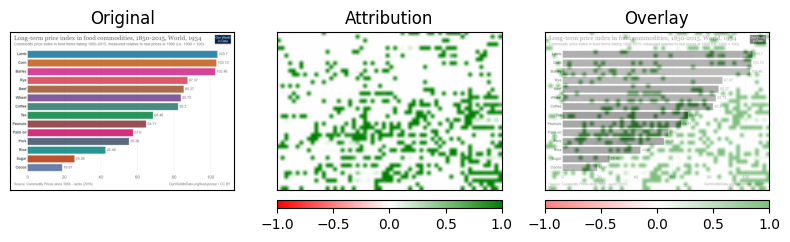

In [77]:
patch_size = processor.image_processor.patch_size
image = records[0]["image"]
pixel_attr = attributions[1].cpu().detach()
image_grid_thw = inputs.image_grid_thw
prepare_for_visualization(image, pixel_attr,
                          image_grid_thw[0],
                          patch_size=patch_size)

In [35]:
default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [36]:
import matplotlib.pyplot as plt


def show_side_by_side(original_image, pixel_values, pixel_attr, image_grid_thw,
                      patch_size=14, cmap="gray"):
    grid_t, grid_h, grid_w = image_grid_thw

    # build coarse map from pixel_values (same as gray version)
    pv_attr = pixel_attr.reshape(grid_t, grid_h, grid_w, -1)[0]
    heat_2d = pv_attr.mean(axis=-1)
    heat_2d = (heat_2d - heat_2d.min()) / (heat_2d.max() - heat_2d.min() + 1e-8)

    # build coarse map from pixel_values (same as gray version)
    pv = pixel_values.reshape(grid_t, grid_h, grid_w, -1)[0]
    pv = pv.mean(axis=-1)
    pv = (pv - pv.min()) / (pv.max() - pv.min() + 1e-8)

    # size of the resized image inside the processor
    resized_H = grid_h * patch_size
    resized_W = grid_w * patch_size

    # resize original image to match
    img_resized = original_image.resize((resized_W, resized_H))
    

    _, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_resized)
    axs[0].set_title("Original (resized)")
    axs[0].axis("off")

    axs[1].imshow(pv, cmap=cmap)
    axs[1].set_title("pixel_values (mean per patch)")
    axs[1].axis("off")

    axs[2].imshow(heat_2d, cmap=cmap)
    axs[2].set_title("pixel_values attributions (mean per patch)")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()


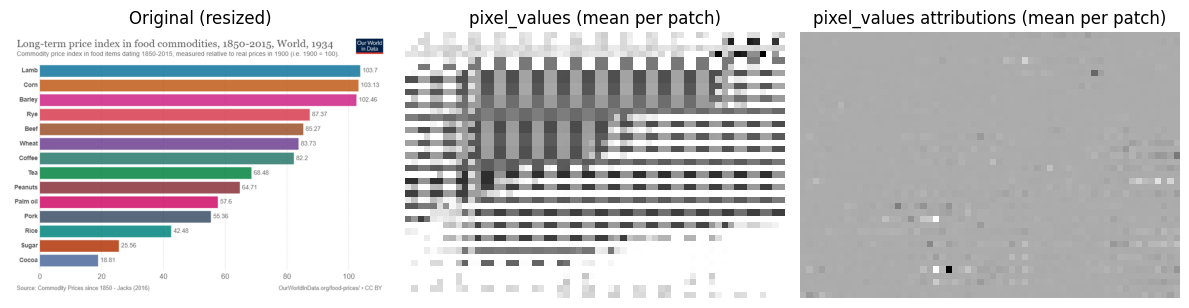

In [37]:
patch_size = processor.image_processor.patch_size
show_side_by_side(image, pixel_values.cpu().detach(), pixel_attr, image_grid_thw[0],
                      patch_size=patch_size,)

In [38]:
import matplotlib.pyplot as plt
from captum.attr import visualization


def show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw, cmap="gray"):
    grid_t, grid_h, grid_w = image_grid_thw

    # build coarse map from pixel_values (same as gray version)
    pv_attr = pixel_attr.reshape(grid_t, grid_h, grid_w, -1)[0]
    # heat_2d = pv_attr.mean(axis=-1)
    # heat_2d = (heat_2d - heat_2d.min()) / (heat_2d.max() - heat_2d.min() + 1e-8)

    # build coarse map from pixel_values (same as gray version)
    pv = pixel_values.reshape(grid_t, grid_h, grid_w, -1)[0]
    pv = pv.mean(axis=-1).unsqueeze(2)
    # pv = (pv - pv.min()) / (pv.max() - pv.min() + 1e-8)

    # size of the resized image inside the processor
    # resized_H = grid_h * patch_size
    # resized_W = grid_w * patch_size
    print(pv.shape, pv_attr.shape)


# --- 5. Use Captum's visualize_image_attr_multiple ---
    visualization.visualize_image_attr_multiple(
        pv_attr.cpu().detach().numpy(),
        pv.cpu().detach().numpy(),
        methods=["original_image", "heat_map", "blended_heat_map"],
        signs=["all", "all", "all"],
        show_colorbar=True,
        titles=["Original", "Attribution", "Overlay"],
    )


torch.Size([42, 60, 1]) torch.Size([42, 60, 1176])


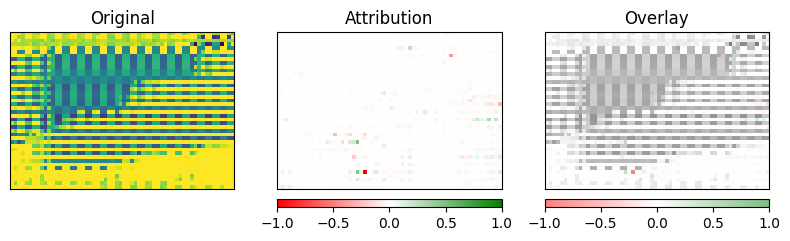

In [39]:
show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw[0], cmap="gray")

#### Token visualization

In [40]:
attributions[0].shape

torch.Size([1, 678, 2048])

In [41]:
img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()


In [42]:
attributions[0][token_mask].shape

torch.Size([48, 2048])

In [43]:
# text_attributions_norm = attributions[0].sum(dim=2).squeeze(0).norm()
# text_attr = attributions[0].sum(dim=2).squeeze(0) / text_attributions_norm

text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm

In [44]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'first_tokens': tensor([16])}

In [ ]:
target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]
pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [49]:
prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
prompt_text

'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|vision_end|>Answer concisely with a single number, word or short phrase.\nQuestion: How many food item is shown in the bar graph?<|im_end|>\n<|im_start|>assistant\n'

In [50]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            target_token.item(),
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
visualization.visualize_text(vis_data_records)

### LXT

In [ ]:
from typing import Dict, Any, List, Tuple

from PIL import Image
import torch
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules
from lxt.efficient import monkey_patch, monkey_patch_zennit


from src.explainers import BaseExplainer
from src.models import BaseVLMWrapper
from src.models.factory import create_model_wrapper

class LXTExplainer(BaseExplainer):
    def __init__(self,
                model_wrapper: BaseVLMWrapper):
        # super().__init__(model_wrapper)
        self.wrapper = model_wrapper
        self.zennit_comp = None

        # Check & Apply Patches (Idempotent)
        # This will update self.wrapper if a reload occurred
        self._ensure_patched(verbose=True,
                            use_zennit=False,
                            )

        # Update parent with the potentially new wrapper
        super().__init__(self.wrapper)


    def _ensure_patched(self,
                           verbose: bool = False,
                           use_zennit: bool = False,
                           ):
        
        # Get Patch Info from the wrapper (Delegated to wrapper logic)
        if not hasattr(self.wrapper, "get_patch_map"):
            print("[!] Wrapper does not support LXT patching auto-detection.")
            return
        
        
        module_root = self.wrapper.get_root_module()
        patch_dict = self.wrapper.get_patch_map()
        model_id = self.wrapper.model.config.name_or_path
        vlm_type = self.wrapper.model.config.model_type

        # --- IDEMPOTENCY CHECK ---
        # We check a flag on the module itself to see if we already touched it
        if getattr(module_root, "__lxt_is_patched__", False):
            # Already patched! Do not reload model.
            return 
        
        print(f"[*] Applying LXT Monkey Patches to {module_root}...")
        monkey_patch(module=module_root,
                     patch_map=patch_dict,
                     verbose=verbose)

        if use_zennit:
            monkey_patch_zennit(verbose=verbose)
        
        # Mark as patched
        setattr(module_root, "__lxt_is_patched__", True)
        
        try:
            # 3. Load Model (It will now instantiate using PATCHED classes)
            # We use your factory from before
            print(f"[*] Reloading patched model: {model_id}")
            del self.wrapper
            torch.cuda.empty_cache()

            self.wrapper = create_model_wrapper(model_id,
                                           vlm_type=vlm_type)
            
        finally:
            print("[!] Exiting Patch Context.")
            print("[!] WARNING: Python classes are still modified in memory.")
            print("[!] It is highly recommended to restart the kernel/process before running a different XAI method.")
            # Unlike hooks, monkey patching classes is very hard to undo robustly 
            # without reloading the 'transformers' library entirely.
        
        # Configure LXT (Zennit etc.)
        # Assuming you have a helper for this
        zennit_comp = self._configure_lxt(self.wrapper.model,
                                        use_zennit=use_zennit,
                                        )
        self.zennit_comp = zennit_comp
        
    def _configure_lxt(self,
                      model: torch.nn.Module,
                      use_zennit=False):

        zennit_comp = None

        if use_zennit:
            # Define rules for the Conv2d and Linear layers using 'zennit'
            conv_gamma = 100
            lin_gamma = 0.05
            # LayerMapComposite maps specific layer types to specific LRP rule implementations
            zennit_comp = LayerMapComposite([
                (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
                (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
            ])
            
            # monkey_patch_zennit(verbose=True)

        # Set up the model for the explanation task
        model.train()  # Switch to train mode to enable  gradient flow
        model.gradient_checkpointing_enable()  # Optional: saves memory

        # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
        for param in model.parameters():
            param.requires_grad = False

        if zennit_comp is not None:
            # Register the composite rules with the model
            zennit_comp.register(model)
        return zennit_comp

    def get_raw_attributions(self,
                             image,
                             question: str,
                             target_indices: List[int],
                             **kwargs
                             ) -> Tuple[torch.Tensor, torch.Tensor]:
        
        inputs = self.wrapper.get_inputs(image, question)
        input_ids = inputs["input_ids"]
        pixel_values = inputs["pixel_values"]
        kwargs_dict = {k: v for k, v in inputs.items() if k not in ['pixel_values']}

        text_embeds = self.wrapper.embed_text(input_ids).clone().detach()
        text_embeds.requires_grad_(True)
        pixel_values.requires_grad_(True)

        log_logits = self.wrapper.get_captum_forward(text_embeds=text_embeds,
                                                    pixel_values=pixel_values,
                                                    kwargs_dict=kwargs_dict,
                                  )
        max_logits, _ = torch.max(log_logits, dim=-1)
        max_logits.backward()
        #print(text_embeds)


        if self.zennit_comp is not None:
            # Remove the registered composite to prevent interference in future iterations
            self.zennit_comp.remove()

        # if full_relevance:
        relevance_img = (pixel_values.grad * pixel_values).float().detach().cpu()
        #relevance_img_norm = relevance_img / relevance_img.abs().max()

        relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()
        torch.cuda.empty_cache()

        return relevance_text, relevance_img
    


In [7]:
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLMLP
from transformers.models.qwen2.modeling_qwen2 import Qwen2RMSNorm

from lxt.efficient.patches import patch_method, patch_attention, patch_cp_attention
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, cp_gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from functools import partial
from torch.nn import Dropout, LayerNorm

# from lxt.efficient.models import get_default_map
from lxt.efficient.patches import patch_method, patch_attention, layer_norm_forward
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit


def configure_lxt(model, use_zennit=False):

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        # monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    model.train()  # Switch to train mode to enable  gradient flow
    model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp



In [8]:
use_zennit = False
attnLRP = {
        Qwen2_5_VLMLP: partial(patch_method, gated_mlp_forward),
        Qwen2RMSNorm: partial(patch_method, rms_norm_forward), 
        Dropout: partial(patch_method, dropout_forward),
        modeling_qwen2_5_vl: patch_attention,
    }

monkey_patch(modeling_qwen2_5_vl, patch_map=attnLRP, verbose=True)
if use_zennit:
    monkey_patch_zennit(verbose=True)

Patched Qwen2_5_VLMLP
Patched Qwen2RMSNorm
Patched Dropout
Patched transformers.models.qwen2_5_vl.modeling_qwen2_5_vl


In [9]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

NameError: name 'QwenVL_Wrapper' is not defined

In [ ]:
from src.models.qwen_vl import QwenVL_Wrapper

model_wrapper = QwenVL_Wrapper(model, processor)


In [12]:
lxt_xai = LXTExplainer(model_wrapper)

In [ ]:
# img = records[0]['image']
# question = records[0]['question']
# inputs = get_inputs(img, question)
# target_token = records[0]["target_token"]
# pred_token = records[0]["pred_token"]
# true_text = records[0]['gold_answers']
# pred_text = records[0]['prediction']

In [18]:
torch.cuda.empty_cache()


In [13]:
res = lxt_xai.get_raw_attributions(img, question=q, target_indices=0)

In [17]:
res[0].shape

torch.Size([1, 662])

#### Attribution

In [48]:
import torch.nn.functional as F
import numpy as np
import cv2
import torch
from PIL import Image
from captum.attr import visualization

from src.explainers.tam import id2idx
from viz_utils import prepare_for_visualization


def get_relevance(model_wrapper,
                  inputs,  
                  image,
                    true_text,
                    target_token=None,
                    pred_token=None,
                    pred_text=None,
                    zennit_comp=None,
                    plot=False,
                    cmap=None):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    # if gen_ids is not None:
    #     ctx_len = input_ids.size(1)
    #     gen_ids_new = gen_ids[:, ctx_len:]
    #     L_gen = gen_ids_new.size(1)
    #     input_ids = torch.cat([input_ids, gen_ids_new], dim=1)
    #     attention_mask = torch.ones_like(input_ids, device=model.device)

    # Text embeddings
    text_embeds = model_wrapper.text_embeddings_layer(input_ids).clone().detach()
    # if full_relevance:
    text_embeds.requires_grad_(True) # .to(model.device)
    pixel_values.requires_grad_(True)

    log_logits = model_wrapper(text_embeds, pixel_values,
                            attention_mask, input_ids, image_grid_thw,
                            return_probs=True)
    max_logits, _ = torch.max(log_logits, dim=-1)
    max_logits.backward()

    # if not full_relevance:
    #     inputs_embeds = inputs_embeds.detach().requires_grad_(True)

    # # inference and get the maximum logit at the last position (we can also explain other tokens)
    # outputs = model(
    #                 #input_ids=input_ids,
    #                 inputs_embeds=inputs_embeds,
    #                 attention_mask=attention_mask,
    #                 #image_grid_thw=image_grid_thw,
    #                 #pixel_values=pixel_values,
    #                 #position_ids=position_ids,
    #                 use_cache=False
    #                 )
    
    # output_logits = outputs["logits"]

    # if gen_ids is not None:
    #     L_gen = gen_ids_new.size(1)
        
    #     # positions whose logits predict each generated token
    #     indices = torch.arange(
    #         ctx_len - 1,
    #         ctx_len - 1 + L_gen,
    #         device=model.device
    #     )  # shape [L_gen]

    #     selected_logits = output_logits[0, indices, gen_ids_new[0]]   # [L_gen]
    #     selected_logits.backward(torch.ones_like(selected_logits))
    # else:
    #     max_logits, _ = torch.max(output_logits[0, -1, :], dim=-1)
    #     max_logits.backward()

    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    # if full_relevance:
    relevance_img = (pixel_values.grad * pixel_values).float().detach().cpu()
    #relevance_img_norm = relevance_img / relevance_img.abs().max()

    relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()
    #relevance_text_norm = relevance_text / relevance_text.abs().max()

    if plot:
        # Image visualization
        pixel_attr = relevance_img.clone()
        image_grid_thw = inputs.image_grid_thw
        prepare_for_visualization(image, pixel_attr,
                                    image_grid_thw[0],
                                    cmap=cmap)
        

        # Token visualization
        img_mask = (input_ids == model_wrapper.processor.image_token_id)
        token_mask = (input_ids != model_wrapper.processor.image_token_id)
        img_mask = img_mask.cpu()
        token_mask = token_mask.cpu()

        prompt_id = special_ids["prompt_id"]
        prompt_idx = [id2idx(input_ids[token_mask].tolist(), prompt_id[0], True),
                    id2idx(input_ids[token_mask].tolist(), prompt_id[1])]
        
        print(relevance_text.shape)
        raw_text_attr = relevance_text[token_mask][prompt_idx[0]+1 :prompt_idx[1]].detach().cpu()
        # text_attributions_norm = raw_text_attr.sum(dim=-1).norm()
        text_attr = raw_text_attr / raw_text_attr.abs().max()

        prompt_text = model_wrapper.processor.batch_decode(
                                    input_ids[token_mask][prompt_idx[0]+1 :prompt_idx[1]].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]

        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token,
                            pred_text,
                            true_text,
                            target_token,
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)
    
    return relevance_img, relevance_text


       

In [40]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)
target_token = records[0]["target_token"]
pred_token = records[0]["pred_token"]
true_text = records[0]['gold_answers']
pred_text = records[0]['prediction']

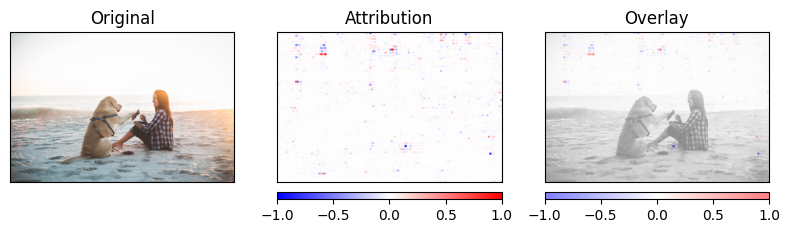

torch.Size([1, 3605])


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
dog,dog (5562.00),5562,2.12,What animal is in the picture ?


In [49]:
relevance_img, relevance_text = get_relevance(model_wrapper,
                                                inputs,
                                                image=img,
                                                true_text=true_text,
                                                target_token=target_token,
                                                pred_token=pred_token,
                                                pred_text=pred_text,
                                                plot=True,
                                                cmap=None
                                    )

In [52]:
# Token attribution
input_ids = inputs.input_ids

img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()

prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                            skip_special_tokens=False,
                            clean_up_tokenization_spaces=False)[0]

In [56]:
relevance_text[token_mask][5:23]

tensor([ 1.0863e-03, -6.2467e-03, -1.2574e-03,  1.3438e-03, -5.0137e-03,
         3.9785e-03, -1.1392e-03,  3.2119e-04,  4.1774e-03, -3.0998e-03,
         9.5781e-04, -8.6544e-04, -1.1016e-03, -1.0989e-03,  1.2531e-04,
         8.2651e-05, -3.2567e-04,  3.6205e-03])

In [74]:
# text_attributions_norm = relevance_text[token_mask].sum(dim=-1).norm()
text_attr = relevance_text[token_mask] / relevance_text[token_mask].abs().max()

In [77]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                    text_attr,
                    target_token.item(),
                    pred_class,
                    true_class,
                    true_class,
                    text_attr.sum(),       
                    prompt_text.split(),
                    0.0)]
visualization.visualize_text(vis_data_records)

In [78]:
torch.cuda.empty_cache()

In [83]:
from viz_utils import prepare_for_visualization, show_side_by_side, show_pixel_attribution_captum

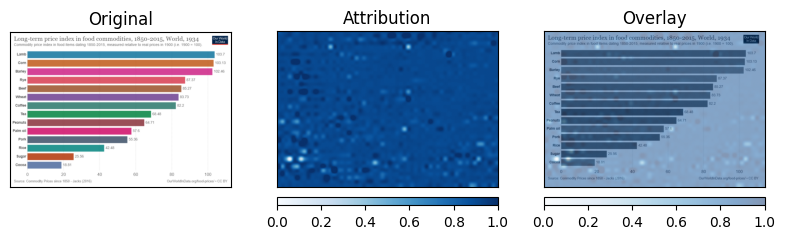

In [86]:
patch_size = processor.image_processor.patch_size
image = records[0]["image"]
pixel_attr = relevance_img.cpu().detach()
image_grid_thw = inputs.image_grid_thw
prepare_for_visualization(image, pixel_attr,
                          image_grid_thw[0],
                          patch_size=patch_size)

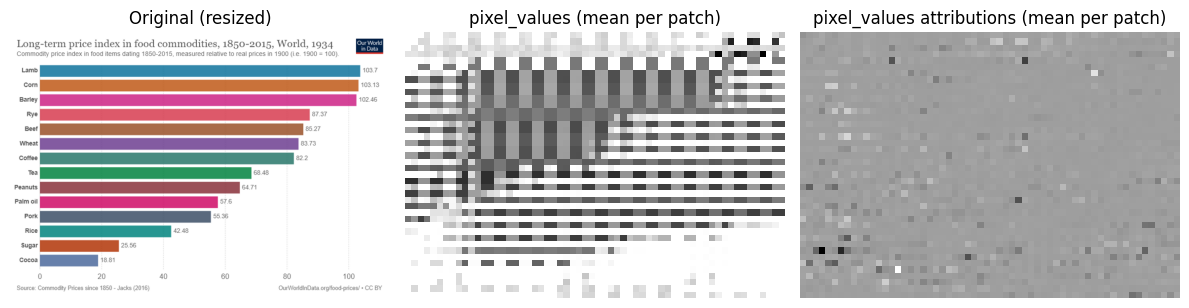

In [88]:
patch_size = processor.image_processor.patch_size
show_side_by_side(image, pixel_values.cpu().detach(), pixel_attr, image_grid_thw[0],
                      patch_size=patch_size,)

torch.Size([42, 60, 1]) torch.Size([42, 60, 1176])


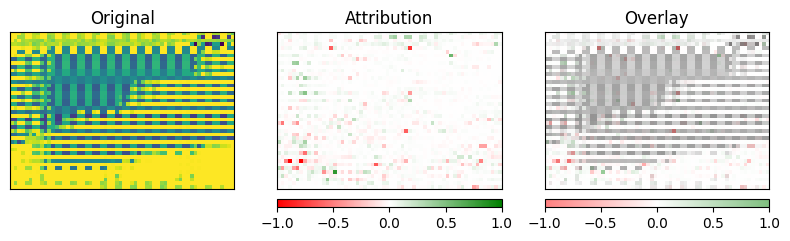

In [90]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)
show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw[0], cmap=default_cmap)

#### Faithfulness

In [93]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [94]:
pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = relevance_img.cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [95]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [97]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.63931884765625,
 'negative_auc': -0.25439453124999994,
 'gap_auc': 0.38492431640624997}

In [98]:
relevance_text.shape

torch.Size([1, 678])

In [99]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = relevance_text.cpu().detach()
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [100]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [102]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -7.162341308593749,
 'negative_auc': -8.68472900390625,
 'gap_auc': -1.5223876953125}

#### Draft code

In [79]:
from einops import rearrange

attributions_img = rearrange(relevance_img[0], 'c h w -> h w c')
attributions_img = attributions_img.detach().cpu().numpy()

pixel_values = inputs.pixel_values


original_im_mat = rearrange(pixel_values[0], 'c h w -> h w c')
original_im_mat = original_im_mat.detach().cpu().numpy()

EinopsError:  Error while processing rearrange-reduction pattern "c h w -> h w c".
 Input tensor shape: torch.Size([1176]). Additional info: {}.
 Wrong shape: expected 3 dims. Received 1-dim tensor.

In [ ]:
# image_grid_thw: (B, 3) tensor from the processor

image_grid_thw = inputs["image_grid_thw"]

img_idx = 0
grid_t, grid_h, grid_w = image_grid_thw[img_idx].tolist()  # e.g. [1, H_patches, W_patches]

# relevance: (N,) = (grid_t * grid_h * grid_w,)
relevance_patches = relevance_img.view(grid_t, grid_h, grid_w)

relevance_map = relevance_patches[0]      # (grid_h, grid_w)
patch_size = processor.image_processor.patch_size

resized_height = grid_h * patch_size
resized_width  = grid_w * patch_size

import torch.nn.functional as F

# (H_patches, W_patches) -> (1,1,H_patches,W_patches)
relevance_map_2d = relevance_map.unsqueeze(0).unsqueeze(0)

# Upsample to resized image size
heatmap_resized = F.interpolate(
    relevance_map_2d,
    size=(resized_height, resized_width),
    mode="bilinear",
    align_corners=False,
)  # shape: (1,1,resized_height,resized_width)

heatmap_resized = heatmap_resized.squeeze(0).squeeze(0)  # (resized_height, resized_width)



In [56]:
torch.cuda.empty_cache()

In [ ]:
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def reshape_visual_relevance(model, processor, image_size):

    patch_size = processor.image_processor.patch_size
    spatial_merge_size = model.config.vision_config.spatial_merge_size

    height_new, width_new = smart_resize(
        width=image_size[0],
        height=image_size[1],
        factor=patch_size * processor.image_processor.merge_size,
        min_pixels=processor.image_processor.size["shortest_edge"],
        max_pixels=processor.image_processor.size["longest_edge"],
    )


    n_patches_x = width_new // patch_size // spatial_merge_size
    n_patches_y = height_new // patch_size // spatial_merge_size
    return (n_patches_x, n_patches_y)


def visualize_image_relevance(image, img_relevance, figsize=(8,8), save_path=None):


    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    similarity_map_image = Image.fromarray((img_relevance.cpu().numpy() * 255).astype("uint8")).resize(
            image.size, Image.Resampling.BICUBIC
    )
    # similarity_map_image = Image.fromarray(img_relevance.cpu().numpy()).resize(
    #         image.size, Image.Resampling.BICUBIC
    # )
    
    show_colorbar = False
    # Create the figure
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            similarity_map_image,
            cmap=sns.color_palette("bwr", as_cmap=True),
            alpha=0.5,
        )

        if show_colorbar:
            fig.colorbar(im)
        ax.set_axis_off()
        fig.tight_layout()

        # ---- SAVE FIGURE ----
        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_image_relevance_(image, img_relevance, figsize=(8, 8), save_path=None):
    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    # img_relevance: torch.Tensor of shape (H_patches, W_patches), values in [-1, 1]
    rel = img_relevance.cpu().numpy().astype("float32")  # (Hp, Wp)
    similarity_map_image = Image.fromarray(rel, mode="F").resize(
        image.size, Image.Resampling.BICUBIC
    )
    print(similarity_map_image.size)

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            np.array(similarity_map_image),
            cmap="bwr",
            alpha=0.5,
            vmin=-1,
            vmax=1,
        )

        ax.set_axis_off()
        fig.tight_layout()

        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_text_relevance(text, token_relevance, figsize=(8,8), save_path=None):

    # "Importance": abs by default (signed scores → magnitude)
    idx_max = int(torch.argmax(token_relevance))

    # Keep it readable: show top-k (optional)
    k = min(30, len(text))
    top_idx = torch.topk(token_relevance, k).indices.tolist()[::-1]  # highest → lowest
    top_text = [text[i] for i in top_idx]
    top_imp    = token_relevance[top_idx].numpy()

    # Colors: grey for all, one highlighted
    colors = ['lightgray'] * k
    colors[top_idx.index(idx_max)] = 'tab:red'  # color only the most important

    plt.figure(figsize=figsize)
    y = np.arange(k)
    plt.barh(y, top_imp, color=colors)
    plt.yticks(y, top_text)
    plt.gca().invert_yaxis()
    plt.xlabel('Token importance (|relevance|)')
    plt.title('Top-k token attributions (max highlighted)')
    plt.tight_layout()
    # ---- SAVE FIGURE ----
    if save_path is None:
        save_path = "relevance_prompt_overlay.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")



In [58]:
relevance_text_norm = relevance_text / relevance_text.abs().max()
if full_relevance:
    relevance_img_norm = relevance_img / relevance_img.abs().max()
else:
    relevance_img_norm = None

In [42]:
inputs["input_ids"].shape

torch.Size([1, 3606])

In [43]:
relevance_text_norm.shape

torch.Size([3606])

In [64]:
from einops import rearrange

def prepare_relevance_for_visualization(input_ids, image, processor,
                                        image_grid_thw,
                                        relevance_text_norm,
                                        relevance_img_norm=None):
    img_mask = (input_ids == processor.image_token_id)
    token_mask = (input_ids != processor.image_token_id)
    img_mask = img_mask.cpu()
    token_mask = token_mask.cpu()

    idx = 0
    image_size = image.size
    n_patches = reshape_visual_relevance(model, processor, image_size)

    if relevance_img_norm is None:
        patch_relevance = rearrange(
                            relevance_text_norm[img_mask[idx]],  # (n_patches_x * n_patches_y, dim)
                            "(h w) -> w h",
                            w=n_patches[0],
                            h=n_patches[1],
                        )  # (n_patches_x, n_patches_y, dim)
        
    else:
        assert(relevance_text_norm[img_mask[idx]].sum().cpu().numpy() == 0)


        # image_grid_thw: (B, 3) tensor from the processor
        grid_t, grid_h, grid_w = image_grid_thw[idx].tolist()  # e.g. [1, H_patches, W_patches]

        # relevance: (N,) = (grid_t * grid_h * grid_w,)
        patch_relevance = relevance_img_norm.view(grid_t, grid_h, grid_w)

    ids = input_ids[idx][token_mask[idx]]
    token_relevance = relevance_text_norm[token_mask[idx]]

    prompt_text = processor.batch_decode(
        ids, skip_special_tokens=False, clean_up_tokenization_spaces=True
    )

    return token_relevance, patch_relevance, prompt_text


In [65]:
relevance_text_norm.shape

torch.Size([3606])

In [66]:
input_ids.shape

torch.Size([1, 3606])

In [67]:
input_ids = inputs["input_ids"]
image_grid_thw = inputs["image_grid_thw"]

use_target = False
if use_target:
    ctx_len = input_ids.size(1)
    gen_ids_new = gen_ids[:, ctx_len:]
    input_ids = torch.cat([input_ids, gen_ids_new], dim=1)

token_relevance, \
patch_relevance, \
prompt_text = prepare_relevance_for_visualization(input_ids,
                                                image,
                                                processor,
                                                image_grid_thw,
                                                relevance_text_norm,
                                                relevance_img_norm=relevance_img_norm)

In [75]:
full_relevance

True

In [76]:
patch_relevance.sum()

tensor(1.0861)

In [73]:
visualize_image_relevance(image, patch_relevance[0])


In [49]:
visualize_text_relevance(prompt_text, token_relevance)

In [17]:
image.size

(2048, 1365)

In [52]:
from IPython.display import display, HTML

# --- Assume you have your 'tokens' list and 'relevance' tensor ---

def colorize_tokens(tokens, scores):
    """Generates an HTML string with colored token backgrounds."""
    html_string = ""
    # Normalize scores for color mapping
    scores = torch.from_numpy(np.array(scores))
    scores = scores / scores.abs().max()

    for token, score in zip(tokens, scores):
        # Use blue for positive relevance, red for negative
        if score > 0:
            # Alpha (opacity) is proportional to the score
            color = f"rgba(0, 0, 255, {score:.2f})"
        else:
            # Use the absolute value for opacity
            color = f"rgba(255, 0, 0, {abs(score):.2f})"

        # Add a space after each token for readability
        html_string += f'<span style="background-color: {color};">{token}</span> '

    return html_string

# Generate the HTML
html_output = colorize_tokens(output_text, text_relevance_for_heatmap)

# Display it in the notebook
print("Token Relevance:")
display(HTML(html_output))

Token Relevance:


## Llava 1-5

In [1]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
from transformers import BitsAndBytesConfig

model_id = "llava-hf/llava-1.5-7b-hf"

def load_llava_model(model_id):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)
    
    model = LlavaForConditionalGeneration.from_pretrained(
        model_id, 
        dtype=torch.bfloat16, 
        low_cpu_mem_usage=True,
        quantization_config=bnb_config,
    ).to(0)

    processor = AutoProcessor.from_pretrained(model_id)
    return model, processor

In [2]:
model_id = "llava-hf/llava-1.5-7b-hf"
model, processor = load_llava_model(model_id)
model.eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affi

In [4]:
model.vision_tower

CLIPVisionModel(
  (vision_model): CLIPVisionTransformer(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (position_embedding): Embedding(577, 1024)
    )
    (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-23): 24 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear4bit(in_features=1024, out_

In [5]:
model.language_model

LlamaModel(
  (embed_tokens): Embedding(32064, 4096)
  (layers): ModuleList(
    (0-31): 32 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
        (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
        (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((4096,), eps=1e-05)
  (rotary_emb): LlamaRotaryEmbedding()
)

In [5]:
torch.cuda.empty_cache()

In [4]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

In [6]:
from PIL import Image


def get_inputs(image: Image.Image, question: str):
    conversation = [
        {

        "role": "user",
        "content": [
            {"type": "text", "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
            },
            {"type": "image"},
            ],
        },
    ]
    # Preparation for inference
    prompt = processor.apply_chat_template(
        conversation, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=prompt,
        images=image,
        # padding=True,
        return_tensors="pt",
    )

    inputs.to(model.device)
    return inputs

def predict_answer(image: Image.Image, question: str, dtype=torch.bfloat16) -> dict:
    

    #  # ---- Convert everything that can be bf16 into bf16 ----
    # if dtype is not None:
    #     for k in inputs:
    #         if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
    #             inputs[k] = inputs[k].to(dtype=dtype)

    inputs = get_inputs(image, question)


    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=32)

    # strip prompt
    prompt_len = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[:, prompt_len:]
    out = processor.batch_decode(
        answer_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    answer_text = out.strip()
    # answer_token_ids = answer_ids[0].tolist()
    # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
    return {
        "text": answer_text,
        "first_tokens": answer_ids[:, 0].cpu(),
        # "tokens": answer_tokens
    }



In [7]:
import gc
verbose = True
records = []  # this will hold all the info you want to reuse

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]
    golds = [a.lower().strip() for a in sample["label"]]

    pred_dict = predict_answer(img, q)
    pred_text =  pred_dict["text"]
    pred_lower = pred_text.lower()
    pred_first_tokens = pred_dict["first_tokens"]
    # pred_tokens = pred_dict["tokens"]

    correct = any(g in pred_lower for g in golds)

    if verbose:

        print(f"[{idx}] Q: {q}")
        print(f"    gold: {golds}")
        print(f"    pred: {pred_text}")
        print(f"    correct: {correct}\n")

    # Store everything you’ll need later
    records.append(
        {
            "id": idx,
            "image": img,              # keep the PIL image in memory
            "question": q,
            "gold_answers": golds,
            "prediction": pred_text,
            "correct": correct,
            "first_tokens": pred_first_tokens,
            # "tokens": pred_tokens,
        }    
    )
    gc.collect()
    torch.cuda.empty_cache()


[0] Q: How many food item is shown in the bar graph?
    gold: ['14']
    pred: 10
    correct: False

[1] Q: What is the difference in value between Lamb and Corn?
    gold: ['0.57']
    pred: 100
    correct: False

[2] Q: How many bars are shown in the chart?
    gold: ['3']
    pred: 2
    correct: False

[3] Q: Is the sum value of Madagascar more then Fiji?
    gold: ['no']
    pred: No
    correct: True

[4] Q: What's the value of the lowest bar?
    gold: ['23']
    pred: 23
    correct: True

[5] Q: What is the difference between the highest and the lowest green bar??
    gold: ['6']
    pred: 20
    correct: False

[6] Q: What percent who think of President Donald Trump as Dangerous?
    gold: ['62']
    pred: 52
    correct: False

[7] Q: Is the sum of the percents of Charismatic and Well-qualified to be president more than A strong leader ?
    gold: ['yes']
    pred: Yes
    correct: True

[8] Q: What was the 4th most popular emotion?
    gold: ['inspired']
    pred: Anger


In [9]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class Llava_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()

    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")

    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                return_probs=False
                ):
        

        # Vision embeddings
        image_features = self.hf_model.model.get_image_features(
                pixel_values=pixel_values,
                vision_feature_layer=None,
                vision_feature_select_strategy=None,
                image_sizes=None,
            )
        image_features = torch.cat(image_features, dim=0).to(text_embeds.device, text_embeds.dtype)
        special_image_mask = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_features
        )
        inputs_embeds = text_embeds.masked_scatter(special_image_mask, image_features)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        # Compute the log_softmax
        if return_probs:
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
        # del outputs
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32):
        with torch.no_grad():
            generated_ids = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           max_new_tokens=max_new_tokens)

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        return answer_ids[:, 0].cpu(), answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "Llava_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


### Captum

In [10]:
model_wrapper = Llava_Wrapper(model, processor)


In [11]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [12]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    TokenReferenceBase,
    visualization
)

import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import torch

In [13]:
from einops import rearrange

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

def get_attributions_plot(model_wrapper, attr_hf,
                          inputs, target_token,
                          true_class,
                          pred_token=None,
                          pred_class=None,
                          use_baselines=False,
                          plot=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids)

    baselines = None
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=model_wrapper.processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=model_wrapper.device).unsqueeze(0)
        reference_embeds = model_wrapper.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)

    # Make a forward and predictions
    if pred_token is None:
        pred_token, pred_class = model_wrapper.predict(input_embeds,
                                                    attention_mask,
                                                    input_ids)


    # Get attributions
    if use_baselines:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    if plot:
        # Token attribution
        img_mask = (input_ids == processor.image_token_id)
        token_mask = (input_ids != processor.image_token_id)
        img_mask = img_mask.cpu()
        token_mask = token_mask.cpu()

        prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
        
        text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
        text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm

        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            true_class,
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)


        # Pixel attributions
        original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
        attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

        visualization.visualize_image_attr_multiple(attributions_img,
                                                    original_im_mat, 
                                                    methods=["original_image", "heat_map", "blended_heat_map"],
                                                    signs=["all", "all", "all"],
                                                    titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                                    cmap=default_cmap,
                                                    show_colorbar=True)


    return attributions



In [14]:
attr_hf = InputXGradient(model_wrapper)
# attr_hf = IntegratedGradients(model_wrapper)


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],-0.44,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


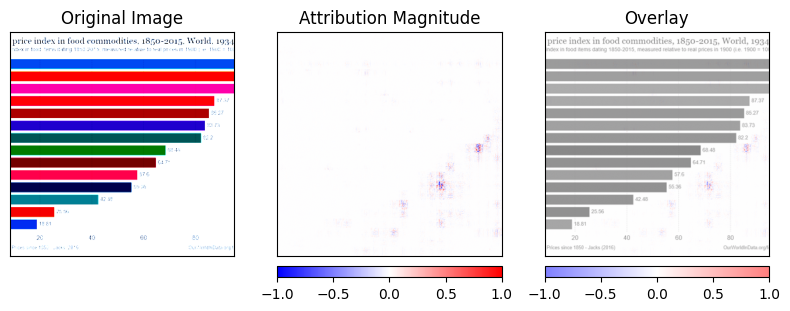

In [16]:
attributions = get_attributions_plot(model_wrapper,
                                     attr_hf=attr_hf,
                                     inputs=inputs,
                                     target_token=target_token,
                                     true_class=true_class,
                                     pred_token=target_token,
                                     pred_class=pred_class,
                                     use_baselines=False,
                                     plot=True
                                     )

In [17]:
torch.cuda.empty_cache()

#### Faithfulness

In [18]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [24]:
from einops import rearrange

pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = rearrange(attributions[1], 'b c h w -> b h w c' ).cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [26]:
pixel_attribution.shape

torch.Size([1, 336, 336])

In [27]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

In [28]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.033935546875,
 'negative_auc': -0.033062744140625,
 'gap_auc': 0.0008728027343749999}

In [29]:
attributions[0].shape

torch.Size([1, 616, 4096])

In [30]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = attributions[0].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [31]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

In [32]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -1.5392822265625004,
 'negative_auc': -4.85869140625,
 'gap_auc': -3.3194091796875}

#### Text attribution

In [ ]:
default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [39]:
attributions[0][token_mask].shape

torch.Size([40, 4096])

In [44]:
prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
prompt_text

'<s> USER:  \nAnswer concisely with a single number, word or short phrase.\nQuestion: How many food item is shown in the bar graph? ASSISTANT:'

In [47]:
# Visualize text attributions
text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm


# Visualize text attributions
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            target_token.item(),
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
visualization.visualize_text(vis_data_records)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),29871,-0.71,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),29871,-0.71,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


#### Image attribution

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


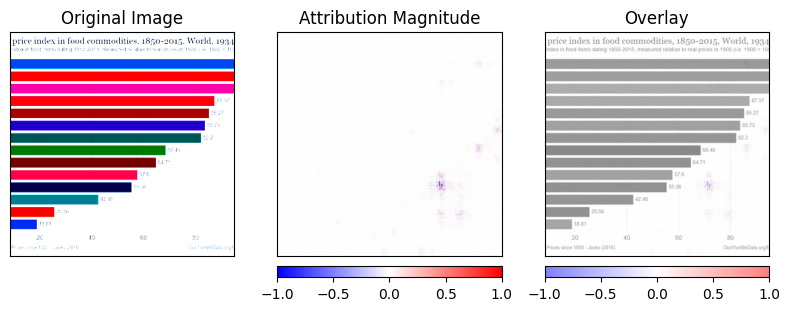

(<Figure size 800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Attribution Magnitude'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

In [56]:
# visualize image attributions
original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
                                            methods=["original_image", "heat_map", "blended_heat_map"],
                                            signs=["all", "all", "all"],
                                            titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                            cmap=default_cmap,
                                            show_colorbar=True)

In [57]:
attributions_img.shape

(336, 336, 3)

In [22]:
type(model.vision_tower)

transformers.models.clip.modeling_clip.CLIPVisionModel

In [23]:
type(model.language_model)

transformers.models.llama.modeling_llama.LlamaModel

In [26]:
type(model)

transformers.models.llava.modeling_llava.LlavaForConditionalGeneration

### LXT

In [33]:
from functools import partial
from torch.nn import Dropout, LayerNorm

# from lxt.efficient.models import get_default_map
from lxt.efficient.patches import patch_method, patch_attention, layer_norm_forward
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from transformers.models.llama import modeling_llama
from transformers.models.llama.modeling_llama import LlamaMLP, LlamaRMSNorm
from transformers.models.clip import modeling_clip
from transformers.models.llava import modeling_llava

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules



def configure_lxt(model, use_zennit=False):

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        # monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    model.train()  # Switch to train mode to enable  gradient flow
    model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp


In [34]:
use_zennit = False
attnLRP = {
    LlamaMLP: partial(patch_method, gated_mlp_forward),
    LlamaRMSNorm: partial(patch_method, rms_norm_forward),
    Dropout: partial(patch_method, dropout_forward),
    modeling_llama: patch_attention,
    modeling_clip: patch_attention,
    modeling_clip.nn.LayerNorm: partial(patch_method, layer_norm_forward),
}

monkey_patch(modeling_llava, patch_map=attnLRP, verbose=True)
if use_zennit:
    monkey_patch_zennit(verbose=True)

Patched LlamaMLP
Patched LlamaRMSNorm
Patched Dropout
Patched transformers.models.llama.modeling_llama
Patched transformers.models.clip.modeling_clip
Patched LayerNorm


In [35]:
model_id = "llava-hf/llava-1.5-7b-hf"
model, processor = load_llava_model(model_id)
model.eval()
model_wrapper = Llava_Wrapper(model, processor)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [36]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [37]:
zennit_comp = configure_lxt(model_wrapper.hf_model, use_zennit=False)

In [38]:
torch.cuda.empty_cache()


#### Attribution

In [39]:
def get_relevance(model_wrapper, inputs, zennit_comp=None,
                  full_relevance=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values

    # Text embeddings
    text_embeds = model_wrapper.text_embeddings_layer(input_ids).clone().detach()

    # if full_relevance:
    text_embeds.requires_grad_(True) # .to(model.device)
    pixel_values.requires_grad_(True)

    
    log_logits = model_wrapper(text_embeds, pixel_values,
                            attention_mask, input_ids)
    max_logits, _ = torch.max(log_logits, dim=-1)
    max_logits.backward()


    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    # if full_relevance:
    relevance_img = (pixel_values.grad * pixel_values).float().detach().cpu()
    #relevance_img_norm = relevance_img / relevance_img.abs().max()

    relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()
    #relevance_text_norm = relevance_text / relevance_text.abs().max()
    return relevance_img, relevance_text
    # else:
    #     relevance = (inputs_embeds.grad * inputs_embeds).float().sum(-1).detach().cpu()[0]
    #     return relevance, relevance

       

In [41]:
full_relevance = True
if full_relevance:
    relevance_img, \
        relevance_text = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    )
else:
    relevance_img = None
    relevance_text, _ = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    )

In [43]:
# Token attribution
input_ids = inputs.input_ids

img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()

prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                            skip_special_tokens=False,
                            clean_up_tokenization_spaces=False)[0]

In [46]:
# text_attributions_norm = relevance_text[token_mask].sum(dim=-1).norm()
text_attr = relevance_text[token_mask] / relevance_text[token_mask].abs().max()

In [47]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                    text_attr,
                    target_token.item(),
                    pred_class,
                    true_class,
                    true_class,
                    text_attr.sum(),       
                    prompt_text.split(),
                    0.0)]
visualization.visualize_text(vis_data_records)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],3.79,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],3.79,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


In [48]:
torch.cuda.empty_cache()

In [ ]:
from viz_utils import prepare_for_visualization, show_side_by_side, show_pixel_attribution_captum

In [50]:
from einops import rearrange

attributions_img = rearrange(relevance_img[0], 'c h w -> h w c')
attributions_img = attributions_img.detach().cpu().numpy()
pixel_values = inputs.pixel_values


original_im_mat = rearrange(pixel_values[0], 'c h w -> h w c')
original_im_mat = original_im_mat.detach().cpu().numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


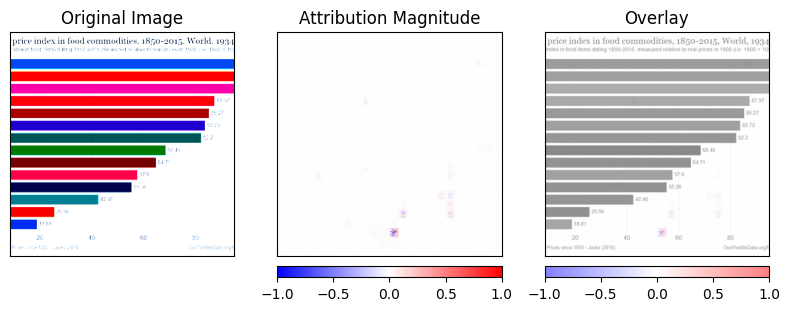

(<Figure size 800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Attribution Magnitude'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

In [51]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

visualization.visualize_image_attr_multiple(attributions_img,
                                            original_im_mat, 
                                            methods=["original_image", "heat_map", "blended_heat_map"],
                                            signs=["all", "all", "all"],
                                            titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                            cmap=default_cmap,
                                            #outlier_perc=0,
                                            show_colorbar=True)

#### Faithfulness

In [54]:
relevance_img.shape

torch.Size([1, 3, 336, 336])

In [52]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [55]:
from einops import rearrange

pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = rearrange(relevance_img, 'b c h w -> b h w c' ).cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [56]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [57]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.039239501953125006,
 'negative_auc': -0.035369873046875,
 'gap_auc': 0.0038696289062500003}

In [58]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = relevance_text.cpu().detach()
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [59]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [60]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -4.2718750000000005,
 'negative_auc': -0.978533935546875,
 'gap_auc': 3.293341064453125}